In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, matthews_corrcoef, accuracy_score, mean_absolute_error
import pickle
import mygene
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SkScaler
from lifelines.utils import concordance_index as lifelines_ci
import matplotlib.gridspec as gridspec
from captum.attr import IntegratedGradients
from scipy import stats
import os
import copy

## Data Preparation

In [2]:
# ── paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = "/g/data/yr31/rn8079/database/ucsc_xena/data"

RNA_PATH    = f"{DATA_DIR}/TCGA_rna.csv"
MIRNA_PATH  = f"{DATA_DIR}/TCGA_mirna.csv"
METHYL_PATH = f"{DATA_DIR}/TCGA_methylation.csv"
CLIN_PATH   = f"{DATA_DIR}/TCGA-BRCA.full_clinical.csv"

# ── M-value transform for methylation ────────────────────────────────────────
def beta_to_mvalue(X: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    X = np.clip(X, epsilon, 1 - epsilon)
    return np.log2(X / (1 - X))

# ── fold-safe z-score helpers ─────────────────────────────────────────────────
def compute_scaler(X: np.ndarray):
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std

def apply_scaler(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (X - mean) / std

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
class TCGABRCADataset(Dataset):
    """
    Extended multi-omics dataset with multi-task labels.
    
    Returns dict with:
        - mask: modality availability (bool, [3])
        - rna, mirna, methyl: omics tensors
    """
    
    # ── class-level storage (same pattern as your existing code) ──
    _pfi_time   = None
    _pfi_event  = None
     
    def __init__(
        self,
        indices,
        rna_scaler=None,
        mirna_scaler=None,
        methyl_scaler=None,
        dropout_probs=None,
    ):
        self.indices       = np.array(indices)
        self.rna_scaler    = rna_scaler
        self.mirna_scaler  = mirna_scaler
        self.methyl_scaler = methyl_scaler
        self.dropout_probs = dropout_probs  # None at val/test time

        # Access pre-loaded aligned arrays via class-level attributes
        # (populated by load_data() before instantiating any Dataset)
        self.rna_data    = TCGABRCADataset._rna_data
        self.mirna_data  = TCGABRCADataset._mirna_data
        self.methyl_data = TCGABRCADataset._methyl_data
        self.rna_mask    = TCGABRCADataset._rna_mask
        self.mirna_mask  = TCGABRCADataset._mirna_mask
        self.methyl_mask = TCGABRCADataset._methyl_mask
        self.sample_ids  = TCGABRCADataset._sample_ids

    def __len__(self):
        return len(self.indices)
    
    @classmethod
    def _prepare_survival_labels(cls, clinical_df, sample_ids):
        """Load PFI survival labels. OS dropped -- PFI is the primary endpoint."""
        clin = clinical_df.set_index('sampleID')
        n_samples = len(sample_ids)
        pfi_time  = torch.full((n_samples,), -1.0, dtype=torch.float32)
        pfi_event = torch.full((n_samples,), -1,   dtype=torch.long)

        for i, sid in enumerate(sample_ids):
            if sid not in clin.index:
                continue
            row = clin.loc[sid]
            pfi_t = row.get('PFI_time', None)
            pfi_e = row.get('PFI', None)
            if pd.notna(pfi_t) and pd.notna(pfi_e):
                pfi_time[i]  = float(pfi_t)
                pfi_event[i] = int(pfi_e)

        cls._pfi_time  = pfi_time
        cls._pfi_event = pfi_event

        valid  = (pfi_event >= 0).sum().item()
        events = (pfi_event == 1).sum().item()
        print(f"  PFI: {valid}/{n_samples} valid, {events} events")

       
    def __getitem__(self, idx):
        i = self.indices[idx]

        # ── modality availability (natural missingness) ───────────────────
        rna_obs    = bool(self.rna_mask[i])
        mirna_obs  = bool(self.mirna_mask[i])
        methyl_obs = bool(self.methyl_mask[i])

        # ── training-time modality dropout ───────────────────────────────
        # Never drop all modalities -- ensure at least one remains observed
        if self.dropout_probs is not None:
            max_attempts = 10
            for _ in range(max_attempts):
                rna_drop    = rna_obs    and (np.random.rand() < self.dropout_probs["rna"])
                mirna_drop  = mirna_obs  and (np.random.rand() < self.dropout_probs["mirna"])
                methyl_drop = methyl_obs and (np.random.rand() < self.dropout_probs["methyl"])
        
                if not (rna_drop and mirna_drop and methyl_drop):
                    break
            else:
                # Could not find a valid combination -- keep all naturally observed modalities
                rna_drop = mirna_drop = methyl_drop = False
        
            rna_obs    = rna_obs    and not rna_drop
            mirna_obs  = mirna_obs  and not mirna_drop
            methyl_obs = methyl_obs and not methyl_drop

        # ── build tensors for observed modalities ────────────────────────
        rna_tensor = methyl_tensor = mirna_tensor = None

        if rna_obs:
            x = self.rna_data[i].copy()
            if self.rna_scaler is not None:
                x = apply_scaler(x, *self.rna_scaler)
            rna_tensor = torch.tensor(x, dtype=torch.float32)

        if mirna_obs:
            x = self.mirna_data[i].copy()
            if self.mirna_scaler is not None:
                x = apply_scaler(x, *self.mirna_scaler)
            mirna_tensor = torch.tensor(x, dtype=torch.float32)

        if methyl_obs:
            x = self.methyl_data[i].copy()
            if self.methyl_scaler is not None:
                x = apply_scaler(x, *self.methyl_scaler)
            methyl_tensor = torch.tensor(x, dtype=torch.float32)

        # ── availability mask ─────────────────────────────────────────────
        mask = torch.tensor(
            [rna_obs, mirna_obs, methyl_obs],
            dtype=torch.bool
        )

        return {
            "rna":       rna_tensor,
            "mirna":     mirna_tensor,
            "methyl":    methyl_tensor,
            "mask":      mask,
            "sample_id": self.sample_ids[i],
            # multi-task labels
            "pfi_time":   TCGABRCADataset._pfi_time[i],
            "pfi_event":  TCGABRCADataset._pfi_event[i],
        }


# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    print("Loading clinical data ...")
    clin = pd.read_csv(CLIN_PATH, low_memory=False)
    clin = clin.drop_duplicates(subset="sampleID").set_index("sampleID")
    print(f"  Clinical samples: {len(clin)}")

    print("\nLoading mRNA ...")
    rna = pd.read_csv(RNA_PATH, index_col=0)
    print(f"  Shape: {rna.shape}")

    print("Loading miRNA ...")
    mirna = pd.read_csv(MIRNA_PATH, index_col=0)
    print(f"  Shape: {mirna.shape}")

    print("Loading methylation (large file, may take a moment) ...")
    methyl = pd.read_csv(METHYL_PATH, index_col=0)
    print(f"  Shape: {methyl.shape}")

    print("Loading mRNA ...")
    rna = pd.read_csv(RNA_PATH, index_col=0)
    print(f"  Shape: {rna.shape}")
    TCGABRCADataset._rna_feature_names = list(rna.columns)       # ← ADD
    
    print("Loading miRNA ...")
    mirna = pd.read_csv(MIRNA_PATH, index_col=0)
    print(f"  Shape: {mirna.shape}")
    TCGABRCADataset._mirna_feature_names = list(mirna.columns)   # ← ADD
    
    print("Loading methylation (large file, may take a moment) ...")
    methyl = pd.read_csv(METHYL_PATH, index_col=0)
    print(f"  Shape: {methyl.shape}")
    TCGABRCADataset._methyl_feature_names = list(methyl.columns) # ← ADD

    # M-value transform on methylation beta values
    print("\nApplying M-value transform to methylation ...")
    methyl_mvals = beta_to_mvalue(methyl.values.astype(np.float32))
    methyl = pd.DataFrame(methyl_mvals, index=methyl.index, columns=methyl.columns)

    all_clin    = set(clin.index)
    rna_sids    = set(rna.index)    & all_clin
    mirna_sids  = set(mirna.index)  & all_clin
    methyl_sids = set(methyl.index) & all_clin
    union_sids  = rna_sids | mirna_sids | methyl_sids

    print(f"\nClinical samples:               {len(all_clin)}")
    print(f"mRNA observed:                  {len(rna_sids)}")
    print(f"miRNA observed:                 {len(mirna_sids)}")
    print(f"Methylation observed:           {len(methyl_sids)}")
    print(f"Total usable (union):           {len(union_sids)}")

    # Master index: one row per usable sample, ordered consistently
    master_ids = sorted(union_sids)
    n          = len(master_ids)

    n_rna    = rna.shape[1]
    n_mirna  = mirna.shape[1]
    n_methyl = methyl.shape[1]

    # Allocate aligned arrays
    rna_arr    = np.full((n, n_rna),    np.nan, dtype=np.float32)
    mirna_arr  = np.full((n, n_mirna),  np.nan, dtype=np.float32)
    methyl_arr = np.full((n, n_methyl), np.nan, dtype=np.float32)
    rna_mask    = np.zeros(n, dtype=bool)
    mirna_mask  = np.zeros(n, dtype=bool)
    methyl_mask = np.zeros(n, dtype=bool)
    labels      = np.zeros(n, dtype=np.int64)

    print("\nFilling aligned arrays ...")
    for i, sid in enumerate(master_ids):
        if sid in rna_sids:
            rna_arr[i]    = rna.loc[sid].values
            rna_mask[i]   = True
        if sid in mirna_sids:
            mirna_arr[i]  = mirna.loc[sid].values
            mirna_mask[i] = True
        if sid in methyl_sids:
            methyl_arr[i]  = methyl.loc[sid].values
            methyl_mask[i] = True

    # Store as class-level attributes
    TCGABRCADataset._rna_data    = rna_arr
    TCGABRCADataset._mirna_data  = mirna_arr
    TCGABRCADataset._methyl_data = methyl_arr
    TCGABRCADataset._rna_mask    = rna_mask
    TCGABRCADataset._mirna_mask  = mirna_mask
    TCGABRCADataset._methyl_mask = methyl_mask
    TCGABRCADataset._sample_ids  = np.array(master_ids)

    # Missingness summary
    print("\nMissingness pattern:")
    print(f"  All three:            {(rna_mask & mirna_mask & methyl_mask).sum()}")
    print(f"  mRNA + miRNA only:    {(rna_mask & mirna_mask & ~methyl_mask).sum()}")
    print(f"  mRNA + methyl only:   {(rna_mask & ~mirna_mask & methyl_mask).sum()}")
    print(f"  mRNA only:            {(rna_mask & ~mirna_mask & ~methyl_mask).sum()}")
    print(f"\nFeature dimensions:")
    print(f"  mRNA:        {n_rna}")
    print(f"  miRNA:       {n_mirna}")
    print(f"  Methylation: {n_methyl}")

    return np.array(master_ids)


In [4]:
# ── run once ──────────────────────────────────────────────────────────────────
master = load_data()
clinical_df = pd.read_csv(CLIN_PATH, low_memory=False)
TCGABRCADataset._prepare_survival_labels(clinical_df, TCGABRCADataset._sample_ids)

Loading clinical data ...
  Clinical samples: 1097

Loading mRNA ...
  Shape: (1095, 4652)
Loading miRNA ...
  Shape: (1078, 524)
Loading methylation (large file, may take a moment) ...
  Shape: (784, 37482)
Loading mRNA ...
  Shape: (1095, 4652)
Loading miRNA ...
  Shape: (1078, 524)
Loading methylation (large file, may take a moment) ...
  Shape: (784, 37482)

Applying M-value transform to methylation ...

Clinical samples:               1097
mRNA observed:                  1094
miRNA observed:                 1077
Methylation observed:           783
Total usable (union):           1096

Filling aligned arrays ...

Missingness pattern:
  All three:            771
  mRNA + miRNA only:    304
  mRNA + methyl only:   10
  mRNA only:            9

Feature dimensions:
  mRNA:        4652
  miRNA:       524
  Methylation: 37482
  PFI: 1095/1096 valid, 145 events


## Model

In [5]:
# ── constants (from loaded data) ──────────────────────────────────────────────
N_RNA    = TCGABRCADataset._rna_data.shape[1]     # 4652
N_MIRNA  = TCGABRCADataset._mirna_data.shape[1]   # 524
N_METHYL = TCGABRCADataset._methyl_data.shape[1]  # 37482
N_LATENT = 48
# ── helper: build a feedforward block ────────────────────────────────────────
def fc_block(in_dim: int, out_dim: int, dropout: float = 0.2) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.LayerNorm(out_dim),
        nn.GELU(),
        nn.Dropout(dropout),
    )

In [6]:
class RNAEncoder(nn.Module):
    """mRNA encoder: 4652 -> 512 -> 256 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_RNA, latent_dim: int = N_LATENT):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(in_dim, 512, dropout=0.3),
            fc_block(512,    256, dropout=0.2),
            fc_block(256,     96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class MIRNAEncoder(nn.Module):
    """miRNA encoder: 524 -> 128 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_MIRNA, latent_dim: int = N_LATENT):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(in_dim, 128, dropout=0.2),
            fc_block(128,     96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class MethylEncoder(nn.Module):
    """Methylation encoder: 37482 -> 512 -> 256 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_METHYL, latent_dim: int = N_LATENT):
        super().__init__()
        self.input_layer = nn.Linear(in_dim, 512)
        self.input_norm  = nn.LayerNorm(512)
        self.input_act   = nn.GELU()
        self.input_drop  = nn.Dropout(0.4)
        self.net = nn.Sequential(
            fc_block(512, 256, dropout=0.2),
            fc_block(256,  96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.input_layer(x)
        h = self.input_drop(self.input_act(self.input_norm(h)))
        h = self.net(h)
        return self.fc_mu(h), self.fc_logvar(h)


# ─────────────────────────────────────────────────────────────────────────────
# Quick parameter count check
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

rna_enc    = RNAEncoder()
mirna_enc  = MIRNAEncoder()
methyl_enc = MethylEncoder()

print(f"RNAEncoder    parameters: {count_params(rna_enc):>12,}")
print(f"MIRNAEncoder  parameters: {count_params(mirna_enc):>12,}")
print(f"MethylEncoder parameters: {count_params(methyl_enc):>12,}")
print(f"Total encoder parameters: {count_params(rna_enc) + count_params(mirna_enc) + count_params(methyl_enc):>12,}")

RNAEncoder    parameters:    2,549,376
MIRNAEncoder  parameters:       89,344
MethylEncoder parameters:   19,358,336
Total encoder parameters:   21,997,056


In [7]:
# Confirm forward pass works for each encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

rna_enc    = rna_enc.to(device)
mirna_enc  = mirna_enc.to(device)
methyl_enc = methyl_enc.to(device)

# Dummy batch of 128 samples
dummy_rna    = torch.randn(128, N_RNA).to(device)
dummy_mirna  = torch.randn(128, N_MIRNA).to(device)
dummy_methyl = torch.randn(128, N_METHYL).to(device)

mu_rna,    lv_rna    = rna_enc(dummy_rna)
mu_mirna,  lv_mirna  = mirna_enc(dummy_mirna)
mu_methyl, lv_methyl = methyl_enc(dummy_methyl)

print(f"RNA    encoder output -- mu: {mu_rna.shape},    logvar: {lv_rna.shape}")
print(f"miRNA  encoder output -- mu: {mu_mirna.shape},  logvar: {lv_mirna.shape}")
print(f"Methyl encoder output -- mu: {mu_methyl.shape}, logvar: {lv_methyl.shape}")
print("All encoder forward passes OK")

Device: cuda
RNA    encoder output -- mu: torch.Size([128, 48]),    logvar: torch.Size([128, 48])
miRNA  encoder output -- mu: torch.Size([128, 48]),  logvar: torch.Size([128, 48])
Methyl encoder output -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
All encoder forward passes OK


In [8]:
class ProductOfExperts(nn.Module):
    """
    Extended PoE that incorporates translated pseudo-posteriors
    for missing modalities.
    
    Real posteriors contribute full precision.
    Translated posteriors contribute gated precision:
        precision_translated = gate * precision_pseudo
    where gate in (0, 1) is learned per translation direction.
    """
    
    def __init__(self, latent_dim, eps=1e-8):
        super().__init__()
        self.latent_dim = latent_dim
        self.eps = eps
    
    def forward(self, mu_list, logvar_list, 
                translated_mu_list=None, translated_logvar_list=None,
                translation_gates=None):
        """
        Args:
            mu_list: list of (mu, ) for OBSERVED modalities
            logvar_list: list of (logvar, ) for OBSERVED modalities
            translated_mu_list: list of (mu, ) for TRANSLATED pseudo-posteriors
            translated_logvar_list: list of (logvar, ) for TRANSLATED pseudo-posteriors
            translation_gates: list of scalar gates in (0,1) for each translated posterior
        """
        # Prior: N(0, I) -> precision = 1, mu*precision = 0
        batch_size = mu_list[0].size(0)
        mu_prior = torch.zeros(batch_size, self.latent_dim, device=mu_list[0].device)
        logvar_prior = torch.zeros(batch_size, self.latent_dim, device=mu_list[0].device)
        
        # Accumulate precision (1/sigma^2) and precision-weighted means
        precision = torch.exp(-logvar_prior)  # prior precision = 1
        precision_mu = mu_prior * precision   # prior: 0
        
        # Real observed posteriors (full precision)
        for mu, logvar in zip(mu_list, logvar_list):
            prec = torch.exp(-logvar)
            precision = precision + prec
            precision_mu = precision_mu + mu * prec
        
        # Translated pseudo-posteriors (gated precision)
        if translated_mu_list is not None:
            for mu_t, logvar_t, gate in zip(
                translated_mu_list, translated_logvar_list, translation_gates
            ):
                prec_t = torch.exp(-logvar_t)
                # gate is [batch, 1] or scalar, downweights translated precision
                gated_prec = gate * prec_t
                precision = precision + gated_prec
                precision_mu = precision_mu + mu_t * gated_prec
        
        mu_poe = precision_mu / (precision + self.eps)
        logvar_poe = -torch.log(precision + self.eps)
        
        return mu_poe, logvar_poe

def reparameterise(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    Reparameterisation trick: z = mu + eps * std, eps ~ N(0, I)
    Enables gradients to flow through the sampling operation.
    At inference time (model.eval()), returns mu directly.
    """
    if not torch.is_grad_enabled():
        return mu
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


# ─────────────────────────────────────────────────────────────────────────────
# Quick sanity check: verify PoE with different observed subsets
poe = ProductOfExperts(latent_dim=N_LATENT).to(device)

# Simulate a batch where all three modalities are observed
mu_poe_full, lv_poe_full = poe(
    [mu_rna, mu_mirna, mu_methyl],
    [lv_rna, lv_mirna, lv_methyl]
)
# Simulate mRNA + miRNA only (methylation absent -- just omit from lists)
mu_poe_2mod, lv_poe_2mod = poe(
    [mu_rna, mu_mirna],
    [lv_rna, lv_mirna]
)
# Simulate mRNA only
mu_poe_1mod, lv_poe_1mod = poe(
    [mu_rna],
    [lv_rna]
)
print(f"PoE full (3 modalities) -- mu: {mu_poe_full.shape}, logvar: {lv_poe_full.shape}")
print(f"PoE 2 modalities        -- mu: {mu_poe_2mod.shape}, logvar: {lv_poe_2mod.shape}")
print(f"PoE 1 modality          -- mu: {mu_poe_1mod.shape}, logvar: {lv_poe_1mod.shape}")

# Variance should decrease as more modalities are added
print(f"\nMean variance -- full: {lv_poe_full.exp().mean():.4f}, "
      f"2-mod: {lv_poe_2mod.exp().mean():.4f}, "
      f"1-mod: {lv_poe_1mod.exp().mean():.4f}")
print("Variance should decrease from 1-mod to full -- PoE OK if true")

# ─────────────────────────────────────────────────────────────────────────────
# Test PoE with translated pseudo-posteriors
print(f"\n── PoE with translations ──")

# Scenario: methyl missing, translate rna->methyl and mirna->methyl
dummy_trans_mu = [torch.randn(128, N_LATENT, device=device)]
dummy_trans_lv = [torch.randn(128, N_LATENT, device=device)]
dummy_gates = [torch.full((128, 1), 0.25, device=device)]  # conservative gate

mu_poe_trans, lv_poe_trans = poe(
    [mu_rna, mu_mirna],          # observed: rna + mirna
    [lv_rna, lv_mirna],
    translated_mu_list=dummy_trans_mu,
    translated_logvar_list=dummy_trans_lv,
    translation_gates=dummy_gates
)
print(f"PoE 2-mod + 1 translation -- mu: {mu_poe_trans.shape}, logvar: {lv_poe_trans.shape}")

var_no_trans = lv_poe_2mod.exp().mean().item()
var_with_trans = lv_poe_trans.exp().mean().item()
print(f"Variance without translation: {var_no_trans:.4f}")
print(f"Variance with translation:    {var_with_trans:.4f}")
print(f"Translation tightens posterior: {var_with_trans < var_no_trans} (should be True)")

# Gate at 0 should give identical result to no translation
dummy_gates_zero = [torch.zeros(128, 1, device=device)]
mu_poe_gate0, lv_poe_gate0 = poe(
    [mu_rna, mu_mirna],
    [lv_rna, lv_mirna],
    translated_mu_list=dummy_trans_mu,
    translated_logvar_list=dummy_trans_lv,
    translation_gates=dummy_gates_zero
)
mu_diff = (mu_poe_gate0 - mu_poe_2mod).abs().max().item()
lv_diff = (lv_poe_gate0 - lv_poe_2mod).abs().max().item()
print(f"\nGate=0 vs no translation -- mu diff: {mu_diff:.8f}, logvar diff: {lv_diff:.8f}")
print(f"Zero gate recovers original PoE: {mu_diff < 1e-5 and lv_diff < 1e-5} (should be True)")

PoE full (3 modalities) -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
PoE 2 modalities        -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
PoE 1 modality          -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])

Mean variance -- full: 0.2412, 2-mod: 0.3269, 1-mod: 0.4977
Variance should decrease from 1-mod to full -- PoE OK if true

── PoE with translations ──
PoE 2-mod + 1 translation -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
Variance without translation: 0.3269
Variance with translation:    0.2925
Translation tightens posterior: True (should be True)

Gate=0 vs no translation -- mu diff: 0.00000000, logvar diff: 0.00000000
Zero gate recovers original PoE: True (should be True)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
class RNADecoder(nn.Module):
    """
    mRNA decoder: 48 -> 96 -> 256 -> 512 -> 4652
    Mirror of RNAEncoder. No activation on output layer since
    log2(TPM+1) values are unbounded positive reals -- MSE reconstruction loss.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_RNA):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         256, dropout=0.2),
            fc_block(256,        512, dropout=0.2),
            nn.Linear(512, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
class MIRNADecoder(nn.Module):
    """
    miRNA decoder: 48 -> 96 -> 128 -> 524
    Mirror of MIRNAEncoder.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_MIRNA):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         128, dropout=0.2),
            nn.Linear(128, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
class MethylDecoder(nn.Module):
    """
    Methylation decoder: 48 -> 96 -> 256 -> 512 -> 37482
    Mirror of MethylEncoder. Output is M-values (unbounded) -- MSE loss.

    Note: the large output layer (512 -> 37482) is the decoder counterpart
    of the encoder bottleneck. It is only used for the ELBO reconstruction
    term and does not affect prediction quality directly.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_METHYL):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         256, dropout=0.2),
            fc_block(256,        512, dropout=0.2),
            nn.Linear(512, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
# Parameter counts
rna_dec    = RNADecoder().to(device)
mirna_dec  = MIRNADecoder().to(device)
methyl_dec = MethylDecoder().to(device)

print(f"RNADecoder    parameters: {count_params(rna_dec):>12,}")
print(f"MIRNADecoder  parameters: {count_params(mirna_dec):>12,}")
print(f"MethylDecoder parameters: {count_params(methyl_dec):>12,}")
print(f"Total decoder parameters: {count_params(rna_dec) + count_params(mirna_dec) + count_params(methyl_dec):>12,}")

# Forward pass check
z_sample = reparameterise(mu_poe_full, lv_poe_full)
print(f"\nLatent sample shape: {z_sample.shape}")

rna_recon    = rna_dec(z_sample)
mirna_recon  = mirna_dec(z_sample)
methyl_recon = methyl_dec(z_sample)

print(f"RNA    reconstruction: {rna_recon.shape}")
print(f"miRNA  reconstruction: {mirna_recon.shape}")
print(f"Methyl reconstruction: {methyl_recon.shape}")
print("All decoder forward passes OK")

RNADecoder    parameters:    2,549,324
MIRNADecoder  parameters:       85,164
MethylDecoder parameters:   19,391,114
Total decoder parameters:   22,025,602

Latent sample shape: torch.Size([128, 48])
RNA    reconstruction: torch.Size([128, 4652])
miRNA  reconstruction: torch.Size([128, 524])
Methyl reconstruction: torch.Size([128, 37482])
All decoder forward passes OK


In [10]:
class SurvivalHead(nn.Module):
    """
    Linear Cox PH head from latent space.
    
    Produces a scalar risk score per sample. Trained with the
    negative Cox partial log-likelihood.
    
    Deliberately linear (no hidden layers) to prevent the survival
    signal from dominating the latent space -- we want the latent
    to primarily capture classification-relevant structure with
    survival as a secondary regulariser.
    """
    
    def __init__(self, latent_dim):
        super().__init__()
        self.risk = nn.Linear(latent_dim, 1)
    
    def forward(self, z):
        """Returns risk score: [batch, 1]"""
        return self.risk(z)


        
def cox_partial_likelihood_loss(risk_scores, os_time, os_event):
    """
    Negative partial log-likelihood for Cox PH model.
    
    Args:
        risk_scores: [batch, 1] raw risk scores (higher = more risk)
        os_time:     [batch] survival/follow-up time
        os_event:    [batch] event indicator (1 = death, 0 = censored)
    
    Returns:
        scalar loss (mean over uncensored samples)
    
    Only computes over samples with valid survival data (os_event >= 0).
    Requires at least 2 valid samples with >= 1 event.
    """
    # Filter valid samples
    valid = os_event >= 0
    if valid.sum() < 2 or os_event[valid].sum() < 1:
        return torch.tensor(0.0, device=risk_scores.device, requires_grad=True)
    
    risk = risk_scores[valid].squeeze(-1)  # [n_valid]
    time = os_time[valid]                   # [n_valid]
    event = os_event[valid].float()         # [n_valid]
    
    # Sort by descending time (for risk set computation)
    sorted_idx = torch.argsort(time, descending=True)
    risk = risk[sorted_idx]
    event = event[sorted_idx]
    
    # Log-sum-exp trick for numerical stability
    # For each uncensored event i, the risk set R_i = {j : t_j >= t_i}
    # With descending sort, R_i = {0, 1, ..., i}
    # log P = sum_i [event_i * (risk_i - log(sum_{j in R_i} exp(risk_j)))]
    
    log_cumsum_exp = torch.logcumsumexp(risk, dim=0)  # [n_valid]
    
    partial_ll = event * (risk - log_cumsum_exp)
    
    n_events = event.sum()
    if n_events > 0:
        return -partial_ll.sum() / n_events
    else:
        return torch.tensor(0.0, device=risk_scores.device, requires_grad=True)

        

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Latent Cross-Modal Translation
# ─────────────────────────────────────────────────────────────────────────────

class LatentTranslationHead(nn.Module):
    """Translates source posterior into pseudo-posterior for target modality."""
    def __init__(self, latent_dim, hidden_dim=96):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, mu_src, logvar_src):
        h = torch.cat([mu_src, logvar_src], dim=-1)
        out = self.net(h)
        mu_pseudo = out[:, :self.latent_dim]
        logvar_pseudo = torch.clamp(out[:, self.latent_dim:], min=-6.0, max=2.0)
        return mu_pseudo, logvar_pseudo


class TranslationGateNetwork(nn.Module):
    """Per-sample confidence gate. Predicts trust from source posterior alone."""
    def __init__(self, latent_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias, -1.0)

    def forward(self, mu_src, logvar_src):
        h = torch.cat([mu_src, logvar_src], dim=-1)
        return torch.sigmoid(self.net(h))


class CrossModalTranslator(nn.Module):
    """
    Manages all 6 pairwise translation directions with a fixed precision gate.
    The gate alpha is a scalar applied uniformly to all pseudo-posterior
    contributions in the PoE fusion. Default alpha=0.75 (swept optimal).
    Gate networks are retained in __init__ for backwards compatibility with
    saved state_dicts but are not used in forward().
    """
    MODALITY_NAMES = ['rna', 'mirna', 'methyl']

    def __init__(self, latent_dim, hidden_dim=96, gate_hidden_dim=32, alpha=0.75):
        super().__init__()
        self.latent_dim   = latent_dim
        self.n_modalities = 3
        self.alpha        = alpha

        self.translation_heads = nn.ModuleDict()
        self.gate_networks     = nn.ModuleDict()   # kept for state_dict compatibility

        for src in range(self.n_modalities):
            for tgt in range(self.n_modalities):
                if src == tgt:
                    continue
                key = f"{src}_to_{tgt}"
                self.translation_heads[key] = LatentTranslationHead(latent_dim, hidden_dim)
                self.gate_networks[key]     = TranslationGateNetwork(latent_dim, gate_hidden_dim)

    def forward(self, mus, logvars, mask):
        translated_mus     = []
        translated_logvars = []
        gates              = []
        batch_size         = mus[0].shape[0]

        for src in range(self.n_modalities):
            for tgt in range(self.n_modalities):
                if src == tgt:
                    continue
                key = f"{src}_to_{tgt}"
                needs_translation = mask[:, src] & (~mask[:, tgt])
                if not needs_translation.any():
                    continue

                mu_pseudo_sub, logvar_pseudo_sub = self.translation_heads[key](
                    mus[src][needs_translation], logvars[src][needs_translation]
                )

                # Fixed gate: constant alpha across all samples and directions
                gate_sub = torch.full(
                    (needs_translation.sum(), 1),
                    fill_value=self.alpha,
                    device=mus[src].device,
                )

                mu_pseudo = torch.zeros(batch_size, self.latent_dim, device=mus[src].device)
                lv_pseudo = torch.zeros(batch_size, self.latent_dim, device=mus[src].device)
                gate_full = torch.zeros(batch_size, 1,               device=mus[src].device)

                mu_pseudo[needs_translation] = mu_pseudo_sub
                lv_pseudo[needs_translation] = logvar_pseudo_sub
                gate_full[needs_translation] = gate_sub

                translated_mus.append(mu_pseudo)
                translated_logvars.append(lv_pseudo)
                gates.append(gate_full)

        return translated_mus, translated_logvars, gates


def translation_consistency_loss(mus, logvars, translator, mask):
    """
    Wasserstein W2 distance between real and translated posteriors for
    fully-observed pairs. Replaces asymmetric KL with symmetric W2.

    Closed form for diagonal Gaussians:
        W2^2 = ||mu_pseudo - mu_real||^2 + ||sigma_pseudo - sigma_real||^2

    Advantages over KL:
        - Symmetric: penalises both directions of divergence equally
        - Does not blow up when distributions have non-overlapping support
          (important early in training before translation heads have converged)
        - Penalises mean and variance mismatch equally
        - More stable gradients when pseudo-posterior is far from real posterior
    """
    total_loss = 0.0
    n_pairs    = 0

    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
            both_observed = mask[:, src] & mask[:, tgt]
            if not both_observed.any():
                continue

            key = f"{src}_to_{tgt}"
            mu_pseudo, logvar_pseudo = translator.translation_heads[key](
                mus[src], logvars[src]
            )

            mu_real     = mus[tgt].detach()
            logvar_real = logvars[tgt].detach()

            # Convert logvar to std for W2 computation
            sigma_pseudo = torch.exp(0.5 * logvar_pseudo)
            sigma_real   = torch.exp(0.5 * logvar_real)

            # W2^2 = mean and variance terms
            mean_term = (mu_pseudo - mu_real).pow(2)
            var_term  = (sigma_pseudo - sigma_real).pow(2)

            w2 = (mean_term + var_term)[both_observed].mean()
            total_loss = total_loss + w2
            n_pairs += 1

    if n_pairs > 0:
        return total_loss / n_pairs
    return torch.tensor(0.0, device=mus[0].device, requires_grad=True)

def cycle_consistency_loss(mus, logvars, translator, mask):
    """
    Cycle consistency: A -> pseudo_B -> pseudo_A_reconstructed ≈ A
    For all 6 directions, using fully-observed pairs.
    Prevents translators from collapsing to mean-seeking solutions.
 
    For each src->tgt->src cycle:
        1. Translate src posterior to pseudo_tgt
        2. Translate pseudo_tgt back to pseudo_src_reconstructed
        3. Penalise MSE between original src mu and reconstructed src mu
 
    The double loop over (src, tgt) implicitly covers both cycle directions:
        src=0, tgt=1  ->  RNA   -> miRNA  -> RNA
        src=1, tgt=0  ->  miRNA -> RNA    -> miRNA
        src=0, tgt=2  ->  RNA   -> methyl -> RNA
        src=2, tgt=0  ->  methyl-> RNA    -> methyl
        src=1, tgt=2  ->  miRNA -> methyl -> miRNA
        src=2, tgt=1  ->  methyl-> miRNA  -> methyl
 
    Fix: removed .detach() on mu_pseudo_tgt / logvar_pseudo_tgt so that
    gradients flow end-to-end through both the forward head (key_fwd) and
    the backward head (key_bwd). Previously only key_bwd received cycle
    gradients; key_fwd relied solely on W2 consistency.
    """
    total_loss = 0.0
    n_cycles   = 0
 
    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
 
            both_observed = mask[:, src] & mask[:, tgt]
            if not both_observed.any():
                continue
 
            key_fwd = f"{src}_to_{tgt}"
            key_bwd = f"{tgt}_to_{src}"
 
            # Forward: src -> pseudo_tgt
            mu_pseudo_tgt, logvar_pseudo_tgt = translator.translation_heads[key_fwd](
                mus[src][both_observed], logvars[src][both_observed]
            )
 
            # Backward: pseudo_tgt -> pseudo_src_reconstructed
            # No .detach() — gradients flow back through key_fwd via key_bwd,
            # so both heads are trained jointly by the round-trip error.
            mu_recon_src, _ = translator.translation_heads[key_bwd](
                mu_pseudo_tgt, logvar_pseudo_tgt
            )
 
            # Cycle loss: reconstructed src mu should match original src mu
            # Detach the target — we are training the translators, not the encoder.
            mu_src_real = mus[src][both_observed].detach()
            cycle_loss  = F.mse_loss(mu_recon_src, mu_src_real)
 
            total_loss = total_loss + cycle_loss
            n_cycles  += 1
 
    if n_cycles > 0:
        return total_loss / n_cycles
 
    return torch.tensor(0.0, device=mus[0].device, requires_grad=True)



In [12]:
master_ids = TCGABRCADataset._sample_ids
n_total    = len(master_ids)
print(f"Total samples confirmed: {n_total}")

Total samples confirmed: 1096


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
def collate_fn(batch: list) -> dict:
    keys = ["rna", "mirna", "methyl"]
    mask   = torch.stack([b["mask"]  for b in batch])
    ids    = [b["sample_id"] for b in batch]
    result = {"mask": mask, "sample_id": ids}
    for k in keys:
        tensors = [b[k] for b in batch]
        if all(t is None for t in tensors):
            result[k] = None
        else:
            ref = next(t for t in tensors if t is not None)
            result[k] = torch.stack([
                t if t is not None else torch.zeros_like(ref) for t in tensors
            ])
    result['pfi_time']   = torch.stack([b['pfi_time']   for b in batch])
    result['pfi_event']  = torch.stack([b['pfi_event']  for b in batch])
    return result

    
# ─────────────────────────────────────────────────────────────────────────────
class BioPoE(nn.Module):
    """
    Dense PoE with per-sample gated latent translation.
    Primary task: PFI survival (Cox regression).
    Representation losses: recon, KL, consistency, translation, cycle, gate.
    No aux heads -- survival ranking loss does not decompose cleanly per modality.
    """
    def __init__(self, latent_dim=N_LATENT, branch_dim=None):
        super().__init__()
        self.latent_dim = latent_dim
        branch_dim = branch_dim or latent_dim

        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(latent_dim=latent_dim)

        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim)
        
    def forward(self, batch, translator=None, epoch=0, translation_warmup_epochs=10):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]

        mu_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_methyl = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_methyl = torch.zeros(batch_size, self.latent_dim, device=device)

        if rna_mask.any() and batch["rna"] is not None:
            mu_r, lv_r = self.rna_enc(batch["rna"][rna_mask])
            mu_rna[rna_mask] = mu_r
            lv_rna[rna_mask] = lv_r
        if mirna_mask.any() and batch["mirna"] is not None:
            mu_m, lv_m = self.mirna_enc(batch["mirna"][mirna_mask])
            mu_mirna[mirna_mask] = mu_m
            lv_mirna[mirna_mask] = lv_m
        if methyl_mask.any() and batch["methyl"] is not None:
            mu_me, lv_me = self.methyl_enc(batch["methyl"][methyl_mask])
            mu_methyl[methyl_mask] = mu_me
            lv_methyl[methyl_mask] = lv_me

        mus     = [mu_rna, mu_mirna, mu_methyl]
        logvars = [lv_rna, lv_mirna, lv_methyl]

        # PoE aggregation
        precision_sum = torch.ones(batch_size, self.latent_dim, device=device)
        weighted_mu   = torch.zeros(batch_size, self.latent_dim, device=device)

        modality_masks = [rna_mask, mirna_mask, methyl_mask]
        for m_idx in range(3):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            prec = torch.exp(-logvars[m_idx])
            precision_sum[obs] += prec[obs]
            weighted_mu[obs]   += (prec * mus[m_idx])[obs]

        # Latent translations for missing modalities
        use_translations = (translator is not None and epoch >= translation_warmup_epochs)
        
        if use_translations:
            trans_mus, trans_logvars, trans_gates = translator(mus, logvars, mask)
            for mu_t, lv_t, gate in zip(trans_mus, trans_logvars, trans_gates):
                prec_t = torch.exp(-lv_t)
                gated_prec = gate * prec_t
                precision_sum = precision_sum + gated_prec
                weighted_mu   = weighted_mu + mu_t * gated_prec

        # PoE posterior
        var_poe    = 1.0 / (precision_sum + 1e-8)
        logvar_poe = torch.log(var_poe + 1e-8)
        mu_poe     = var_poe * weighted_mu

        z = reparameterise(mu_poe, logvar_poe)

        # Reconstructions
        recons = {}
        decoders  = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        names     = ["rna", "mirna", "methyl"]
        feat_dims = [N_RNA, N_MIRNA, N_METHYL]
        for m_idx, (dec, name, feat_dim) in enumerate(zip(decoders, names, feat_dims)):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z[obs])
            recons[name] = recon_full

        # Sample from individual encoder posteriors for unimodal reconstruction
        z_rna    = reparameterise(mu_rna,    lv_rna)    if rna_mask.any()    else None
        z_mirna  = reparameterise(mu_mirna,  lv_mirna)  if mirna_mask.any()  else None
        z_methyl = reparameterise(mu_methyl, lv_methyl) if methyl_mask.any() else None

        return {
            "mu_poe":    mu_poe,
            "logvar_poe":logvar_poe,
            "z":         z,
            "z_surv":    z,
            "recons":    recons,
            "mus":       mus,
            "logvars":   logvars,
            "z_rna":     z_rna,
            "z_mirna":   z_mirna,
            "z_methyl":  z_methyl,
            "masks":     modality_masks,
        }


def kl_divergence_gaussian(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    KL divergence between N(mu, sigma^2) and N(0, I).
    KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    Averaged over batch and latent dimensions.
    """
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def kl_divergence_two_gaussians(
    mu1: torch.Tensor, logvar1: torch.Tensor,
    mu2: torch.Tensor, logvar2: torch.Tensor,
) -> torch.Tensor:
    """
    KL divergence between N(mu1, sigma1^2) and N(mu2, sigma2^2).
    KL = 0.5 * sum( logvar2 - logvar1 - 1
                    + exp(logvar1) / exp(logvar2)
                    + (mu1 - mu2)^2 / exp(logvar2) )
    Averaged over batch and latent dimensions.
    Used for cross-modal consistency regularisation.
    """
    return 0.5 * torch.mean(
        logvar2 - logvar1 - 1
        + logvar1.exp() / logvar2.exp()
        + (mu1 - mu2).pow(2) / logvar2.exp()
    )


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Loss computation
# ─────────────────────────────────────────────────────────────────────────────
VALID_TASK_MODES = {"survival"}

def compute_loss(
    outputs, batch, beta,
    lambda_recon, lambda_consist,
    lambda_translation, lambda_cycle,
    lambda_survival,
    survival_head, translator,
    epoch, translation_warmup_epochs,
    model=None,
    lambda_unimodal=0.0,
    lambda_surv_trans=0.0,
):
    """Loss: survival + recon + kl + consist + translation + cycle

    Survival (PFI Cox) is the only task loss.
    Representation losses (recon, KL, consist, translation, cycle)
    are always active with fixed manual lambdas.
    """
    device = batch["mask"].device
    mask   = batch["mask"]


    # ── Reconstruction ────────────────────────────────────────────────────────
    # Per-modality reconstruction weights inversely proportional to feature count.
    # Prevents methylation (37482 features) from dominating reconstruction gradients
    # relative to RNA (4652) and miRNA (524).
    # Weights normalised so RNA = 1.0 as the reference modality.
    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,   # 4652/524  = 8.88
        "methyl": N_RNA / N_METHYL,  # 4652/37482 = 0.124
    }
    
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"], "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # ── Unimodal reconstruction ───────────────────────────────────────────────
    # Decodes from each modality's individual encoder z_i rather than joint z.
    # Forces individual encoder latent spaces to be independently meaningful,
    # giving translation heads a structured target to map toward.
    loss_unimodal = torch.tensor(0.0, device=device, requires_grad=True)
    n_unimodal = 0

    z_individual = {
        "rna":    outputs.get("z_rna"),
        "mirna":  outputs.get("z_mirna"),
        "methyl": outputs.get("z_methyl"),
    }
    decoders_map = {
        "rna":    model.rna_dec,
        "mirna":  model.mirna_dec,
        "methyl": model.methyl_dec,
    }

    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        z_i = z_individual[m_name]
        if z_i is None:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        recon_i = decoders_map[m_name](z_i)
        loss_unimodal = loss_unimodal + RECON_WEIGHTS[m_name] * F.mse_loss(
            recon_i[obs], recon_targets[m_name][obs]
        )
        n_unimodal += 1

    if n_unimodal > 0:
        loss_unimodal = loss_unimodal / n_unimodal
        
    # ── KL divergence ─────────────────────────────────────────────────────────
    mu_poe     = outputs["mu_poe"]
    logvar_poe = outputs["logvar_poe"]
    loss_kl = -0.5 * torch.mean(1 + logvar_poe - mu_poe.pow(2) - logvar_poe.exp())

    # ── Consistency ───────────────────────────────────────────────────────────
    loss_consist = torch.tensor(0.0, device=device, requires_grad=True)
    mus     = outputs["mus"]
    logvars = outputs["logvars"]
    mu_poe_d = mu_poe.detach()
    lv_poe_d = logvar_poe.detach()
    n_consist = 0
    for m_idx in range(3):
        obs = mask[:, m_idx]
        if obs.sum() < 2:
            continue
        kl = 0.5 * (
            lv_poe_d[obs] - logvars[m_idx][obs]
            + (logvars[m_idx][obs].exp() + (mus[m_idx][obs] - mu_poe_d[obs]).pow(2))
            / (lv_poe_d[obs].exp() + 1e-8) - 1.0
        )
        loss_consist = loss_consist + kl.mean()
        n_consist += 1
    if n_consist > 0:
        loss_consist = loss_consist / n_consist

    # ── Survival (PFI Cox) ────────────────────────────────────────────────────
    z_surv        = outputs["z_surv"]
    risk_scores   = survival_head(z_surv)
    loss_survival = cox_partial_likelihood_loss(risk_scores, batch["pfi_time"], batch["pfi_event"])
    
    # ── Translation consistency ───────────────────────────────────────────────
    use_trans = (
        translator is not None
        and hasattr(translator, "translation_heads")
        and epoch >= translation_warmup_epochs
    )
    if use_trans:
        loss_translation = translation_consistency_loss(mus, logvars, translator, mask)
        loss_cycle       = cycle_consistency_loss(mus, logvars, translator, mask)

        # ── Survival-preserving translation loss ──────────────────────────────
        # Trains translation heads to preserve Cox risk scores across modalities.
        # For fully-observed pairs, the translated pseudo-posterior should produce
        # a similar risk score to the real target encoder output.
        # This gives translations survival geometry, not just reconstruction geometry.
        loss_surv_trans = torch.tensor(0.0, device=device)
        n_surv_trans = 0
        for src in range(3):
            for tgt in range(3):
                if src == tgt:
                    continue
                both_observed = mask[:, src] & mask[:, tgt]
                if both_observed.sum() < 2:
                    continue
                key = f"{src}_to_{tgt}"
                mu_pseudo, logvar_pseudo = translator.translation_heads[key](
                    mus[src][both_observed], logvars[src][both_observed]
                )
                z_pseudo   = reparameterise(mu_pseudo, logvar_pseudo)
                z_real     = reparameterise(
                    mus[tgt][both_observed].detach(),
                    logvars[tgt][both_observed].detach()
                )
                # Detach survival head parameters from this loss —
                # survival head is used as a fixed scorer only.
                # Only translation heads receive gradients here.
                with torch.no_grad():
                    risk_real = survival_head(z_real)
                # z_pseudo still has grad, but survival head params are frozen
                # by passing through a detached copy of its computation
                risk_pseudo = F.linear(
                    z_pseudo,
                    survival_head.risk.weight.detach(),
                    survival_head.risk.bias.detach()
                )
                loss_surv_trans = loss_surv_trans + F.mse_loss(risk_pseudo, risk_real)
                n_surv_trans += 1
        if n_surv_trans > 0:
            loss_surv_trans = loss_surv_trans / n_surv_trans
    else:
        loss_translation = torch.tensor(0.0, device=device)
        loss_cycle       = torch.tensor(0.0, device=device)
        loss_surv_trans  = torch.tensor(0.0, device=device)

   # ── Total ─────────────────────────────────────────────────────────────────
    total = (
          lambda_survival    * loss_survival
        + lambda_recon       * loss_recon
        + beta               * loss_kl
        + lambda_consist     * loss_consist
        + lambda_translation * loss_translation
        + lambda_cycle       * loss_cycle
        + lambda_unimodal    * loss_unimodal
        + lambda_surv_trans  * loss_surv_trans
    )

    loss_dict = {
        "total":       total.item(),
        "survival":    loss_survival.item(),
        "recon":       loss_recon.item(),
        "kl":          loss_kl.item(),
        "consist":     loss_consist.item(),
        "translation": loss_translation.item(),
        "cycle":       loss_cycle.item(),
        "unimodal":    loss_unimodal.item(),
        "surv_trans":  loss_surv_trans.item(),
    }
    return total, loss_dict

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # add this line
    torch.use_deterministic_algorithms(True, warn_only=True)  # add this line


def get_beta(epoch, kl_warmup_epochs, beta_max=1.0): 
    if epoch >= kl_warmup_epochs:
        return beta_max
    return beta_max * (epoch / kl_warmup_epochs)


def get_dropout_p(epoch, cfg):
    """
    Curriculum dropout probability for the current epoch.
    Returns 0.0 if dropout is disabled or epoch is before dropout_start_epoch.
    Linearly ramps from 0 -> dropout_p_max over dropout_ramp_epochs,
    then holds at dropout_p_max.
    """
    if not cfg.get("use_modality_dropout", False):
        return 0.0
    start  = cfg["dropout_start_epoch"]
    ramp   = cfg["dropout_ramp_epochs"]
    p_max  = cfg["dropout_p_max"]
    if epoch < start:
        return 0.0
    progress = min(1.0, (epoch - start) / ramp)
    return progress * p_max


def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    return {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in batch.items()
    }

## Config

In [54]:
warnings.filterwarnings("ignore")

CONFIG = {
    # Training
    "n_folds":        5,
    "n_epochs":       100,
    "batch_size":     128,
    "learning_rate":  1e-3,
    "weight_decay":   1e-4,
    "translation_warmup_epochs": 10,
    "alpha": 0.75,
    # KL annealing
    "kl_warmup_epochs": 30,
    # Loss weights
    "lambda_recon":        0.1,
    "lambda_consist":      0.1,   
    "lambda_survival":     0.1,   
    "lambda_translation":  0.2,
    "lambda_cycle": 0.1,   # cycle consistency weight — start conservative
    # Early stopping
    "patience": 15,
    # Reproducibility
    "seed": 0,
    # Translation
    "translation_hidden_dim": 96,
    "translation_warmup_epochs": 10,

    "lambda_unimodal": 0.0,
    "lambda_surv_trans": 0.05,
    # Modality dropout curriculum (ablation variant — set False for canonical)
    "use_modality_dropout":    False,
    "dropout_p_max":           0.15,
    "dropout_start_epoch":     30,
    "dropout_ramp_epochs":     30,
    "min_epochs":              30, # Set to 50 if modality dropout true
}

## Training

In [55]:
def concordance_index(times, risk_scores, events):
    try:
        # lifelines expects higher risk score = worse outcome
        # our Cox head produces higher score = higher risk, so sign is correct
        return lifelines_ci(times, -risk_scores, events)
    except Exception:
        return 0.5


@torch.no_grad()
def evaluate(model, translator, survival_head, loader, device, cfg):
    model.eval()
    if translator is not None:
        translator.eval()
    survival_head.eval()
    all_risk, all_pfi_time, all_pfi_event = [], [], []
    total_loss_sum = 0.0
    n_batches = 0

    for batch in loader:
        batch   = move_batch_to_device(batch, device)
        outputs = model(
            batch, translator=translator,
            epoch=cfg["n_epochs"],
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
        )
        loss, _ = compute_loss(
            outputs=outputs, batch=batch,
            beta=1.0,
            lambda_recon=cfg["lambda_recon"],
            lambda_consist=cfg["lambda_consist"],
            lambda_survival=cfg["lambda_survival"],
            lambda_translation=cfg["lambda_translation"],
            lambda_cycle=cfg["lambda_cycle"],
            survival_head=survival_head,
            translator=translator,
            epoch=cfg["n_epochs"],
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
            model=model,                                    # ← NEW
            lambda_unimodal=cfg["lambda_unimodal"],        # ← NEW
            lambda_surv_trans=cfg.get("lambda_surv_trans", 0.0),
        )
        total_loss_sum += loss.item()

        risk       = survival_head(outputs["z_surv"])
        valid_surv = batch["pfi_event"] >= 0
        if valid_surv.any():
            all_risk.append(risk[valid_surv].cpu())
            all_pfi_time.append(batch["pfi_time"][valid_surv].cpu())
            all_pfi_event.append(batch["pfi_event"][valid_surv].cpu())
        n_batches += 1

    c_index = float("nan")
    if len(all_risk) > 0:
        risk_np  = torch.cat(all_risk).squeeze().numpy()
        time_np  = torch.cat(all_pfi_time).numpy()
        event_np = torch.cat(all_pfi_event).numpy()
        if event_np.sum() > 0:
            c_index = concordance_index(time_np, risk_np, event_np)

    return {
        "loss":    total_loss_sum / max(n_batches, 1),
        "c_index": c_index,
    }


def train_one_epoch(model, translator, survival_head,
                    loader, optimizer, device, epoch, cfg):
    model.train()
    translator.train()
    survival_head.train()
    loss_keys = ["total", "survival", "recon", "kl", "consist",
                 "translation", "cycle", "unimodal", "surv_trans"]
    loss_accum = {k: 0.0 for k in loss_keys}
    n_batches = 0
    beta = get_beta(epoch, cfg["kl_warmup_epochs"])

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad()
        outputs = model(
            batch, translator=translator,
            epoch=epoch,
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
        )
        loss, loss_dict = compute_loss(
            outputs=outputs, batch=batch,
            beta=beta,
            lambda_recon=cfg["lambda_recon"],
            lambda_consist=cfg["lambda_consist"],
            lambda_survival=cfg["lambda_survival"],
            lambda_translation=cfg["lambda_translation"],
            lambda_cycle=cfg["lambda_cycle"],
            survival_head=survival_head,
            translator=translator,
            epoch=epoch,
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
            model=model,                                    # ← NEW
            lambda_unimodal=cfg["lambda_unimodal"],        # ← NEW
            lambda_surv_trans=cfg.get("lambda_surv_trans", 0.0),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters())
            + list(translator.parameters())
            + list(survival_head.parameters()),
            max_norm=1.0,
        )
        optimizer.step()
        for k in loss_keys:
            loss_accum[k] += loss_dict[k]
        n_batches += 1

    return {k: v / n_batches for k, v in loss_accum.items()}


def run_cross_validation(cfg):
    """
    Single-task PFI survival cross-validation.
    Early stopping on C-index. No uncertainty weighting, no aux heads.
    """
    set_seed(cfg["seed"])

    # Stratify on PFI event for balanced fold splits
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    # Clip -1 (missing) to 0 for stratification -- they'll be masked in loss
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf          = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx + 1} / {cfg['n_folds']}")
        print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")
        print(f"{'='*60}")

        # Scalers
        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        # Datasets
        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
            shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)

        # Model -- no criterion, no uncertainty weighter
        set_seed(cfg["seed"] + fold_idx)
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator = CrossModalTranslator(
                        N_LATENT,
                        hidden_dim=cfg["translation_hidden_dim"],
                        alpha=cfg["alpha"],
                    ).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        all_params = (
            list(model.parameters())
            + list(translator.parameters())
            + list(survival_head.parameters())
        )
        optimizer = torch.optim.AdamW(all_params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            # Update dropout curriculum — no-op when use_modality_dropout=False
            p = get_dropout_p(epoch, cfg)
            train_dataset.dropout_probs = {"rna": p, "mirna": p, "methyl": p}

            train_metrics = train_one_epoch(
                model, translator, survival_head,
                train_loader, optimizer, device, epoch, cfg,
            )
            
            scheduler.step()
            val_metrics = evaluate(
                model, translator, survival_head,
                val_loader, device, cfg,
            )

            print(
                f"  Epoch {epoch:3d}/{cfg['n_epochs']} | "
                f"beta={get_beta(epoch, cfg['kl_warmup_epochs']):.2f} | "
                f"Train loss: {train_metrics['total']:.4f} "
                f"(surv={train_metrics['survival']:.3f} "
                f"kl={train_metrics['kl']:.3f} "
                f"recon={train_metrics['recon']:.3f} "
                f"trans={train_metrics['translation']:.3f} "
                f"cycle={train_metrics['cycle']:.3f} "
                f"surv_trans={train_metrics['surv_trans']:.3f}) | "
                f"Val C-index: {val_metrics['c_index']:.4f}"
            )

            # Early stopping on C-index
            if epoch >= cfg.get("min_epochs", 1):
                c = val_metrics["c_index"]
                score = c if not np.isnan(c) else -np.inf

                if score > best_score:
                    best_score   = score
                    best_c_index = c
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":      {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "translator": {k: v.cpu().clone() for k, v in translator.state_dict().items()},
                        "survival":   {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best epoch {best_epoch}, C-index {best_score:.4f})")
                        break

        # Load best
        model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
        translator.load_state_dict({k: v.to(device) for k, v in best_state["translator"].items()})
        survival_head.load_state_dict({k: v.to(device) for k, v in best_state["survival"].items()})

        final_val = evaluate(model, translator, survival_head, val_loader, device, cfg)

        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}")
        print(f"  Final val C-index: {final_val['c_index']:.4f}")

        fold_results.append({
            "fold":        fold_idx + 1,
            "best_epoch":  best_epoch,
            "best_score":  best_score,
            "best_c_index":best_c_index,
            "val_metrics": final_val,
            "model_state": best_state,
            "scalers":     {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
        })

    # Summary
    print(f"\n{'='*60}")
    print(f"CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    print(f"\nPer-fold C-index:")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} (best epoch {fr['best_epoch']})")

    return fold_results

## MCAR

In [56]:
class MCARDataset(Dataset):
    """
    Wraps a TCGABRCADataset and forces a single modality missing at a given rate.
    Natural missingness is preserved -- forced missingness is applied on top.
    """
    def __init__(self, base_dataset, forced_missing_modality, forced_missing_rate):
        self.base     = base_dataset
        self.modality = forced_missing_modality
        self.rate     = forced_missing_rate
        rng = np.random.RandomState(42)
        n   = len(base_dataset)
        self.forced_missing = rng.rand(n) < forced_missing_rate

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        if self.forced_missing[idx]:
            item[self.modality] = None
            mod_idx = {"rna": 0, "mirna": 1, "methyl": 2}[self.modality]
            mask = item["mask"].clone()
            mask[mod_idx] = False
            item["mask"] = mask
        return item


def run_mcar_single(fold_results, cfg):
    """
    Run MCAR evaluation for a single model.
    Works with any model whose forward() returns z_surv and
    whose fold_results match the standard format.
    """
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    results = {mod: {r: [] for r in rates} for mod in modalities}

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        # Load model from saved state
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(
                            N_LATENT,
                            hidden_dim=cfg["translation_hidden_dim"],
                            alpha=cfg["alpha"],
                        ).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        translator.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})

        model.eval()
        translator.eval()
        survival_head.eval()

        for mod in modalities:
            val_dataset = TCGABRCADataset(
                indices=val_idx,
                rna_scaler=fr["scalers"]["rna"],
                mirna_scaler=fr["scalers"]["mirna"],
                methyl_scaler=fr["scalers"]["methyl"],
                dropout_probs=None,
            )
            for rate in rates:
                mcar_dataset = MCARDataset(val_dataset,
                                           forced_missing_modality=mod,
                                           forced_missing_rate=rate)
                loader = DataLoader(mcar_dataset, batch_size=cfg["batch_size"]*2,
                                    shuffle=False, collate_fn=collate_fn, num_workers=0)
                all_risk, all_time, all_event = [], [], []
                with torch.no_grad():
                    for batch in loader:
                        batch   = move_batch_to_device(batch, device)
                        outputs = model(
                            batch,
                            translator=translator,
                            epoch=cfg["n_epochs"],
                            translation_warmup_epochs=cfg["translation_warmup_epochs"],
                        )
                        risk  = survival_head(outputs["z_surv"])
                        valid = batch["pfi_event"] >= 0
                        if valid.any():
                            all_risk.append(risk[valid].cpu())
                            all_time.append(batch["pfi_time"][valid].cpu())
                            all_event.append(batch["pfi_event"][valid].cpu())

                c_index = float("nan")
                if all_risk:
                    risk_np  = torch.cat(all_risk).squeeze().numpy()
                    time_np  = torch.cat(all_time).numpy()
                    event_np = torch.cat(all_event).numpy()
                    if event_np.sum() > 0:
                        c_index = concordance_index(time_np, risk_np, event_np)

                results[mod][rate].append(c_index)

    # Print summary
    print(f"\n{'='*60}")
    print(f"MCAR ROBUSTNESS")
    print(f"{'='*60}")
    print(f"{'Modality':<10}", end="")
    for r in rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in modalities:
        print(f"  {mod:<8}", end="")
        for r in rates:
            mean_c = np.nanmean(results[mod][r])
            print(f"  {mean_c:.3f} ", end="")
        print()

    return results

## Alpha Sweep

In [39]:
def _eval_mcar_single(model, translator, survival_head,
                       val_dataset, mod, rate, cfg):
    """
    Returns C-index for a single modality/rate combination.
    Used inside nested CV inner loop for alpha selection.
    """
    mcar_dataset = MCARDataset(
        val_dataset,
        forced_missing_modality=mod,
        forced_missing_rate=rate,
    )
    loader = DataLoader(
        mcar_dataset, batch_size=cfg["batch_size"] * 2,
        shuffle=False, collate_fn=collate_fn, num_workers=0,
    )
    all_risk, all_time, all_event = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch   = move_batch_to_device(batch, device)
            outputs = model(
                batch, translator=translator,
                epoch=cfg["n_epochs"],
                translation_warmup_epochs=cfg["translation_warmup_epochs"],
            )
            risk  = survival_head(outputs["z_surv"])
            valid = batch["pfi_event"] >= 0
            if valid.any():
                all_risk.append(risk[valid].cpu())
                all_time.append(batch["pfi_time"][valid].cpu())
                all_event.append(batch["pfi_event"][valid].cpu())

    if not all_risk:
        return float("nan")
    risk_np  = torch.cat(all_risk).squeeze().numpy()
    time_np  = torch.cat(all_time).numpy()
    event_np = torch.cat(all_event).numpy()
    if event_np.sum() == 0:
        return float("nan")
    return concordance_index(time_np, risk_np, event_np)

def run_cross_validation_nested_alpha(cfg, alphas=[0.1, 0.25, 0.5, 0.75, 1.0]):
    """
    Nested CV for alpha selection.
    Outer loop: 5 folds for reporting performance (same splits as before).
    Inner loop: for each outer fold, leave one training fold out to select alpha.
    Alpha is selected per outer fold independently.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    # Outer splits — same as your existing CV
    outer_skf  = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                                  random_state=cfg["seed"])
    outer_splits = list(outer_skf.split(np.arange(len(strat_labels)), strat_labels))

    fold_results  = []
    selected_alphas = []

    for fold_idx, (train_idx, val_idx) in enumerate(outer_splits):

        print(f"\n{'='*60}")
        print(f"OUTER FOLD {fold_idx + 1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        # ── Inner CV: select alpha on training split only ─────────────────────
        # Use 4-fold inner CV on the outer training split
        inner_skf = StratifiedKFold(n_splits=4, shuffle=True,
                                     random_state=cfg["seed"] + fold_idx)
        inner_strat = np.clip(
            TCGABRCADataset._pfi_event.numpy()[train_idx], 0, 1
        )
        inner_splits = list(inner_skf.split(
            np.arange(len(train_idx)), inner_strat
        ))

        alpha_scores = {alpha: [] for alpha in alphas}

        for alpha in alphas:
            print(f"\n  Inner CV for alpha={alpha}")
            cfg_inner = copy.deepcopy(cfg)
            cfg_inner["alpha"] = alpha

            for inner_fold_idx, (inner_train_rel, inner_val_rel) in enumerate(inner_splits):
                # Convert relative indices back to absolute
                inner_train_abs = train_idx[inner_train_rel]
                inner_val_abs   = train_idx[inner_val_rel]

                # Train on inner train, evaluate MCAR decline on inner val
                rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[inner_train_abs][TCGABRCADataset._rna_mask[inner_train_abs]])
                mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[inner_train_abs][TCGABRCADataset._mirna_mask[inner_train_abs]])
                methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[inner_train_abs][TCGABRCADataset._methyl_mask[inner_train_abs]])

                train_dataset = TCGABRCADataset(
                    indices=inner_train_abs, rna_scaler=rna_scaler,
                    mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
                    dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
                )
                val_dataset = TCGABRCADataset(
                    indices=inner_val_abs, rna_scaler=rna_scaler,
                    mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
                    dropout_probs=None,
                )
                train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
                    shuffle=True, collate_fn=collate_fn, num_workers=0)
                val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
                    shuffle=False, collate_fn=collate_fn, num_workers=0)

                set_seed(cfg["seed"] + fold_idx * 10 + inner_fold_idx)
                model         = BioPoE(latent_dim=N_LATENT).to(device)
                translator    = CrossModalTranslator(
                    N_LATENT,
                    hidden_dim=cfg["translation_hidden_dim"],
                    alpha=alpha,
                ).to(device)
                survival_head = SurvivalHead(N_LATENT).to(device)

                all_params = (
                    list(model.parameters())
                    + list(translator.parameters())
                    + list(survival_head.parameters())
                )
                optimizer = torch.optim.AdamW(
                    all_params, lr=cfg["learning_rate"],
                    weight_decay=cfg["weight_decay"],
                )
                scheduler = CosineAnnealingLR(
                    optimizer, T_max=cfg["n_epochs"], eta_min=1e-5
                )

                # Train
                best_score  = -np.inf
                best_state  = None
                patience_ctr = 0

                for epoch in range(1, cfg["n_epochs"] + 1):
                    train_one_epoch(
                        model, translator, survival_head,
                        train_loader, optimizer, device, epoch, cfg_inner,
                    )
                    scheduler.step()
                    val_metrics = evaluate(
                        model, translator, survival_head,
                        val_loader, device, cfg_inner,
                    )
                    score = val_metrics["c_index"] if not np.isnan(val_metrics["c_index"]) else -np.inf
                    if score > best_score:
                        best_score = score
                        patience_ctr = 0
                        best_state = {
                            "model":      {k: v.cpu().clone() for k, v in model.state_dict().items()},
                            "translator": {k: v.cpu().clone() for k, v in translator.state_dict().items()},
                            "survival":   {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                        }
                    else:
                        patience_ctr += 1
                        if patience_ctr >= cfg["patience"]:
                            break

                # Evaluate MCAR decline on inner val
                model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
                translator.load_state_dict({k: v.to(device) for k, v in best_state["translator"].items()})
                survival_head.load_state_dict({k: v.to(device) for k, v in best_state["survival"].items()})

                model.eval()
                translator.eval()
                survival_head.eval()

                # Get C-index at rate=0.0 and rate=0.9
                inner_val_dataset = TCGABRCADataset(
                    indices=inner_val_abs, rna_scaler=rna_scaler,
                    mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
                    dropout_probs=None,
                )

                ci_r0  = _eval_mcar_single(model, translator, survival_head,
                                            inner_val_dataset, "rna", 0.0, cfg)
                ci_r09 = _eval_mcar_single(model, translator, survival_head,
                                            inner_val_dataset, "rna", 0.9, cfg)
                decline = ci_r09 - ci_r0
                alpha_scores[alpha].append(decline)
                print(f"    Inner fold {inner_fold_idx+1}: decline={decline:+.4f}")

        # Select alpha with smallest mean decline (least negative)
        mean_declines = {a: np.mean(alpha_scores[a]) for a in alphas}
        best_alpha    = max(mean_declines, key=mean_declines.get)
        selected_alphas.append(best_alpha)
        print(f"\n  Outer fold {fold_idx+1} selected alpha={best_alpha}")
        print(f"  Inner mean declines: {mean_declines}")

        # ── Train outer fold with selected alpha ──────────────────────────────
        cfg_outer = copy.deepcopy(cfg)
        cfg_outer["alpha"] = best_alpha

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
            shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(
            N_LATENT,
            hidden_dim=cfg["translation_hidden_dim"],
            alpha=best_alpha,
        ).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        all_params = (
            list(model.parameters())
            + list(translator.parameters())
            + list(survival_head.parameters())
        )
        optimizer = torch.optim.AdamW(
            all_params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            train_one_epoch(
                model, translator, survival_head,
                train_loader, optimizer, device, epoch, cfg_outer,
            )
            scheduler.step()
            val_metrics = evaluate(
                model, translator, survival_head,
                val_loader, device, cfg_outer,
            )
            score = val_metrics["c_index"] if not np.isnan(val_metrics["c_index"]) else -np.inf
            if epoch >= cfg.get("min_epochs", 1):
                if score > best_score:
                    best_score = score
                    patience_ctr = 0
                    best_state = {
                        "model":      {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "translator": {k: v.cpu().clone() for k, v in translator.state_dict().items()},
                        "survival":   {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        break

        model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
        translator.load_state_dict({k: v.to(device) for k, v in best_state["translator"].items()})
        survival_head.load_state_dict({k: v.to(device) for k, v in best_state["survival"].items()})

        final_val = evaluate(model, translator, survival_head, val_loader, device, cfg_outer)

        fold_results.append({
            "fold":         fold_idx + 1,
            "best_epoch":   best_epoch,
            "best_c_index": best_c_index,
            "val_metrics":  final_val,
            "model_state":  best_state,
            "scalers":      {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
            "alpha":        best_alpha,
        })

    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"NESTED CV SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    print(f"Selected alphas per fold: {selected_alphas}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: C-index={fr['best_c_index']:.4f}  alpha={fr['alpha']}")

    return fold_results, selected_alphas

In [40]:
fold_results_nested, selected_alphas = run_cross_validation_nested_alpha(CONFIG)


OUTER FOLD 1 / 5

  Inner CV for alpha=0.1
    Inner fold 1: decline=-0.1019
    Inner fold 2: decline=-0.0655
    Inner fold 3: decline=-0.0469
    Inner fold 4: decline=+0.0107

  Inner CV for alpha=0.25
    Inner fold 1: decline=-0.1034
    Inner fold 2: decline=-0.0682
    Inner fold 3: decline=-0.0481
    Inner fold 4: decline=+0.0096

  Inner CV for alpha=0.5
    Inner fold 1: decline=-0.1001
    Inner fold 2: decline=-0.0682
    Inner fold 3: decline=-0.0455
    Inner fold 4: decline=+0.0360

  Inner CV for alpha=0.75
    Inner fold 1: decline=-0.0995
    Inner fold 2: decline=-0.0676
    Inner fold 3: decline=-0.0455
    Inner fold 4: decline=+0.0341

  Inner CV for alpha=1.0
    Inner fold 1: decline=-0.0980
    Inner fold 2: decline=-0.0685
    Inner fold 3: decline=-0.0455
    Inner fold 4: decline=+0.0284

  Outer fold 1 selected alpha=0.5
  Inner mean declines: {0.1: np.float64(-0.05090210100443013), 0.25: np.float64(-0.05254282997172155), 0.5: np.float64(-0.0444537474407

## Statisical testing MCAR

In [104]:
def bootstrap_ci_decline_diff(arr1, arr2, n_boot=10000, seed=42, ci=95):
    """
    Bootstrap confidence interval for mean(arr1) - mean(arr2).
    Positive values = arr1 declined less than arr2.
    """
    rng  = np.random.RandomState(seed)
    diffs = []
    n = len(arr1)
    for _ in range(n_boot):
        idx  = rng.randint(0, n, size=n)
        diffs.append(arr1[idx].mean() - arr2[idx].mean())
    diffs = np.array(diffs)
    lo = np.percentile(diffs, (100 - ci) / 2)
    hi = np.percentile(diffs, 100 - (100 - ci) / 2)
    obs = arr1.mean() - arr2.mean()
    return obs, lo, hi

In [105]:
# Step 3: Extract fold-level RNA declines
def get_fold_declines_single(mcar_dict, mod="rna"):
    """For run_mcar_single / run_mcar_fixed_gate output format."""
    ci_r0  = np.array(mcar_dict[mod][0.0])
    ci_r09 = np.array(mcar_dict[mod][0.9])
    return ci_r09 - ci_r0
    
modalities = ["rna", "mirna", "methyl"]

for mod in modalities:

    # CrossPoE declines for this modality
    mcar_crossPoE_declines = get_fold_declines_single(mcar_crossPoE, mod=mod)

    # Baseline declines for this modality
    crossae_declines = get_fold_declines_single(mcar_clue,     mod=mod)
    moevae_declines  = get_fold_declines_single(mcar_mvae,     mod=mod)
    poevae_declines  = get_fold_declines_single(mcar_vanilla,  mod=mod)
    healnet_lite_declines    = get_fold_declines_single(mcar_healnet_lite,     mod=mod)
    notrans_declines  = get_fold_declines_single(mcar_no_trans, mod=mod)

    print("=" * 65)
    print(f"BOOTSTRAP 95% CI ON MEAN DECLINE DIFFERENCE")
    print(f"CrossPoE vs each baseline — {mod.upper()}")
    print(f"Positive = CrossPoE declined less")
    print("=" * 65)

    for name, baseline_declines in [
        ("CrossAE",            crossae_declines),
        ("MoE-VAE",            moevae_declines),
        ("PoE-VAE",            poevae_declines),
        ("HealNet Lite",              healnet_lite_declines),
        ("No translation", notrans_declines),
    ]:
        obs, lo, hi = bootstrap_ci_decline_diff(
            mcar_crossPoE_declines, baseline_declines
        )
        excludes_zero = "excludes 0" if lo > 0 else "includes 0"
        print(f"  CrossPoE vs {name:<25} "
              f"obs={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  {excludes_zero}")

    print()

BOOTSTRAP 95% CI ON MEAN DECLINE DIFFERENCE
CrossPoE vs each baseline — RNA
Positive = CrossPoE declined less
  CrossPoE vs CrossAE                   obs=+0.0322  95% CI [+0.0112, +0.0532]  excludes 0
  CrossPoE vs MoE-VAE                   obs=+0.0522  95% CI [+0.0301, +0.0710]  excludes 0
  CrossPoE vs PoE-VAE                   obs=+0.0527  95% CI [+0.0126, +0.0845]  excludes 0
  CrossPoE vs HealNet Lite              obs=+0.0231  95% CI [-0.0002, +0.0418]  includes 0
  CrossPoE vs No translation            obs=+0.0352  95% CI [+0.0003, +0.0702]  excludes 0

BOOTSTRAP 95% CI ON MEAN DECLINE DIFFERENCE
CrossPoE vs each baseline — MIRNA
Positive = CrossPoE declined less
  CrossPoE vs CrossAE                   obs=-0.0106  95% CI [-0.0371, +0.0111]  includes 0
  CrossPoE vs MoE-VAE                   obs=-0.0164  95% CI [-0.0563, +0.0159]  includes 0
  CrossPoE vs PoE-VAE                   obs=+0.0003  95% CI [-0.0171, +0.0123]  includes 0
  CrossPoE vs HealNet Lite              obs=+0.00

Saved:
  /g/data/yr31/rn8079/PhD/term2_development/plots/mcar_bootstrap_ci_neurips.svg
  /g/data/yr31/rn8079/PhD/term2_development/plots/mcar_bootstrap_ci_neurips.png


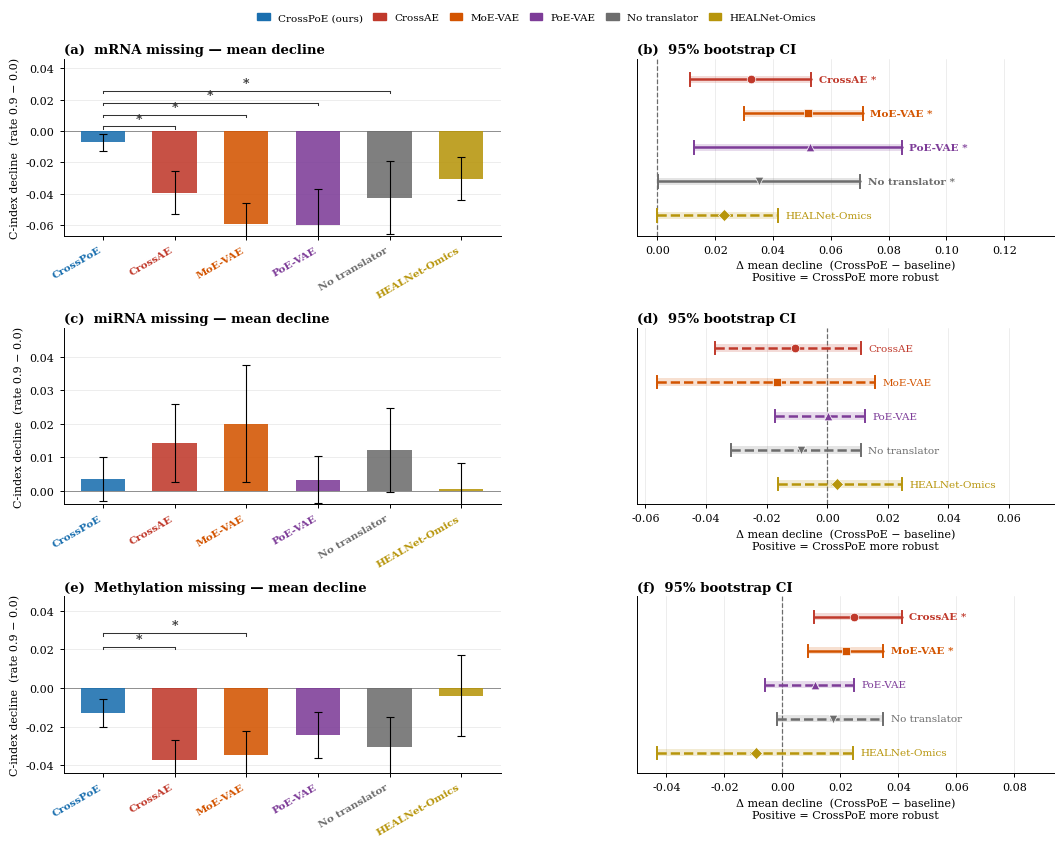

In [102]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import numpy as np

# ── NeurIPS-grade typography & style ─────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          9,
    "axes.titlesize":     10,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "axes.linewidth":     0.7,
    "xtick.major.width":  0.7,
    "ytick.major.width":  0.7,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,   # embeds fonts for camera-ready
    "ps.fonttype":        42,
})

# ── Data configuration ────────────────────────────────────────────────────────
modalities  = ["rna", "mirna", "methyl"]
mod_labels  = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}
baselines   = ["CrossAE", "MoE-VAE", "PoE-VAE", "No translator", "HEALNet-Omics"]
mcar_dicts  = [mcar_clue, mcar_mvae, mcar_vanilla, mcar_no_trans, mcar_healnet_lite]

# ── Palette: accessible, print-safe ──────────────────────────────────────────
CROSSPOE_COLOR  = "#1a6faf"
BASELINE_COLORS = ["#c0392b", "#d35400", "#7d3c98", "#6d6d6d", "#b7950b"]
MARKER_STYLES   = ["o", "s", "^", "v", "D"]

def get_stars(lo):
    return "*" if lo > 0 else "n.s."

# ── Pre-collect all data so we can set consistent y-axis limits ───────────────
all_data = {}
for mod in modalities:
    crosspoe_dec  = get_fold_declines_single(mcar_crossPoE, mod=mod)
    baseline_data = []
    for mcar_dict in mcar_dicts:
        b_dec = get_fold_declines_single(mcar_dict, mod=mod)
        obs, lo, hi = bootstrap_ci_decline_diff(crosspoe_dec, b_dec)
        baseline_data.append({
            "dec":   b_dec,
            "mean":  b_dec.mean(),
            "se":    b_dec.std() / np.sqrt(len(b_dec)),
            "obs":   obs, "lo": lo, "hi": hi,
            "stars": get_stars(lo),
        })
    all_data[mod] = {
        "crosspoe_dec":  crosspoe_dec,
        "crosspoe_mean": crosspoe_dec.mean(),
        "crosspoe_se":   crosspoe_dec.std() / np.sqrt(len(crosspoe_dec)),
        "baselines":     baseline_data,
    }

# ── Layout: 3 rows (modalities) × 2 cols (bar | CI forest) ──────────────────
fig = plt.figure(figsize=(11, 8.5))
outer = gridspec.GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[1.05, 1],
    hspace=0.52,
    wspace=0.32,
    left=0.07, right=0.97,
    top=0.91, bottom=0.07,
)

for row, mod in enumerate(modalities):
    d           = all_data[mod]
    cp_mean     = d["crosspoe_mean"]
    cp_se       = d["crosspoe_se"]
    b_data      = d["baselines"]
    b_means     = [b["mean"]  for b in b_data]
    b_ses       = [b["se"]    for b in b_data]
    obs_list    = [b["obs"]   for b in b_data]
    lo_list     = [b["lo"]    for b in b_data]
    hi_list     = [b["hi"]    for b in b_data]
    stars_list  = [b["stars"] for b in b_data]

    ax_bar = fig.add_subplot(outer[row, 0])
    ax_ci  = fig.add_subplot(outer[row, 1])

    # ── BAR CHART ─────────────────────────────────────────────────────────────
    all_means  = [cp_mean] + b_means
    all_ses    = [cp_se]   + b_ses
    all_colors = [CROSSPOE_COLOR] + BASELINE_COLORS
    all_labels = ["CrossPoE"] + baselines
    n_bars     = len(all_labels)
    xs         = np.arange(n_bars)
    bar_w      = 0.62

    bars = ax_bar.bar(
        xs, all_means,
        width=bar_w,
        color=all_colors,
        alpha=0.88,
        zorder=3,
        linewidth=0,
    )

    # Error bars drawn separately for finer control
    ax_bar.errorbar(
        xs, all_means, yerr=all_ses,
        fmt="none", color="black",
        capsize=2.8, capthick=0.8,
        elinewidth=0.8, zorder=4,
    )

    # Zero line
    ax_bar.axhline(0, color="black", linewidth=0.7, linestyle="-", alpha=0.4, zorder=2)

    # Significance brackets — only for sig comparisons, drawn from bar 0
    # Find y ceiling for bracket placement
    all_tops = [m + s for m, s in zip(all_means, all_ses)]
    y_top    = max(t for t in all_tops if not np.isnan(t))
    y_floor  = min(m for m in all_means if not np.isnan(m))
    y_range  = y_top - y_floor
    bracket_base = y_top + y_range * 0.08
    bracket_step = y_range * 0.13

    sig_count = 0
    for i, (stars, color) in enumerate(zip(stars_list, BASELINE_COLORS)):
        if stars == "n.s.":
            continue
        bk_y  = bracket_base + sig_count * bracket_step
        tick_h = y_range * 0.025
        # Horizontal bracket
        ax_bar.plot([0, i + 1], [bk_y, bk_y],
                    color="#333333", linewidth=0.75, zorder=5)
        # Left tick
        ax_bar.plot([0, 0], [bk_y - tick_h, bk_y],
                    color="#333333", linewidth=0.75, zorder=5)
        # Right tick
        ax_bar.plot([i+1, i+1], [bk_y - tick_h, bk_y],
                    color="#333333", linewidth=0.75, zorder=5)
        # Star
        ax_bar.text(
            (i + 1) / 2, bk_y + y_range * 0.01,
            stars, ha="center", va="bottom",
            fontsize=9, color="#333333", fontweight="bold",
        )
        sig_count += 1

    # Axis formatting
    ax_bar.set_xticks(xs)
    ax_bar.set_xticklabels(all_labels, rotation=30, ha="right", fontsize=7.5)
    for tick, color in zip(ax_bar.get_xticklabels(), all_colors):
        tick.set_color(color)
        tick.set_fontweight("semibold")

    ax_bar.set_ylabel("C-index decline  (rate 0.9 − 0.0)", fontsize=8)
    ax_bar.set_title(
        f"({chr(97 + row*2)})  {mod_labels[mod]} missing — mean decline",
        fontsize=9.5, fontweight="bold", loc="left", pad=4,
    )
    ax_bar.set_xlim(-0.55, n_bars - 0.45)
    ax_bar.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax_bar.grid(axis="y", linewidth=0.4, alpha=0.4, zorder=0)
    ax_bar.set_axisbelow(True)

    # Expand y so brackets don't clip
    ax_bar.set_ylim(
        y_floor - y_range * 0.12,
        bracket_base + sig_count * bracket_step + y_range * 0.22,
    )

    # ── FOREST / CI PLOT ──────────────────────────────────────────────────────
    n_b   = len(baselines)
    y_pos = np.arange(n_b - 1, -1, -1)   # top-to-bottom order

    for i, (name, obs, lo, hi, stars, color, marker) in enumerate(
            zip(baselines, obs_list, lo_list, hi_list,
                stars_list, BASELINE_COLORS, MARKER_STYLES)):

        yi = y_pos[i]
        sig = (stars != "n.s.")

        # CI band — shaded rectangle for visual weight
        rect_h = 0.22
        ax_ci.barh(
            yi, hi - lo, left=lo, height=rect_h,
            color=color, alpha=0.18, zorder=2,
        )
        # CI line
        ax_ci.plot(
            [lo, hi], [yi, yi],
            color=color, linewidth=1.8,
            solid_capstyle="round", zorder=3,
            linestyle="-" if sig else "--",
        )
        # End caps
        for cap_x in [lo, hi]:
            ax_ci.plot(
                [cap_x, cap_x], [yi - 0.18, yi + 0.18],
                color=color, linewidth=1.4, zorder=4,
            )
        # Observed point
        ax_ci.scatter(
            obs, yi,
            color=color, s=38,
            marker=marker,
            zorder=5,
            edgecolors="white", linewidths=0.5,
        )
        # Label: name + CI + star
        star_str = f" {stars}" if sig else ""
        ax_ci.text(
            hi + (max(hi_list) - min(lo_list)) * 0.03,
            yi,
            f"{name}{star_str}",
            va="center", ha="left",
            fontsize=7.5, color=color,
            fontweight="bold" if sig else "normal",
        )

    # Zero reference
    ax_ci.axvline(0, color="black", linewidth=0.9,
                  linestyle="--", alpha=0.55, zorder=1)

    ax_ci.set_yticks([])
    ax_ci.set_ylim(-0.6, n_b - 0.4)
    ax_ci.set_xlabel(
        "Δ mean decline  (CrossPoE − baseline)\nPositive = CrossPoE more robust",
        fontsize=8,
    )
    ax_ci.set_title(
        f"({chr(97 + row*2 + 1)})  95% bootstrap CI",
        fontsize=9.5, fontweight="bold", loc="left", pad=4,
    )

    # Auto x-limit with label padding
    x_span    = max(hi_list) - min(lo_list)
    label_pad = x_span * 0.62
    ax_ci.set_xlim(min(lo_list) - x_span * 0.08, max(hi_list) + label_pad)
    ax_ci.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax_ci.grid(axis="x", linewidth=0.4, alpha=0.4, zorder=0)
    ax_ci.set_axisbelow(True)

# ── Figure-level legend and title ─────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=CROSSPOE_COLOR, label="CrossPoE (ours)"),
] + [
    mpatches.Patch(color=c, label=n)
    for c, n in zip(BASELINE_COLORS, baselines)
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=6,
    fontsize=7.5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.975),
    columnspacing=1.0,
    handlelength=1.2,
)

# ── Save ──────────────────────────────────────────────────────────────────────
base_path = "/g/data/yr31/rn8079/PhD/term2_development/plots/mcar_bootstrap_ci_neurips"

fig.savefig(f"{base_path}.svg", bbox_inches="tight", format="svg")
fig.savefig(f"{base_path}.png", dpi=300, bbox_inches="tight", format="png")

print(f"Saved:\n  {base_path}.svg\n  {base_path}.png")
plt.show()

## Natural Missingness

In [173]:
# ── Modality combination configurations ──────────────────────────────────────
# Each entry: (label, rna_on, mirna_on, methyl_on)
MODALITY_COMBOS = [
    # Single modalities
    ("RNA only",         True,  False, False),
    ("miRNA only",       False, True,  False),
    ("methylation only", False, False, True),
    # Pairs
    ("RNA + miRNA",      True,  True,  False),
    ("RNA + methyl",     True,  False, True),
    ("miRNA + methyl",   False, True,  True),
]


def run_modality_combo(cfg, rna_on, mirna_on, methyl_on, label):
    """
    Train CrossPoE with a fixed modality subset.
    Active modalities are passed via config so BioPoE.forward() and
    compute_loss can gate encoders, decoders, and translation heads
    to only the active set. Masks are NOT globally zeroed — instead
    the active set is enforced at the batch level inside the model.
    """
    import copy

    cfg_run = copy.deepcopy(cfg)

    # Encode active modality set
    active = []
    if rna_on:    active.append("rna")
    if mirna_on:  active.append("mirna")
    if methyl_on: active.append("methyl")
    cfg_run["active_modalities"] = active

    # Single modality: no translation possible
    # Two modalities: translation between the two active ones only
    n_active = len(active)
    if n_active == 1:
        cfg_run["translation_warmup_epochs"] = 9999

    # Save and zero masks for inactive modalities so DataLoader
    # never serves data for them — this is safe because we are
    # also gating inside the model
    orig_rna    = TCGABRCADataset._rna_mask.copy()
    orig_mirna  = TCGABRCADataset._mirna_mask.copy()
    orig_methyl = TCGABRCADataset._methyl_mask.copy()

    if not rna_on:
        TCGABRCADataset._rna_mask    = np.zeros_like(orig_rna,    dtype=bool)
    if not mirna_on:
        TCGABRCADataset._mirna_mask  = np.zeros_like(orig_mirna,  dtype=bool)
    if not methyl_on:
        TCGABRCADataset._methyl_mask = np.zeros_like(orig_methyl, dtype=bool)

    try:
        fold_results = run_cross_validation(cfg_run)
    finally:
        TCGABRCADataset._rna_mask    = orig_rna
        TCGABRCADataset._mirna_mask  = orig_mirna
        TCGABRCADataset._methyl_mask = orig_methyl

    cidxs   = [fr["val_metrics"]["c_index"] for fr in fold_results]
    mean_ci = np.nanmean(cidxs)
    sd_ci   = np.nanstd(cidxs)
    print(f"\n  [{label}]  C-index: {mean_ci:.4f} ± {sd_ci:.4f}")
    return fold_results, mean_ci, sd_ci


def run_all_modality_combos(cfg):
    """
    Run all 7 modality combinations and print a summary table.
    Each combination is a fully independent training run with its own
    5-fold CV — same splits, same scalers, same architecture.
    """
    results = {}

    for label, rna_on, mirna_on, methyl_on in MODALITY_COMBOS:
        print(f"\n{'='*60}")
        print(f"MODALITY COMBINATION: {label}")
        print(f"  RNA={rna_on}  miRNA={mirna_on}  methylation={methyl_on}")
        print(f"{'='*60}")

        fold_results, mean_ci, sd_ci = run_modality_combo(
            cfg, rna_on, mirna_on, methyl_on, label
        )
        results[label] = {
            "fold_results": fold_results,
            "mean_ci":      mean_ci,
            "sd_ci":        sd_ci,
            "rna_on":       rna_on,
            "mirna_on":     mirna_on,
            "methyl_on":    methyl_on,
        }

    # Summary table
    print(f"\n{'='*65}")
    print("MODALITY COMBINATION SUMMARY")
    print(f"{'='*65}")
    print(f"  {'Combination':<25} {'C-index':>8} {'SD':>7}")
    print(f"  {'-'*43}")
    for label, rna_on, mirna_on, methyl_on in MODALITY_COMBOS:
        r = results[label]
        print(f"  {label:<25} {r['mean_ci']:>8.4f} {r['sd_ci']:>7.4f}")
    print(f"{'='*65}")

    return results


combo_results = run_all_modality_combos(CONFIG)



MODALITY COMBINATION: RNA only
  RNA=True  miRNA=False  methylation=False

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 0.5245 (surv=3.886 kl=0.141 recon=1.119 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5938
  Epoch   2/100 | beta=0.07 | Train loss: 0.5044 (surv=3.751 kl=0.174 recon=1.055 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7037
  Epoch   3/100 | beta=0.10 | Train loss: 0.4933 (surv=3.612 kl=0.207 recon=1.024 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7047
  Epoch   4/100 | beta=0.13 | Train loss: 0.4723 (surv=3.297 kl=0.246 recon=1.012 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6949
  Epoch   5/100 | beta=0.17 | Train loss: 0.4595 (surv=3.047 kl=0.277 recon=0.995 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6958
  Epoch   6/100 | beta=0.20 | Train loss: 0.4234 (surv=2.615 kl=0.272 recon=0.983 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5239
  Epoch   7

## Ablation

In [138]:
# =============================================================================
# COMPONENT ABLATION RUNS
# All ablations use identical architecture and CV protocol to canonical CrossPoE.
# Each is a minimal diff from CONFIG — only the named component changes.
# =============================================================================
import copy

# ── Ablation 1: No cycle consistency ─────────────────────────────────────────
# Tests contribution of round-trip penalty to translation head training.
# Prediction: translation heads collapse toward mean-seeking solutions,
# hurting MCAR robustness more than full-data C-index.
cfg_no_cycle = copy.deepcopy(CONFIG)
cfg_no_cycle["lambda_cycle"] = 0.0

print("=" * 60)
print("ABLATION 1: No cycle consistency (lambda_cycle=0.0)")
print("=" * 60)
fold_results_no_cycle = run_cross_validation(cfg_no_cycle)
cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results_no_cycle]
print(f"\nNo-cycle C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")

# ── Ablation 2: No survival-preserving translation loss ───────────────────────
# Tests whether survival geometry in the translation heads matters.
# Prediction: small or no full-data effect, measurable MCAR degradation
# because translated pseudo-posteriors no longer preserve risk scores.
cfg_no_surv_trans = copy.deepcopy(CONFIG)
cfg_no_surv_trans["lambda_surv_trans"] = 0.0

print("=" * 60)
print("ABLATION 2: No survival-preserving translation (lambda_surv_trans=0.0)")
print("=" * 60)
fold_results_no_surv_trans = run_cross_validation(cfg_no_surv_trans)
cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results_no_surv_trans]
print(f"\nNo-surv-trans C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")


# ── ABLATION 3 No-translation fusion ablation ────────────────────────────────────────────
# Translator is instantiated and trained on consistency/cycle/surv-trans losses
# for fully observed pairs, but never injected into the PoE precision sum.
# Tests whether the fusion injection specifically is what drives robustness,
# not just the presence of translation supervision.
cfg_no_fusion = copy.deepcopy(CONFIG)
cfg_no_fusion["translation_warmup_epochs"] = 9999

print("=" * 60)
print("ABLATION 3: No translation fusion (warmup=9999)")
print("=" * 60)
fold_results_phase1 = run_cross_validation(cfg_no_fusion)
cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results_phase1]
print(f"\nNo-fusion C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")

ABLATION 1: No cycle consistency (lambda_cycle=0.0)

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 1.6441 (surv=3.908 kl=0.369 recon=11.346 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6023
  Epoch   2/100 | beta=0.07 | Train loss: 1.5655 (surv=3.697 kl=0.470 recon=10.728 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6961
  Epoch   3/100 | beta=0.10 | Train loss: 1.5423 (surv=3.673 kl=0.577 recon=10.310 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6691
  Epoch   4/100 | beta=0.13 | Train loss: 1.5233 (surv=3.485 kl=0.682 recon=9.966 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7065
  Epoch   5/100 | beta=0.17 | Train loss: 1.4994 (surv=3.216 kl=0.780 recon=9.527 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7034
  Epoch   6/100 | beta=0.20 | Train loss: 1.4758 (surv=2.845 kl=0.865 recon=9.150 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6743
  Epoch   7/100 | beta=0.23 | T

In [139]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ABLATION SUMMARY")
print("=" * 60)

canonical = np.nanmean([fr["val_metrics"]["c_index"] for fr in fold_results_survival])

ablations = [
    ("CrossPoE (canonical)",              fold_results_survival),
    ("No cycle consistency",              fold_results_no_cycle),
    ("No survival-preserving trans loss", fold_results_no_surv_trans),
    ("No translator fusion",              fold_results_phase1),
]

print(f"{'Model':<40} {'C-index':>8} {'SD':>6} {'Delta':>8}")
print("-" * 65)
for name, results in ablations:
    cidxs = [fr["val_metrics"]["c_index"] for fr in results]
    mean  = np.nanmean(cidxs)
    sd    = np.nanstd(cidxs)
    delta = mean - canonical if name != "CrossPoE (canonical)" else 0.0
    print(f"  {name:<38} {mean:.4f}  {sd:.4f}  {delta:+.4f}")


ABLATION SUMMARY
Model                                     C-index     SD    Delta
-----------------------------------------------------------------
  CrossPoE (canonical)                   0.6838  0.0557  +0.0000
  No cycle consistency                   0.6821  0.0517  -0.0017
  No survival-preserving trans loss      0.6809  0.0569  -0.0029
  No translator fusion                   0.6902  0.0504  +0.0065


In [142]:
# =============================================================================
# MCAR EVALUATION FOR COMPONENT ABLATIONS
# =============================================================================

rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
modalities = ["rna", "mirna", "methyl"]

# ── Ablation 1: No cycle consistency ─────────────────────────────────────────
print("Running MCAR — No cycle consistency")
mcar_no_cycle = run_mcar_single(fold_results_no_cycle, cfg_no_cycle)

# ── Ablation 2: No survival-preserving translation loss ──────────────────────
print("\nRunning MCAR — No survival-preserving trans loss")
mcar_no_surv_trans = run_mcar_single(fold_results_no_surv_trans, cfg_no_surv_trans)

# ── Ablation 3: No translation fusion ──────────────────────
print("\nRunning MCAR — No translation fusion")
mcar_no_trans = run_mcar_single(fold_results_phase1, cfg_no_fusion)


Running MCAR — No cycle consistency

MCAR ROBUSTNESS
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.682   0.676   0.668   0.666   0.667 
  mirna     0.682   0.680   0.678   0.681   0.686 
  methyl    0.682   0.673   0.673   0.663   0.657 

Running MCAR — No survival-preserving trans loss

MCAR ROBUSTNESS
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.681   0.665   0.657   0.653   0.645 
  mirna     0.681   0.687   0.687   0.697   0.698 
  methyl    0.681   0.665   0.667   0.658   0.655 

Running MCAR — No translation fusion

MCAR ROBUSTNESS
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.690   0.663   0.659   0.654   0.648 
  mirna     0.690   0.692   0.690   0.702   0.702 
  methyl    0.690   0.676   0.669   0.667   0.660 


In [143]:
ablation_mcar = [
    ("CrossPoE (canonical)",             mcar_crossPoE),
    ("- cycle consistency",              mcar_no_cycle),
    ("- surv-preserving trans loss",     mcar_no_surv_trans),
    ("- translation heads",              mcar_no_trans),
]

print(f"\n{'='*65}")
print("RNA MCAR DECLINE — COMPONENT ABLATION")
print(f"{'='*65}")
print(f"  {'Model':<40} {'rate=0.0':>8} {'rate=0.9':>8} {'Decline':>8}")
print(f"  {'-'*62}")
for name, mcar in ablation_mcar:
    r0 = np.nanmean(mcar["rna"][0.0])
    r9 = np.nanmean(mcar["rna"][0.9])
    print(f"  {name:<40} {r0:.4f}   {r9:.4f}   {r9 - r0:+.4f}")


RNA MCAR DECLINE — COMPONENT ABLATION
  Model                                    rate=0.0 rate=0.9  Decline
  --------------------------------------------------------------
  CrossPoE (canonical)                     0.6838   0.6764   -0.0073
  - cycle consistency                      0.6821   0.6666   -0.0155
  - surv-preserving trans loss             0.6809   0.6451   -0.0358
  - translation heads                      0.6902   0.6477   -0.0426


## Run Full Model

In [58]:
print("=" * 60)
print("PHASE 4 BASELINE: PFI Survival")
print("=" * 60)
fold_results_survival = run_cross_validation(CONFIG)

PHASE 4 BASELINE: PFI Survival

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 1.6441 (surv=3.908 kl=0.369 recon=11.346 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6023
  Epoch   2/100 | beta=0.07 | Train loss: 1.5655 (surv=3.697 kl=0.470 recon=10.728 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6961
  Epoch   3/100 | beta=0.10 | Train loss: 1.5423 (surv=3.673 kl=0.577 recon=10.310 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6691
  Epoch   4/100 | beta=0.13 | Train loss: 1.5233 (surv=3.485 kl=0.682 recon=9.966 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7065
  Epoch   5/100 | beta=0.17 | Train loss: 1.4994 (surv=3.216 kl=0.780 recon=9.527 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7034
  Epoch   6/100 | beta=0.20 | Train loss: 1.4758 (surv=2.845 kl=0.865 recon=9.150 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6743
  Epoch   7/100 | beta=0.23 | Train loss: 1.4639 (su

In [59]:
mcar_crossPoE = run_mcar_single(fold_results_survival, CONFIG)


MCAR ROBUSTNESS
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.684   0.681   0.678   0.677   0.676 
  mirna     0.684   0.681   0.682   0.687   0.687 
  methyl    0.684   0.675   0.677   0.675   0.671 


## C-index statisical test

In [146]:
def bootstrap_ci_cindex_diff(arr1, arr2, n_boot=10000, seed=42, ci=95):
    """
    Bootstrap CI for mean(arr1) - mean(arr2) on fold-level C-indices.
    Positive = arr1 has higher C-index than arr2.
    """
    rng   = np.random.RandomState(seed)
    diffs = []
    n     = len(arr1)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        diffs.append(arr1[idx].mean() - arr2[idx].mean())
    diffs = np.array(diffs)
    lo  = np.percentile(diffs, (100 - ci) / 2)
    hi  = np.percentile(diffs, 100 - (100 - ci) / 2)
    obs = arr1.mean() - arr2.mean()
    return obs, lo, hi
    
# ── Extract fold-level C-indices ──────────────────────────────────────────────
crosspoe_cidxs = np.array([fr["val_metrics"]["c_index"] for fr in fold_results_survival])

baseline_cidxs = {
    "CrossAE":       np.array([fr["val_metrics"]["c_index"] for fr in fold_results_clue]),
    "MoE-VAE":       np.array([fr["val_metrics"]["c_index"] for fr in fold_results_mvae]),
    "PoE-VAE":       np.array([fr["val_metrics"]["c_index"] for fr in fold_results_vanilla]),
    "MOFA+":         np.array([fr["val_metrics"]["c_index"] for fr in fold_results_mofa]),
    "No translator": np.array([fr["val_metrics"]["c_index"] for fr in fold_results_phase1]),
}

print("=" * 70)
print("BOOTSTRAP 95% CI — FULL-DATA C-INDEX DIFFERENCE")
print("CrossPoE (canonical, alpha=0.75) vs each baseline")
print("Positive = CrossPoE has higher C-index")
print("=" * 70)
print(f"\n  CrossPoE folds: {crosspoe_cidxs}  mean={crosspoe_cidxs.mean():.4f}")
print()

for name, b_cidxs in baseline_cidxs.items():
    obs, lo, hi = bootstrap_ci_cindex_diff(crosspoe_cidxs, b_cidxs)
    excludes_zero = "excludes 0 *" if lo > 0 else "includes 0"
    print(f"  CrossPoE vs {name:<20} "
          f"obs={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  {excludes_zero}  "
          f"(baseline mean={b_cidxs.mean():.4f})")

BOOTSTRAP 95% CI — FULL-DATA C-INDEX DIFFERENCE
CrossPoE (canonical, alpha=0.75) vs each baseline
Positive = CrossPoE has higher C-index

  CrossPoE folds: [0.734375   0.65499701 0.62055477 0.64419961 0.76468894]  mean=0.6838

  CrossPoE vs CrossAE              obs=+0.0025  95% CI [-0.0059, +0.0109]  includes 0  (baseline mean=0.6813)
  CrossPoE vs MoE-VAE              obs=+0.0263  95% CI [-0.0080, +0.0515]  includes 0  (baseline mean=0.6575)
  CrossPoE vs PoE-VAE              obs=+0.0252  95% CI [-0.0113, +0.0538]  includes 0  (baseline mean=0.6586)
  CrossPoE vs MOFA+                obs=+0.1017  95% CI [+0.0656, +0.1322]  excludes 0 *  (baseline mean=0.5820)
  CrossPoE vs No translator        obs=-0.0065  95% CI [-0.0312, +0.0146]  includes 0  (baseline mean=0.6902)


## Dropout Variant

In [147]:
cfg_dropout = copy.deepcopy(CONFIG)
cfg_dropout["use_modality_dropout"] = True
cfg_dropout["min_epochs"] = 50
fold_results_dropout = run_cross_validation(cfg_dropout)


FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 1.6441 (surv=3.908 kl=0.369 recon=11.346 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6023
  Epoch   2/100 | beta=0.07 | Train loss: 1.5655 (surv=3.697 kl=0.470 recon=10.728 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6961
  Epoch   3/100 | beta=0.10 | Train loss: 1.5423 (surv=3.673 kl=0.577 recon=10.310 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6691
  Epoch   4/100 | beta=0.13 | Train loss: 1.5233 (surv=3.485 kl=0.682 recon=9.966 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7065
  Epoch   5/100 | beta=0.17 | Train loss: 1.4994 (surv=3.216 kl=0.780 recon=9.527 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7034
  Epoch   6/100 | beta=0.20 | Train loss: 1.4758 (surv=2.845 kl=0.865 recon=9.150 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6743
  Epoch   7/100 | beta=0.23 | Train loss: 1.4639 (surv=2.377 kl=0.939 recon=8.951 t

In [148]:
# =============================================================================
# MCAR EVALUATION FOR COMPONENT ABLATIONS
# =============================================================================

rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
modalities = ["rna", "mirna", "methyl"]

# ── Ablation 1: No cycle consistency ─────────────────────────────────────────
print("Running MCAR — No cycle consistency")
mcar_dropout = run_mcar_single(fold_results_dropout, cfg_dropout)

Running MCAR — No cycle consistency

MCAR ROBUSTNESS
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.679   0.678   0.663   0.659   0.658 
  mirna     0.679   0.676   0.677   0.684   0.685 
  methyl    0.679   0.670   0.677   0.674   0.674 


In [154]:
print(f"\n{'='*65}")
print("RNA MCAR DECLINE — COMPONENT ABLATION")
print(f"{'='*65}")
print(f"  {'Model':<40} {'rate=0.0':>8} {'rate=0.9':>8} {'Decline':>8}")
print(f"  {'-'*62}")
name="Dropout"
r0 = np.nanmean(mcar_dropout["rna"][0.0])
r9 = np.nanmean(mcar_dropout["rna"][0.9])
print(f"  {name:<40} {r0:.4f}   {r9:.4f}   {r9 - r0:+.4f}")


RNA MCAR DECLINE — COMPONENT ABLATION
  Model                                    rate=0.0 rate=0.9  Decline
  --------------------------------------------------------------
  Dropout                                  0.6786   0.6576   -0.0209


## Jacobian Analysis

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Jacobian Analysis — Cross-Modal Translation Attribution
# ─────────────────────────────────────────────────────────────────────────────
# For each translation direction, computes:
#   J = ∂μ_pseudo_tgt / ∂μ_src  (48×48 matrix)
# Aggregated across all fully-observed samples in the validation set.
# Tells us which source latent dimensions most strongly drive each
# target latent dimension through the translation head.
# ─────────────────────────────────────────────────────────────────────────────

def compute_translation_jacobians(fold_results, cfg, fold_idx=0):
    """
    Compute mean Jacobian ∂μ_pseudo / ∂μ_src for all 6 translation directions.

    Returns:
        jacobians: dict mapping direction key -> mean Jacobian (48×48 numpy array)
        jacobian_stds: dict mapping direction key -> std of Jacobian (48×48)
    """
    import torch.autograd.functional as AF

    fr = fold_results[fold_idx]

    # ── Reproduce val split ───────────────────────────────────────────────────
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    for i, (_, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        if i == fr["fold"] - 1:
            break

    val_dataset = TCGABRCADataset(
        indices=val_idx,
        rna_scaler=fr["scalers"]["rna"],
        mirna_scaler=fr["scalers"]["mirna"],
        methyl_scaler=fr["scalers"]["methyl"],
        dropout_probs=None,
    )
    val_loader = DataLoader(val_dataset, batch_size=64,
                            shuffle=False, collate_fn=collate_fn, num_workers=0)

    # ── Load model ────────────────────────────────────────────────────────────
    model      = BioPoE(latent_dim=N_LATENT).to(device)
    translator = CrossModalTranslator(N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
    model.load_state_dict({k: v.to(device) for k, v in fr["model_state"]["model"].items()})
    translator.load_state_dict({k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
    model.eval()
    translator.eval()

    MODALITY_NAMES = ["rna", "mirna", "methyl"]
    directions = [(s, t) for s in range(3) for t in range(3) if s != t]

    # Storage: list of (48×48) Jacobians per direction
    jacobian_samples = {f"{s}_to_{t}": [] for s, t in directions}

    with torch.no_grad():
        for batch in val_loader:
            batch  = move_batch_to_device(batch, device)
            mask   = batch["mask"]
            outputs = model(batch, translator=translator,
                            epoch=cfg["n_epochs"],
                            translation_warmup_epochs=cfg["translation_warmup_epochs"])
            mus     = outputs["mus"]
            logvars = outputs["logvars"]

            for src, tgt in directions:
                key      = f"{src}_to_{tgt}"
                both_obs = mask[:, src] & mask[:, tgt]
                if not both_obs.any():
                    continue

                mu_src_batch  = mus[src][both_obs].detach()     # (N, 48)
                lv_src_batch  = logvars[src][both_obs].detach() # (N, 48)
                head          = translator.translation_heads[key]

                # Compute Jacobian per sample then average
                # ∂μ_pseudo / ∂μ_src is a 48×48 matrix per sample
                for i in range(mu_src_batch.shape[0]):
                    mu_i  = mu_src_batch[i:i+1].requires_grad_(True)  # (1, 48)
                    lv_i  = lv_src_batch[i:i+1]                       # (1, 48)

                    # Forward through translation head, extract μ_pseudo only
                    def mu_pseudo_fn(mu_in):
                        h   = torch.cat([mu_in, lv_i], dim=-1)
                        out = head.net(h)
                        return out[:, :N_LATENT]   # μ_pseudo, shape (1, 48)

                    # jacobian returns (1, 48, 1, 48) → squeeze to (48, 48)
                    J = torch.autograd.functional.jacobian(
                        mu_pseudo_fn, mu_i, create_graph=False, strict=False
                    )
                    J = J.squeeze().cpu().numpy()  # (48, 48): rows=tgt dims, cols=src dims
                    jacobian_samples[key].append(J)

    # ── Aggregate ─────────────────────────────────────────────────────────────
    jacobians     = {}
    jacobian_stds = {}
    for key, jlist in jacobian_samples.items():
        if not jlist:
            continue
        stack = np.stack(jlist, axis=0)          # (N_samples, 48, 48)
        jacobians[key]     = stack.mean(axis=0)  # (48, 48)
        jacobian_stds[key] = stack.std(axis=0)   # (48, 48)

    return jacobians, jacobian_stds


def print_jacobian_summary(jacobians):
    """
    Print summary statistics for each translation direction.
    Shows which source dimensions have the highest mean absolute influence
    on the target latent space.
    """
    MODALITY_NAMES = ["RNA", "miRNA", "Methyl"]
    print("=" * 70)
    print("JACOBIAN SUMMARY — ∂μ_pseudo_tgt / ∂μ_src")
    print("Mean absolute Jacobian aggregated across validation samples")
    print("=" * 70)

    for key, J in jacobians.items():
        src_idx, tgt_idx = int(key[0]), int(key[5])
        src_name = MODALITY_NAMES[src_idx]
        tgt_name = MODALITY_NAMES[tgt_idx]

        abs_J = np.abs(J)  # (48, 48)

        # Top source dimensions by total influence (sum over target dims)
        src_influence = abs_J.sum(axis=0)  # (48,) — influence of each src dim
        top_src = np.argsort(src_influence)[::-1][:5]

        # Top target dimensions most influenced (sum over source dims)
        tgt_sensitivity = abs_J.sum(axis=1)  # (48,) — sensitivity of each tgt dim
        top_tgt = np.argsort(tgt_sensitivity)[::-1][:5]

        print(f"\n{src_name} → {tgt_name}  (key: {key})")
        print(f"  Mean |J|:           {abs_J.mean():.4f}")
        print(f"  Max  |J|:           {abs_J.max():.4f}")
        print(f"  Frobenius norm:     {np.linalg.norm(J, 'fro'):.4f}")
        print(f"  Top source dims:    {top_src.tolist()}  (by total outgoing influence)")
        print(f"  Top target dims:    {top_tgt.tolist()}  (by total incoming sensitivity)")

def compute_translation_jacobians_all_folds(fold_results, cfg, top_k=5):
    """
    Runs Jacobian analysis across all folds.
    Returns:
        jacobians_mean : dict key -> (48,48) mean J averaged across folds
        jacobians_std  : dict key -> (48,48) std across folds
        fold_jacs      : list of per-fold jacobian dicts (for majority vote)
    """
    all_fold_jacs = []

    for fold_idx in range(len(fold_results)):
        print(f"  Computing Jacobians — fold {fold_idx + 1}/{len(fold_results)}")
        jacs, _ = compute_translation_jacobians(fold_results, cfg, fold_idx=fold_idx)
        all_fold_jacs.append(jacs)

    # Average Jacobians across folds
    directions = list(all_fold_jacs[0].keys())
    jacobians_mean = {}
    jacobians_std  = {}
    for key in directions:
        stack = np.stack([fj[key] for fj in all_fold_jacs], axis=0)  # (n_folds, 48, 48)
        jacobians_mean[key] = stack.mean(axis=0)
        jacobians_std[key]  = stack.std(axis=0)

    return jacobians_mean, jacobians_std, all_fold_jacs


def get_majority_vote_hub_dims(fold_jacs, jacobians_mean,
                               top_k=8, min_folds=4, min_global_appearances=4):
    """
    Two-condition hub identification:
      1. Fold consistency: dim appears in top_k source OR target in >= min_folds folds
      2. Global presence: dim accumulates >= min_global_appearances in the mean
                          Jacobian heatmap (top-5 source + target across all 6 directions)
    Both conditions must be satisfied.

    Args:
        fold_jacs              : list of per-fold jacobian dicts
        jacobians_mean         : mean jacobian dict (from compute_translation_jacobians_all_folds)
        top_k                  : top-k per direction for fold consistency check
        min_folds              : minimum folds for condition 1
        min_global_appearances : minimum heatmap score for condition 2
    """
    from collections import Counter

    directions = list(jacobians_mean.keys())
    n_folds    = len(fold_jacs)

    # ── Condition 1: fold consistency ─────────────────────────────────────────
    dim_fold_counts = Counter()
    for fold_jac in fold_jacs:
        dims_this_fold = set()
        for key, J in fold_jac.items():
            abs_J = np.abs(J)
            src_influence   = abs_J.sum(axis=0)
            tgt_sensitivity = abs_J.sum(axis=1)
            top_src = set(np.argsort(src_influence)[::-1][:top_k].tolist())
            top_tgt = set(np.argsort(tgt_sensitivity)[::-1][:top_k].tolist())
            dims_this_fold |= top_src | top_tgt
        for d in dims_this_fold:
            dim_fold_counts[d] += 1

    passes_consistency = {d for d, cnt in dim_fold_counts.items()
                          if cnt >= min_folds}

    # ── Condition 2: global presence in mean Jacobian heatmap ─────────────────
    # Use top-5 for the global check regardless of top_k — keeps this strict
    global_scores = Counter()
    for key, J in jacobians_mean.items():
        abs_J = np.abs(J)
        src_influence   = abs_J.sum(axis=0)
        tgt_sensitivity = abs_J.sum(axis=1)
        top_src = set(np.argsort(src_influence)[::-1][:5].tolist())
        top_tgt = set(np.argsort(tgt_sensitivity)[::-1][:5].tolist())
        for d in top_src | top_tgt:
            global_scores[d] += 1

    passes_global = {d for d, score in global_scores.items()
                     if score >= min_global_appearances}

    # ── Both conditions ───────────────────────────────────────────────────────
    hub_dims_voted = sorted(passes_consistency & passes_global)

    return hub_dims_voted, dict(dim_fold_counts), dict(global_scores)


def print_majority_vote_summary(fold_jacs, jacobians_mean,
                                top_k=8, min_folds=4, min_global_appearances=4):
    hub_dims, fold_counts, global_scores = get_majority_vote_hub_dims(
        fold_jacs, jacobians_mean,
        top_k=top_k, min_folds=min_folds,
        min_global_appearances=min_global_appearances
    )
    n_folds = len(fold_jacs)

    # ── Direction coverage: how many distinct directions each dim appears in ──
    directions = list(jacobians_mean.keys())
    direction_coverage = {}
    for d in fold_counts:
        count = 0
        for key, J in jacobians_mean.items():
            abs_J   = np.abs(J)
            top_src = set(np.argsort(abs_J.sum(axis=0))[::-1][:5].tolist())
            top_tgt = set(np.argsort(abs_J.sum(axis=1))[::-1][:5].tolist())
            if d in top_src or d in top_tgt:
                count += 1
        direction_coverage[d] = count

    n_directions = len(directions)  # 6

    print("=" * 80)
    print(f"JACOBIAN HUB DIMS — two-condition criterion")
    print(f"  Condition 1: top-{top_k} source/target in ≥ {min_folds}/{n_folds} folds")
    print(f"  Condition 2: ≥ {min_global_appearances} global top-5 appearances in mean Jacobian")
    print("=" * 80)
    print(f"  {'Dim':>4}  {'Folds':>7}  {'Global':>9}  {'Dirs':>6}  {'C2':>4}  {'':>8}")
    print(f"  {'-'*4}  {'-'*7}  {'-'*9}  {'-'*6}  {'-'*4}  {'-'*8}")

    # Sort by direction coverage descending, then global score, then fold count
    cond1_dims = sorted(
        [d for d, cnt in fold_counts.items() if cnt >= min_folds],
        key=lambda d: (-direction_coverage[d], -global_scores.get(d, 0), -fold_counts[d])
    )

    for d in cond1_dims:
        fc  = fold_counts[d]
        gs  = global_scores.get(d, 0)
        dc  = direction_coverage[d]
        c2  = "✓" if gs >= min_global_appearances else "✗"
        tag = " ← HUB" if d in hub_dims else ""
        print(f"  {d:>4}  {fc:>3}/{n_folds} folds  "
              f"{gs:>3}/6 score  "
              f"{dc:>2}/{n_directions} dirs  "
              f"C2:{c2}{tag}")

    print(f"\nFinal hub dims (both conditions): {hub_dims}")
    return hub_dims

In [69]:
# Jacobian analysis — all folds with majority vote
print("Running Jacobian analysis across all folds...")
jacobians_mean, jacobians_std, fold_jacs = compute_translation_jacobians_all_folds(
    fold_results_survival, CONFIG
)

Running Jacobian analysis across all folds...
  Computing Jacobians — fold 1/5
  Computing Jacobians — fold 2/5
  Computing Jacobians — fold 3/5
  Computing Jacobians — fold 4/5
  Computing Jacobians — fold 5/5


In [21]:
print_jacobian_summary(jacobians_mean)

JACOBIAN SUMMARY — ∂μ_pseudo_tgt / ∂μ_src
Mean absolute Jacobian aggregated across validation samples

RNA → miRNA  (key: 0_to_1)
  Mean |J|:           0.0118
  Max  |J|:           0.0927
  Frobenius norm:     0.7550
  Top source dims:    [37, 38, 36, 6, 17]  (by total outgoing influence)
  Top target dims:    [37, 6, 38, 5, 10]  (by total incoming sensitivity)

RNA → Methyl  (key: 0_to_2)
  Mean |J|:           0.0090
  Max  |J|:           0.0801
  Frobenius norm:     0.5724
  Top source dims:    [37, 6, 17, 19, 31]  (by total outgoing influence)
  Top target dims:    [37, 6, 17, 12, 10]  (by total incoming sensitivity)

miRNA → RNA  (key: 1_to_0)
  Mean |J|:           0.0083
  Max  |J|:           0.0638
  Frobenius norm:     0.5282
  Top source dims:    [6, 20, 2, 44, 1]  (by total outgoing influence)
  Top target dims:    [12, 38, 17, 6, 27]  (by total incoming sensitivity)

miRNA → Methyl  (key: 1_to_2)
  Mean |J|:           0.0083
  Max  |J|:           0.0679
  Frobenius norm:     

In [70]:
# Majority vote: which hub dims appear in ≥3/5 folds
print("\n--- Majority vote hub dim identification ---")
HUB_DIMS = print_majority_vote_summary(fold_jacs, jacobians_mean,
                                        top_k=8, min_folds=4,
                                        min_global_appearances=4)

print(f"\nHUB_DIMS for IG analysis: {HUB_DIMS}")


--- Majority vote hub dim identification ---
JACOBIAN HUB DIMS — two-condition criterion
  Condition 1: top-8 source/target in ≥ 4/5 folds
  Condition 2: ≥ 4 global top-5 appearances in mean Jacobian
   Dim    Folds     Global    Dirs    C2          
  ----  -------  ---------  ------  ----  --------
     6    4/5 folds    6/6 score   6/6 dirs  C2:✓ ← HUB
    37    4/5 folds    5/6 score   5/6 dirs  C2:✓ ← HUB
    12    5/5 folds    4/6 score   4/6 dirs  C2:✓ ← HUB
    17    4/5 folds    4/6 score   4/6 dirs  C2:✓ ← HUB
    38    4/5 folds    4/6 score   4/6 dirs  C2:✓ ← HUB
     2    5/5 folds    2/6 score   2/6 dirs  C2:✗
    36    5/5 folds    2/6 score   2/6 dirs  C2:✗
    10    4/5 folds    2/6 score   2/6 dirs  C2:✗
    31    4/5 folds    2/6 score   2/6 dirs  C2:✗
     3    4/5 folds    1/6 score   1/6 dirs  C2:✗
    15    4/5 folds    1/6 score   1/6 dirs  C2:✗
    44    4/5 folds    1/6 score   1/6 dirs  C2:✗
    29    5/5 folds    0/6 score   0/6 dirs  C2:✗
    18    4/5 fol

In [71]:
HUB_DIMS = [6, 12, 17, 37]

In [161]:
def plot_jacobian_panel(jacobians, hub_dims,
                        save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/panel_A.pdf"):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap

    directions = ["0_to_1", "0_to_2", "1_to_0", "1_to_2", "2_to_0", "2_to_1"]
    dir_labels  = ["RNA→miRNA", "RNA→Methyl", "miRNA→RNA",
                   "miRNA→Methyl", "Methyl→RNA", "Methyl→miRNA"]

    # ── Build appearance matrix ───────────────────────────────────────────────
    top_k  = 5
    matrix = np.zeros((6, 48))
    for i, d in enumerate(directions):
        J       = jacobians[d]
        abs_J   = np.abs(J)
        src     = np.argsort(abs_J.sum(axis=0))[::-1][:top_k]
        tgt     = np.argsort(abs_J.sum(axis=1))[::-1][:top_k]
        for dim in src: matrix[i, dim] += 1
        for dim in tgt: matrix[i, dim] += 1

    # ── Colormap ──────────────────────────────────────────────────────────────
    cmap = LinearSegmentedColormap.from_list(
        "hub_blue", ["#EEF3FA", "#7BAFD4", "#1A3A6B"], N=256)

    fig, ax = plt.subplots(figsize=(9, 3.8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#F7F9FC")
    plt.subplots_adjust(top=0.78, bottom=0.22, left=0.16, right=0.88)

    im = ax.imshow(matrix, aspect="auto", cmap=cmap,
                   vmin=0, vmax=2, interpolation="nearest")

    # ── Hub column highlights ─────────────────────────────────────────────────
    for hd in hub_dims:
        ax.axvspan(hd - 0.5, hd + 0.5, color="#C0392B",
                   alpha=0.13, zorder=0)
        ax.axvline(x=hd, color="#C0392B", linewidth=2.0,
                   linestyle="--", alpha=0.9, zorder=3)

    # ── White row separators ──────────────────────────────────────────────────
    for y in np.arange(0.5, 5.5, 1):
        ax.axhline(y, color="white", linewidth=1.5, zorder=2)

    # ── X-axis ────────────────────────────────────────────────────────────────
    base_ticks  = [0, 10, 20, 30, 40, 47]
    clean_base  = [t for t in base_ticks
                   if all(abs(t - hd) >= 2 for hd in hub_dims)]
    all_ticks   = sorted(set(clean_base + list(hub_dims)))
    ax.set_xticks(all_ticks)
    ax.set_xticklabels([str(t) for t in all_ticks], fontsize=10)
    for tick, t in zip(ax.get_xticklabels(), all_ticks):
        if t in hub_dims:
            tick.set_color("#C0392B")
            tick.set_fontweight("bold")
            tick.set_fontsize(11)

    ax.set_xlabel("Latent dimension index", fontsize=11, labelpad=10)

    # ── Y-axis ────────────────────────────────────────────────────────────────
    ax.set_yticks(range(6))
    ax.set_yticklabels(dir_labels, fontsize=10.5)
    ax.tick_params(axis="both", which="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── Colorbar ──────────────────────────────────────────────────────────────
    cbar = plt.colorbar(im, ax=ax, shrink=0.80, pad=0.02, aspect=16)
    cbar.set_label("Top-5 appearances\n(source + target)",
                   fontsize=9.5, labelpad=8)
    cbar.set_ticks([0, 1, 2])
    cbar.ax.tick_params(labelsize=9, length=0)
    cbar.outline.set_visible(False)

    # ── Save ──────────────────────────────────────────────────────────────────
    for fmt in [save_path, save_path.replace(".pdf", ".svg")]:
        plt.savefig(fmt, dpi=300, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved: {save_path}")

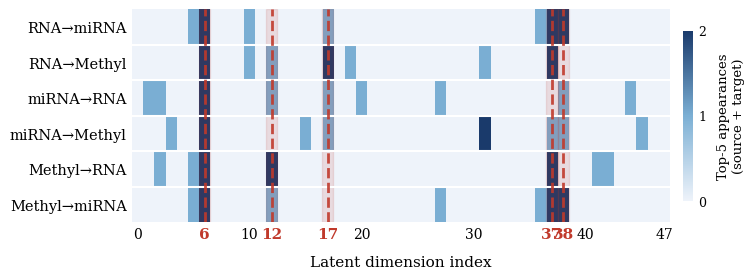

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/panel_A.pdf


In [162]:
plot_jacobian_panel(jacobians_mean, hub_dims=HUB_DIMS)

In [75]:
# ── Feature name setup ────────────────────────────────────────────────────────
feature_names = {
    "rna":    [f"gene_{i}" for i in range(N_RNA)],
    "mirna":  [f"mirna_{i}" for i in range(N_MIRNA)],
    "methyl": [f"cpg_{i}" for i in range(N_METHYL)],
}
if hasattr(TCGABRCADataset, '_rna_feature_names'):
    feature_names["rna"]    = list(TCGABRCADataset._rna_feature_names)
if hasattr(TCGABRCADataset, '_mirna_feature_names'):
    feature_names["mirna"]  = list(TCGABRCADataset._mirna_feature_names)
if hasattr(TCGABRCADataset, '_methyl_feature_names'):
    feature_names["methyl"] = list(TCGABRCADataset._methyl_feature_names)

# ── RNA: resolve ALL Ensembl IDs in the dataset to gene symbols ───────────────
# Query the full feature list once — cheaper than repeated partial lookups
import mygene
mg = mygene.MyGeneInfo()

all_ensembl_raw  = feature_names["rna"]                        # e.g. "ENSG00000141510.7"
all_ensembl_clean = [e.split(".")[0] for e in all_ensembl_raw] # strip version suffix

# Batch query — mygene handles chunking internally
results = mg.querymany(
    all_ensembl_clean,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    verbose=False,
    returnall=False,
)

ENSEMBL_TO_SYMBOL = {}
for r in results:
    if "symbol" in r and not r.get("notfound", False):
        ENSEMBL_TO_SYMBOL[r["query"]] = r["symbol"]

# Map versioned ID -> symbol for lookup convenience
ENSEMBL_TO_SYMBOL_VERSIONED = {
    raw: ENSEMBL_TO_SYMBOL.get(clean, None)
    for raw, clean in zip(all_ensembl_raw, all_ensembl_clean)
}

n_resolved = sum(v is not None for v in ENSEMBL_TO_SYMBOL_VERSIONED.values())
print(f"RNA: resolved {n_resolved} / {len(all_ensembl_raw)} Ensembl IDs to symbols")

# ── Methylation: resolve ALL probes in the dataset via HM450 manifest ─────────
manifest = pd.read_csv(
    "/g/data/yr31/rn8079/database/ucsc_xena/humanmethylation450_15017482_v1-2.csv",
    skiprows=7, index_col=0, low_memory=False
)

PROBE_TO_GENE = {}
for pid in feature_names["methyl"]:
    if pid in manifest.index:
        gene = manifest.loc[pid, "UCSC_RefGene_Name"]
        if pd.notna(gene) and str(gene).strip() != "":
            # Take first gene if semicolon-delimited
            PROBE_TO_GENE[pid] = gene.split(";")[0].strip()
        else:
            PROBE_TO_GENE[pid] = None   # intergenic — explicit None, not missing
    else:
        PROBE_TO_GENE[pid] = None       # probe not in manifest

n_resolved = sum(v is not None for v in PROBE_TO_GENE.values())
print(f"Methylation: resolved {n_resolved} / {len(PROBE_TO_GENE)} probes to genes")

# ── miRNA: names are already human-readable in the dataset ───────────────────
# No lookup needed — feature_names["mirna"] already contains e.g. "hsa-mir-21"
# Strip "hsa-" prefix for display only, keep originals for lookup
def clean_mirna_name(name):
    return name.replace("hsa-", "")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


RNA: resolved 4649 / 4652 Ensembl IDs to symbols
Methylation: resolved 24607 / 37482 probes to genes


In [83]:
# ─────────────────────────────────────────────────────────────────────────────
# Integrated Gradients — Hub Latent Dimension Attribution
# ─────────────────────────────────────────────────────────────────────────────
# For each modality encoder, computes IG attributions targeting the
# hub latent dimensions identified from the Jacobian analysis (12, 37, 5).
# Baseline = zeros (appropriate for z-scored inputs).
# Output = which input features most activate each hub dimension.
# ─────────────────────────────────────────────────────────────────────────────

def compute_hub_ig(fold_results, cfg, hub_dims=HUB_DIMS, fold_idx=0, n_steps=50):
    """
    For each modality encoder, compute IG attributions for each hub dim.

    Returns:
        attrs: dict with keys 'rna', 'mirna', 'methyl'
                each value is array (n_hub_dims, n_features) — mean attribution
                across all observed validation samples
    """
    fr = fold_results[fold_idx]

    # ── Reproduce val split ───────────────────────────────────────────────────
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    for i, (_, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        if i == fr["fold"] - 1:
            break

    val_dataset = TCGABRCADataset(
        indices=val_idx,
        rna_scaler=fr["scalers"]["rna"],
        mirna_scaler=fr["scalers"]["mirna"],
        methyl_scaler=fr["scalers"]["methyl"],
        dropout_probs=None,
    )
    val_loader = DataLoader(val_dataset, batch_size=32,
                            shuffle=False, collate_fn=collate_fn, num_workers=0)

    # ── Load model ────────────────────────────────────────────────────────────
    model = BioPoE(latent_dim=N_LATENT).to(device)
    model.load_state_dict(
        {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
    model.eval()

    # ── Wrapper functions: input -> hub dim activation ────────────────────────
    # IG requires a function f: input_tensor -> scalar_output
    # We target mu (not z) to avoid reparameterisation noise

    def make_encoder_hub_fn(encoder, hub_dim):
        """Returns function: x -> mu[hub_dim] for use with IG."""
        def fn(x):
            mu, _ = encoder(x)
            return mu[:, hub_dim].unsqueeze(1)   # (batch, 1)
        return fn

    encoders = {
        "rna":    model.rna_enc,
        "mirna":  model.mirna_enc,
        "methyl": model.methyl_enc,
    }
    modality_keys = ["rna", "mirna", "methyl"]
    mask_indices  = {"rna": 0, "mirna": 1, "methyl": 2}

    # Storage: for each modality, list of attribution arrays per hub dim
    # attrs_accum[modality][hub_dim] = list of (n_samples, n_features) arrays
    attrs_accum = {
        mod: {d: [] for d in hub_dims}
        for mod in modality_keys
    }

    for batch in val_loader:
        batch = move_batch_to_device(batch, device)
        mask  = batch["mask"]

        for mod in modality_keys:
            m_idx = mask_indices[mod]
            obs   = mask[:, m_idx]
            if not obs.any() or batch[mod] is None:
                continue

            x_obs = batch[mod][obs].detach()          # (n_obs, n_features)
            baseline = torch.zeros_like(x_obs)        # zeros baseline (z-scored)

            encoder = encoders[mod]

            for hub_dim in hub_dims:
                fn = make_encoder_hub_fn(encoder, hub_dim)
                ig = IntegratedGradients(fn)

                # IG attribution: shape (n_obs, n_features)
                attr = ig.attribute(
                    x_obs,
                    baselines=baseline,
                    n_steps=n_steps,
                    return_convergence_delta=False,
                )
                attrs_accum[mod][hub_dim].append(attr.detach().cpu().numpy())

    # ── Aggregate: mean attribution per hub dim per modality ──────────────────
    attrs = {}
    for mod in modality_keys:
        hub_attrs = []
        for hub_dim in hub_dims:
            chunks = attrs_accum[mod][hub_dim]
            if not chunks:
                hub_attrs.append(None)
                continue
            all_attrs = np.concatenate(chunks, axis=0)   # (n_total, n_features)
            mean_attr  = all_attrs.mean(axis=0)          # (n_features,)
            hub_attrs.append(mean_attr)
        attrs[mod] = hub_attrs   # list of (n_features,) arrays, one per hub dim

    return attrs


def print_top_features(attrs, hub_dims=HUB_DIMS, top_k=20):
    """
    Print top-k features by mean absolute IG attribution for each
    modality × hub dimension combination.
    """
    modality_keys = ["rna", "mirna", "methyl"]

    # Feature name arrays — pull from dataset class
    # If you have feature names stored, use them; otherwise use indices
    feature_names = {
        "rna":    [f"gene_{i}" for i in range(N_RNA)],
        "mirna":  [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": [f"cpg_{i}" for i in range(N_METHYL)],
    }

    # If you have actual gene names stored on the dataset class, use those:
    if hasattr(TCGABRCADataset, '_rna_feature_names'):
        feature_names["rna"]    = TCGABRCADataset._rna_feature_names
    if hasattr(TCGABRCADataset, '_mirna_feature_names'):
        feature_names["mirna"]  = TCGABRCADataset._mirna_feature_names
    if hasattr(TCGABRCADataset, '_methyl_feature_names'):
        feature_names["methyl"] = TCGABRCADataset._methyl_feature_names

    print("=" * 70)
    print(f"TOP-{top_k} FEATURES BY IG ATTRIBUTION — HUB DIMENSIONS {hub_dims}")
    print("Baseline = zeros (z-scored inputs)")
    print("=" * 70)

    for mod in modality_keys:
        for i, hub_dim in enumerate(hub_dims):
            attr = attrs[mod][i]
            if attr is None:
                continue
            abs_attr  = np.abs(attr)
            top_idx   = np.argsort(abs_attr)[::-1][:top_k]
            top_names = [feature_names[mod][j] for j in top_idx]
            top_vals  = abs_attr[top_idx]

            print(f"\n{mod.upper()} → Hub dim {hub_dim}")
            print(f"  {'Feature':<25s}  {'|IG attr|':>10s}")
            print(f"  {'-'*37}")
            for name, val in zip(top_names, top_vals):
                print(f"  {str(name):<25s}  {val:>10.4f}")

def compute_hub_ig_all_folds(fold_results, cfg, hub_dims=HUB_DIMS,
                              n_steps=50, top_k=50, min_folds=3):
    """
    Runs IG attribution across all folds, then applies majority vote
    per modality per hub dim to identify stable features.

    Returns:
        voted_attrs  : dict mod -> list of (n_features,) mean attr arrays
                       (averaged over folds where feature passed vote)
        fold_top_sets: dict (mod, hub_dim) -> list of sets of top feature names per fold
    """
    from collections import Counter

    feature_names = {
        "rna":    list(TCGABRCADataset._rna_feature_names)
                  if hasattr(TCGABRCADataset, '_rna_feature_names')
                  else [f"gene_{i}" for i in range(N_RNA)],
        "mirna":  list(TCGABRCADataset._mirna_feature_names)
                  if hasattr(TCGABRCADataset, '_mirna_feature_names')
                  else [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": list(TCGABRCADataset._methyl_feature_names)
                  if hasattr(TCGABRCADataset, '_methyl_feature_names')
                  else [f"cpg_{i}" for i in range(N_METHYL)],
    }

    modality_keys = ["rna", "mirna", "methyl"]
    n_folds = len(fold_results)

    top_k_per_mod = {"rna": 50, "mirna": 50, "methyl": 200}
    
    # Accumulate per-fold attribution arrays and top-feature sets
    # fold_attrs[(mod, hub_dim_idx)] = list of (n_features,) arrays, one per fold
    fold_attrs    = {(mod, i): [] for mod in modality_keys
                     for i in range(len(hub_dims))}
    fold_top_sets = {(mod, hub_dims[i]): [] for mod in modality_keys
                     for i in range(len(hub_dims))}

    for fold_idx in range(n_folds):
        print(f"  Computing IG — fold {fold_idx + 1}/{n_folds}")
        attrs = compute_hub_ig(fold_results, cfg,
                               hub_dims=hub_dims,
                               fold_idx=fold_idx,
                               n_steps=n_steps)
        for mod in modality_keys:
            for i, hub_dim in enumerate(hub_dims):
                arr = attrs[mod][i]
                if arr is None:
                    continue
                fold_attrs[(mod, i)].append(arr)
                # Record top-k feature names for this fold
                top_idx = np.argsort(np.abs(arr))[::-1][:top_k_per_mod[mod]]
                top_names = set(feature_names[mod][j] for j in top_idx)
                fold_top_sets[(mod, hub_dim)].append(top_names)

    # Majority vote: features appearing in ≥ min_folds folds
    voted_features = {}  # (mod, hub_dim) -> list of feature names passing vote
    for mod in modality_keys:
        for hub_dim in hub_dims:
            sets = fold_top_sets[(mod, hub_dim)]
            if not sets:
                voted_features[(mod, hub_dim)] = []
                continue
            counts = Counter()
            for s in sets:
                for feat in s:
                    counts[feat] += 1
            passing = [f for f, cnt in counts.items() if cnt >= min_folds]
            # Sort passing features by mean |attribution| across folds that had them
            i = hub_dims.index(hub_dim)
            arrs = fold_attrs[(mod, i)]
            if arrs:
                mean_arr = np.stack(arrs).mean(axis=0)
                feat_idx = {name: j for j, name in enumerate(feature_names[mod])}
                passing.sort(key=lambda f: -np.abs(mean_arr[feat_idx[f]])
                             if f in feat_idx else 0)
            voted_features[(mod, hub_dim)] = passing

    # Build voted_attrs: mean attribution array across folds, for plotting
    voted_attrs = {}
    for mod in modality_keys:
        hub_arrs = []
        for i, hub_dim in enumerate(hub_dims):
            arrs = fold_attrs[(mod, i)]
            if arrs:
                hub_arrs.append(np.stack(arrs).mean(axis=0))
            else:
                hub_arrs.append(None)
        voted_attrs[mod] = hub_arrs

    return voted_attrs, voted_features, fold_top_sets

    
def plot_hub_attributions_paper(
        attrs,
        voted_features,
        hub_dims=HUB_DIMS,
        hub_labels=None,       # dict hub_dim -> label string, filled after DR
        hub_colors=None,       # dict hub_dim -> hex colour, optional override
        top_k=15,
        save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/ig_attributions.svg"):
    """
    Publication IG attribution figure.
    - Rows: miRNA, Methylation only (RNA excluded — diffuse signal, no stable features)
    - Columns: one per hub dim
    - Stable features (majority-voted) are highlighted with a border
    - hub_labels: pass in after ChatGPT DR e.g. {6: "Stromal/ECM", 12: "Endocrine resistance", ...}
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # ── Modalities to plot — RNA excluded deliberately ────────────────────────
    modality_keys = ["rna", "mirna", "methyl"]
    modality_labels = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}

    # ── Colours: one per hub dim ───────────────────────────────────────────────
    default_colors = ["#534AB7", "#185FA5", "#C0392B", "#3B6D11"]
    if hub_colors is None:
        hub_colors = {hd: default_colors[i % len(default_colors)]
                      for i, hd in enumerate(hub_dims)}

    # ── Labels: placeholder until DR returns ──────────────────────────────────
    if hub_labels is None:
        hub_labels = {hd: f"Hub dim {hd}" for hd in hub_dims}
    else:
        # Ensure all hub dims have a label
        for hd in hub_dims:
            if hd not in hub_labels:
                hub_labels[hd] = f"Hub dim {hd}"

    # ── Feature name lookup ───────────────────────────────────────────────────
    feature_names = {
        "mirna":  list(TCGABRCADataset._mirna_feature_names)
                  if hasattr(TCGABRCADataset, '_mirna_feature_names')
                  else [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": list(TCGABRCADataset._methyl_feature_names)
                  if hasattr(TCGABRCADataset, '_methyl_feature_names')
                  else [f"cpg_{i}" for i in range(N_METHYL)],
        "rna": list(TCGABRCADataset._rna_feature_names) 
                   if hasattr(TCGABRCADataset, '_rna_feature_names') 
                   else [f"gene_{i}" for i in range(N_RNA)],
    }

    def resolve_name(mod, raw):
        if mod == "rna":
            clean = raw.split(".")[0]
            return ENSEMBL_TO_SYMBOL_VERSIONED.get(raw) \
                   or ENSEMBL_TO_SYMBOL.get(clean) \
                   or clean
        elif mod == "mirna":
            return raw.replace("hsa-", "")
        elif mod == "methyl":
            gene = PROBE_TO_GENE.get(raw)
            return f"{gene}\n({raw})" if gene else f"intergenic\n({raw})"
        return raw

    # ── Figure layout ─────────────────────────────────────────────────────────
    n_rows = len(modality_keys)
    n_cols = len(hub_dims)
    row_heights = [3.5, 4.0, 5.5]   # rna, mirna, methyl
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, sum(row_heights)),
        gridspec_kw={"height_ratios": row_heights},
        constrained_layout=True,
    )
    # Ensure axes is always 2D
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, mod in enumerate(modality_keys):
        # mod_col_idx maps hub_dim -> column index in attrs[mod]
        for col, hub_dim in enumerate(hub_dims):
            ax    = axes[row, col]
            color = hub_colors[hub_dim]

            # attrs[mod] is a list indexed by position in hub_dims
            attr = attrs[mod][col]
            if attr is None:
                ax.set_visible(False)
                continue

            # ── Get top_k features ───────────────
            abs_attr  = np.abs(attr)
            feat_list = feature_names[mod]
            
            # ── Build display list: stable features first, then top mean attr ──────
            stable_set    = set(voted_features.get((mod, hub_dim), []))
            
            # Indices of stable features, sorted by mean attribution descending
            stable_idx = [j for j, name in enumerate(feat_list)
                          if name in stable_set]
            stable_idx.sort(key=lambda j: -abs_attr[j])
            
            # Indices of non-stable top-k by mean attribution
            all_top_idx   = np.argsort(abs_attr)[::-1]
            nonstable_idx = [j for j in all_top_idx
                             if feat_list[j] not in stable_set]
            
            # Combine: stable first, then fill remaining slots with non-stable
            n_stable   = len(stable_idx)
            n_fill     = max(0, top_k - n_stable)
            display_idx = stable_idx + nonstable_idx[:n_fill]
            
            # Total bars shown may exceed top_k if there are many stable features
            n_bars    = len(display_idx)
            top_vals  = abs_attr[display_idx][::-1]           # ascending for barh
            raw_names_asc = [feat_list[j] for j in display_idx][::-1]
            display_names = [resolve_name(mod, n) for n in raw_names_asc]

            # ── Plot bars ─────────────────────────────────────────────────────
            bars = ax.barh(
                range(n_bars), top_vals,
                color=color, alpha=0.65, height=0.72,
                edgecolor="none",
            )
            
            for i, (bar, raw) in enumerate(zip(bars, raw_names_asc)):
                if raw in stable_set:
                    bar.set_edgecolor(color)
                    bar.set_linewidth(1.8)
                    bar.set_alpha(0.92)
                else:
                    bar.set_alpha(0.45 if i % 2 == 0 else 0.60)

            # ── Y-axis labels — bold for stable features ──────────────────────
            ax.set_yticks(range(top_k))
            ax.set_yticklabels(display_names, fontsize=7.5)
            for i, (tick, raw) in enumerate(
                    zip(ax.get_yticklabels(), raw_names_asc)):
                if raw in stable_set:
                    tick.set_fontweight("bold")
                    tick.set_color(color)

            # ── Axes formatting ───────────────────────────────────────────────
            ax.tick_params(axis="x", labelsize=7.5)
            ax.set_xlabel("|IG attribution|", fontsize=8)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.grid(axis="x", alpha=0.2, linestyle="--")
            ax.tick_params(axis="y", length=0)

            # ── Column header on top row only ─────────────────────────────────
            if row == 0:
                ax.set_title(
                    hub_labels[hub_dim],
                    fontsize=9, fontweight="bold",
                    color=color, pad=10,
                )

            # ── Row label on leftmost column only ─────────────────────────────
            if col == 0:
                ax.set_ylabel(modality_labels[mod], fontsize=10,
                              fontweight="bold", labelpad=10)

    # ── Legend for stable vs non-stable ───────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor="#555555", alpha=0.90,
                       linewidth=1.8, edgecolor="#555555",
                       label=f"Stable feature (≥3/5 folds)"),
        mpatches.Patch(facecolor="#555555", alpha=0.45,
                       edgecolor="none",
                       label="Top-15 by mean attribution"),
    ]
    fig.legend(handles=legend_elements, fontsize=8,
               loc="lower center", ncol=2,
               framealpha=0.9, edgecolor="#CCCCCC",
               bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(
        "Integrated Gradients: stable features activating cross-modal hub dimensions\n"
        "(bold labels and solid borders = majority-vote stable across ≥3/5 folds)",
        fontsize=10, fontweight="bold",
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

In [84]:
# Run IG across all folds with majority vote
print("Running IG analysis across all folds...")
hub_attrs_voted, voted_features, fold_top_sets = compute_hub_ig_all_folds(
    fold_results_survival, CONFIG,
    hub_dims=HUB_DIMS, n_steps=50, top_k=50, min_folds=3
)

# Print majority-voted features
print("\n--- Majority-vote stable features (≥3/5 folds) ---")
for mod in ["rna", "mirna", "methyl"]:
    for hub_dim in HUB_DIMS:
        feats = voted_features[(mod, hub_dim)]
        print(f"\n{mod.upper()} → Hub dim {hub_dim}  ({len(feats)} stable features)")
        for f in feats[:20]:
            print(f"  {f}")


Running IG analysis across all folds...
  Computing IG — fold 1/5
  Computing IG — fold 2/5
  Computing IG — fold 3/5
  Computing IG — fold 4/5
  Computing IG — fold 5/5

--- Majority-vote stable features (≥3/5 folds) ---

RNA → Hub dim 6  (1 stable features)
  ENSG00000188549

RNA → Hub dim 12  (1 stable features)
  ENSG00000248485

RNA → Hub dim 17  (4 stable features)
  ENSG00000127252
  ENSG00000188549
  ENSG00000089177
  ENSG00000131019

RNA → Hub dim 37  (2 stable features)
  ENSG00000188549
  ENSG00000187840

MIRNA → Hub dim 6  (4 stable features)
  hsa-mir-24-1
  hsa-mir-769
  hsa-mir-509-1
  hsa-let-7i

MIRNA → Hub dim 12  (14 stable features)
  hsa-mir-1307
  hsa-let-7g
  hsa-mir-3605
  hsa-mir-1306
  hsa-mir-760
  hsa-mir-769
  hsa-mir-3170
  hsa-mir-21
  hsa-mir-501
  hsa-mir-421
  hsa-mir-221
  hsa-mir-1266
  hsa-mir-410
  hsa-mir-1292

MIRNA → Hub dim 17  (8 stable features)
  hsa-mir-197
  hsa-mir-221
  hsa-mir-758
  hsa-mir-3605
  hsa-mir-769
  hsa-mir-24-2
  hsa-mir-12

In [85]:
# ── Resolve stable features to human-readable names ───────────────────────────
print("=" * 70)
print("STABLE FEATURES (≥3/5 folds) — resolved to gene symbols")
print("=" * 70)

for hub_dim in HUB_DIMS:
    print(f"\n{'─'*70}")
    print(f"HUB DIM {hub_dim}")
    print(f"{'─'*70}")

    for mod in ["rna", "mirna", "methyl"]:
        feats = voted_features.get((mod, hub_dim), [])
        if not feats:
            print(f"\n  {mod.upper():8s}  — no stable features")
            continue

        print(f"\n  {mod.upper()} ({len(feats)} stable features)")
        print(f"  {'Raw ID':<25s}  {'Symbol / Name':<25s}  {'Folds'}")
        print(f"  {'-'*65}")

        for feat in feats:
            # ── Resolve display name ──────────────────────────────────────────
            if mod == "rna":
                clean_id = feat.split(".")[0]
                symbol   = ENSEMBL_TO_SYMBOL.get(clean_id) \
                           or ENSEMBL_TO_SYMBOL_VERSIONED.get(feat) \
                           or "unresolved"
                display  = symbol

            elif mod == "mirna":
                display = feat.replace("hsa-", "")   # already readable

            elif mod == "methyl":
                gene    = PROBE_TO_GENE.get(feat)
                display = gene if gene else "intergenic"

            # ── Fold count from fold_top_sets ─────────────────────────────────
            sets        = fold_top_sets.get((mod, hub_dim), [])
            fold_count  = sum(1 for s in sets if feat in s)
            fold_str    = f"{fold_count}/5 folds"

            print(f"  {feat:<25s}  {display:<25s}  {fold_str}")

STABLE FEATURES (≥3/5 folds) — resolved to gene symbols

──────────────────────────────────────────────────────────────────────
HUB DIM 6
──────────────────────────────────────────────────────────────────────

  RNA (1 stable features)
  Raw ID                     Symbol / Name              Folds
  -----------------------------------------------------------------
  ENSG00000188549            CCDC9B                     3/5 folds

  MIRNA (4 stable features)
  Raw ID                     Symbol / Name              Folds
  -----------------------------------------------------------------
  hsa-mir-24-1               mir-24-1                   3/5 folds
  hsa-mir-769                mir-769                    4/5 folds
  hsa-mir-509-1              mir-509-1                  3/5 folds
  hsa-let-7i                 let-7i                     3/5 folds

  METHYL (4 stable features)
  Raw ID                     Symbol / Name              Folds
  ---------------------------------------------------

In [176]:
def plot_ig_panel(attrs, voted_features, feature_names, hub_dims,
                  hub_colors, hub_labels, resolve_name,
                  save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/panel_B.pdf"):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    modality_keys   = ["rna", "mirna", "methyl"]
    modality_labels = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}
    row_heights     = [3.8, 4.4, 6.0]
    top_k           = 15

    n_rows = len(modality_keys)
    n_cols = len(hub_dims)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.2 * n_cols, sum(row_heights)),
        gridspec_kw={"height_ratios": row_heights},
        constrained_layout=True,
    )
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    fig.patch.set_facecolor("white")

    for row, mod in enumerate(modality_keys):
        for col, hub_dim in enumerate(hub_dims):
            ax    = axes[row, col]
            color = hub_colors[hub_dim]
            attr  = attrs[mod][col]

            if attr is None:
                ax.set_visible(False)
                continue

            abs_attr   = np.abs(attr)
            feat_list  = feature_names[mod]
            stable_set = set(voted_features.get((mod, hub_dim), []))

            # Build display list: stable first, then top non-stable
            stable_idx    = sorted(
                [j for j, n in enumerate(feat_list) if n in stable_set],
                key=lambda j: -abs_attr[j]
            )
            all_top_idx   = np.argsort(abs_attr)[::-1]
            nonstable_idx = [j for j in all_top_idx
                             if feat_list[j] not in stable_set]
            n_fill        = max(0, top_k - len(stable_idx))
            display_idx   = stable_idx + nonstable_idx[:n_fill]

            n_bars        = len(display_idx)
            top_vals      = abs_attr[display_idx][::-1]
            raw_asc       = [feat_list[j] for j in display_idx][::-1]
            disp_names    = [resolve_name(mod, n) for n in raw_asc]

            # ── Bars ──────────────────────────────────────────────────────────
            bars = ax.barh(range(n_bars), top_vals,
                           color=color, alpha=0.65,
                           height=0.74, edgecolor="none")

            for i, (bar, raw) in enumerate(zip(bars, raw_asc)):
                if raw in stable_set:
                    bar.set_edgecolor(color)
                    bar.set_linewidth(2.0)
                    bar.set_alpha(0.92)
                else:
                    bar.set_alpha(0.42 if i % 2 == 0 else 0.58)

            # ── Y-axis labels ─────────────────────────────────────────────────
            ax.set_yticks(range(n_bars))
            ax.set_yticklabels(disp_names, fontsize=9.5)
            for tick, raw in zip(ax.get_yticklabels(), raw_asc):
                if raw in stable_set:
                    tick.set_fontweight("bold")
                    tick.set_color(color)
                    tick.set_fontsize(10)

            # ── Axes formatting ───────────────────────────────────────────────
            ax.tick_params(axis="x", labelsize=9.5)
            ax.set_xlabel("|IG attribution|", fontsize=10, labelpad=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.grid(axis="x", alpha=0.18, linestyle="--", linewidth=0.7)
            ax.tick_params(axis="y", length=0)
            ax.set_facecolor("white")

            # ── Column header — top row only ──────────────────────────────────
            if row == 0:
                ax.set_title(hub_labels[hub_dim],
                             fontsize=12, fontweight="bold",
                             color=color, pad=14)

            # ── Row label — leftmost column only ──────────────────────────────
            if col == 0:
                ax.set_ylabel(modality_labels[mod],
                              fontsize=12, fontweight="bold",
                              labelpad=12)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor="#555555", alpha=0.92,
                       edgecolor="#555555", linewidth=2.0,
                       label="Stable feature (≥3/5 folds)"),
        mpatches.Patch(facecolor="#555555", alpha=0.42,
                       edgecolor="none",
                       label="Top-15 by mean attribution"),
    ]
    fig.legend(handles=legend_elements, fontsize=11,
               loc="lower center", ncol=2,
               framealpha=0.0, edgecolor="none",
               bbox_to_anchor=(0.5, -0.025))

    # ── Save ──────────────────────────────────────────────────────────────────
    for fmt in [save_path, save_path.replace(".pdf", ".svg")]:
        plt.savefig(fmt, dpi=300, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved: {save_path}")

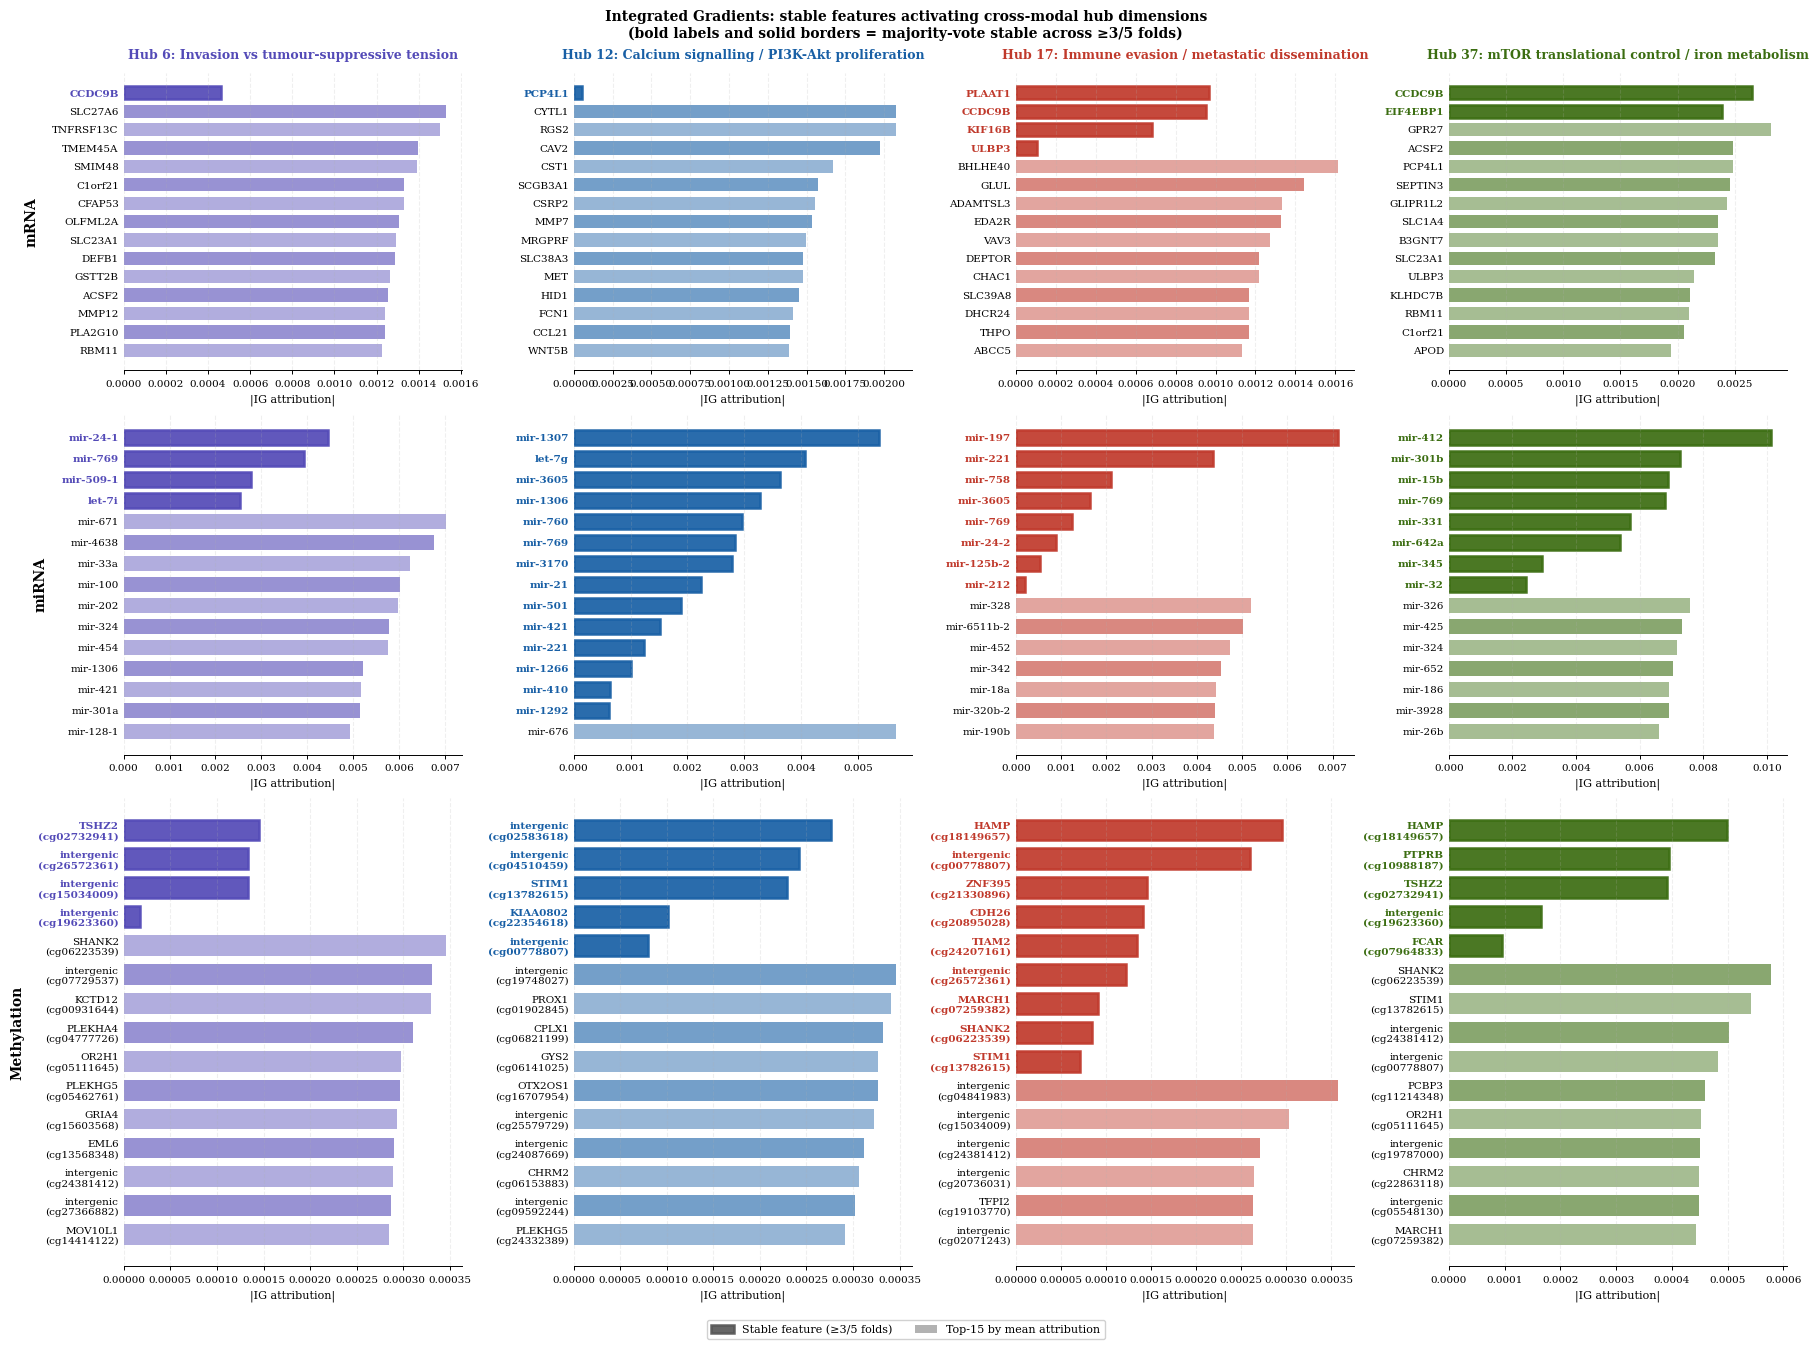

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/ig_attributions.svg


In [177]:
plot_hub_attributions_paper(
    attrs=hub_attrs_voted,
    voted_features=voted_features,
    hub_dims=[6, 12, 17, 37],   # exclude 38 from main figure
    hub_labels={
        6:  "Hub 6: Invasion vs tumour-suppressive tension",
        12: "Hub 12: Calcium signalling / PI3K-Akt proliferation",
        17: "Hub 17: Immune evasion / metastatic dissemination",
        37: "Hub 37: mTOR translational control / iron metabolism",
    },
    top_k=15,
)

In [80]:
def compute_cox_direct_ig(fold_results, cfg, n_steps=50, top_k=50, min_folds=3):
    """
    Direct IG attribution to Cox head output, bypassing Jacobian hub selection.
    Targets the raw risk score f_Cox(z_poe) rather than individual hub dim activations.
    Used to compare feature recovery against the Jacobian-guided pipeline.
    
    Returns:
        voted_features_cox: dict mod -> list of majority-vote stable feature names
        fold_top_sets_cox:  dict mod -> list of per-fold top feature name sets
    """
    from collections import Counter
    from captum.attr import IntegratedGradients

    feature_names = {
        "rna":    list(TCGABRCADataset._rna_feature_names)
                  if hasattr(TCGABRCADataset, '_rna_feature_names')
                  else [f"gene_{i}" for i in range(N_RNA)],
        "mirna":  list(TCGABRCADataset._mirna_feature_names)
                  if hasattr(TCGABRCADataset, '_mirna_feature_names')
                  else [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": list(TCGABRCADataset._methyl_feature_names)
                  if hasattr(TCGABRCADataset, '_methyl_feature_names')
                  else [f"cpg_{i}" for i in range(N_METHYL)],
    }
    modality_keys = ["rna", "mirna", "methyl"]
    mask_indices  = {"rna": 0, "mirna": 1, "methyl": 2}
    top_k_per_mod = {"rna": 50, "mirna": 50, "methyl": 200}
    n_folds = len(fold_results)

    fold_attrs    = {mod: [] for mod in modality_keys}
    fold_top_sets = {mod: [] for mod in modality_keys}

    for fold_idx in range(n_folds):
        print(f"  Computing Cox-direct IG — fold {fold_idx + 1}/{n_folds}")
        fr = fold_results[fold_idx]

        # ── Reproduce val split ───────────────────────────────────────────────
        pfi_event_all = TCGABRCADataset._pfi_event.numpy()
        strat_labels  = np.clip(pfi_event_all, 0, 1)
        skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                              random_state=cfg["seed"])
        for i, (_, val_idx) in enumerate(
                skf.split(np.arange(len(strat_labels)), strat_labels)):
            if i == fr["fold"] - 1:
                break

        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=fr["scalers"]["rna"],
            mirna_scaler=fr["scalers"]["mirna"],
            methyl_scaler=fr["scalers"]["methyl"],
            dropout_probs=None,
        )
        val_loader = DataLoader(val_dataset, batch_size=32,
                                shuffle=False, collate_fn=collate_fn, num_workers=0)

        # ── Load model and survival head ──────────────────────────────────────
        model = BioPoE(latent_dim=N_LATENT).to(device)
        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        model.eval()

        translator = CrossModalTranslator(
            N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        translator.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
        translator.eval()

        survival_head = SurvivalHead(N_LATENT).to(device)
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})
        survival_head.eval()

        encoders = {
            "rna":    model.rna_enc,
            "mirna":  model.mirna_enc,
            "methyl": model.methyl_enc,
        }

        # ── Wrapper: input -> Cox risk score via full forward pass ────────────
        # We fix the other modalities at their observed values and vary one
        # modality at a time, attributing risk score changes to that modality.
        # This is the standard single-modality IG approach for multimodal models.
        def make_cox_fn(encoder, mod, batch_other):
            m_idx = mask_indices[mod]
        
            def fn(x):
                actual_batch_size = x.shape[0]
                mu_m, lv_m = encoder(x)
        
                # Expand mask and context tensors to match Captum's expanded batch size
                orig_size = batch_other["mask"].shape[0]
                repeat_factor = actual_batch_size // orig_size
        
                mask_exp = batch_other["mask"].repeat(repeat_factor, 1)
        
                mus_local     = [m.repeat(repeat_factor, 1) for m in batch_other["mus"]]
                logvars_local = [l.repeat(repeat_factor, 1) for l in batch_other["logvars"]]
        
                mus_local[m_idx]     = mu_m
                logvars_local[m_idx] = lv_m
        
                precision_sum = torch.ones(actual_batch_size, N_LATENT, device=x.device)
                weighted_mu   = torch.zeros(actual_batch_size, N_LATENT, device=x.device)
        
                for i in range(3):
                    obs = mask_exp[:, i]
                    if not obs.any():
                        continue
                    prec = torch.exp(-logvars_local[i])
                    precision_sum[obs] += prec[obs]
                    weighted_mu[obs]   += (prec * mus_local[i])[obs]
        
                var_poe = 1.0 / (precision_sum + 1e-8)
                mu_poe  = var_poe * weighted_mu
        
                risk = survival_head(mu_poe)
                return risk
        
            return fn

        # Accumulate attributions per modality across batches
        attrs_accum = {mod: [] for mod in modality_keys}

        for batch in val_loader:
            batch = move_batch_to_device(batch, device)
            mask  = batch["mask"]

            # Get all modality encodings for this batch to use as fixed context
            with torch.no_grad():
                mus, logvars = [], []
                for mod in modality_keys:
                    m_idx = mask_indices[mod]
                    obs   = mask[:, m_idx]
                    if obs.any() and batch[mod] is not None:
                        mu, lv = encoders[mod](batch[mod])
                    else:
                        mu = torch.zeros(mask.shape[0], N_LATENT, device=device)
                        lv = torch.zeros(mask.shape[0], N_LATENT, device=device)
                    mus.append(mu)
                    logvars.append(lv)

            batch_other = {
                "mus":     mus,
                "logvars": logvars,
                "mask":    mask,
            }

            for mod in modality_keys:
                m_idx = mask_indices[mod]
                obs   = mask[:, m_idx]
                if not obs.any() or batch[mod] is None:
                    continue

                x_obs    = batch[mod][obs].detach()
                baseline = torch.zeros_like(x_obs)

                # Subset batch_other to observed samples only
                batch_other_obs = {
                    "mus":     [m[obs] for m in batch_other["mus"]],
                    "logvars": [l[obs] for l in batch_other["logvars"]],
                    "mask":    batch_other["mask"][obs],
                }

                fn = make_cox_fn(encoders[mod], mod, batch_other_obs)
                ig = IntegratedGradients(fn)

                attr = ig.attribute(
                    x_obs,
                    baselines=baseline,
                    n_steps=n_steps,
                    return_convergence_delta=False,
                )
                attrs_accum[mod].append(attr.detach().cpu().numpy())

        # Mean attribution across all observed val samples for this fold
        for mod in modality_keys:
            chunks = attrs_accum[mod]
            if not chunks:
                fold_attrs[mod].append(None)
                fold_top_sets[mod].append(set())
                continue
            mean_attr = np.concatenate(chunks, axis=0).mean(axis=0)
            fold_attrs[mod].append(mean_attr)
            top_idx  = np.argsort(np.abs(mean_attr))[::-1][:top_k_per_mod[mod]]
            top_names = set(feature_names[mod][j] for j in top_idx)
            fold_top_sets[mod].append(top_names)

    # ── Majority vote across folds ────────────────────────────────────────────
    voted_features_cox = {}
    for mod in modality_keys:
        counts = Counter()
        for s in fold_top_sets[mod]:
            for feat in s:
                counts[feat] += 1
        passing = [f for f, cnt in counts.items() if cnt >= min_folds]
        arrs = [a for a in fold_attrs[mod] if a is not None]
        if arrs:
            mean_arr = np.stack(arrs).mean(axis=0)
            feat_idx = {name: j for j, name in enumerate(feature_names[mod])}
            passing.sort(key=lambda f: -np.abs(mean_arr[feat_idx[f]])
                         if f in feat_idx else 0)
        voted_features_cox[mod] = passing

    return voted_features_cox, fold_top_sets

In [86]:
print("Running Cox-direct IG across all folds...")
voted_features_cox, fold_top_sets_cox = compute_cox_direct_ig(
    fold_results_survival, CONFIG, n_steps=50, top_k=50, min_folds=3
)

# Check whether CCDC9B appears in Cox-direct attribution
for mod in ["rna", "mirna", "methyl"]:
    feats = voted_features_cox[mod]
    ccdc9b_present = any("CCDC9B" in f for f in feats)
    print(f"{mod}: CCDC9B in Cox-direct top features: {ccdc9b_present}")
    
# Compare overlap with Jacobian-guided pipeline
for mod in ["rna", "mirna", "methyl"]:
    cox_set = set(voted_features_cox[mod])
    for hub_dim in HUB_DIMS:
        jac_set = set(voted_features[(mod, hub_dim)])
        overlap = cox_set & jac_set
        print(f"{mod} hub {hub_dim}: {len(overlap)} features shared with Cox-direct, "
              f"{len(jac_set - cox_set)} Jacobian-only, "
              f"{len(cox_set - jac_set)} Cox-only")

Running Cox-direct IG across all folds...
  Computing Cox-direct IG — fold 1/5
  Computing Cox-direct IG — fold 2/5
  Computing Cox-direct IG — fold 3/5
  Computing Cox-direct IG — fold 4/5
  Computing Cox-direct IG — fold 5/5
rna: CCDC9B in Cox-direct top features: False
mirna: CCDC9B in Cox-direct top features: False
methyl: CCDC9B in Cox-direct top features: False
rna hub 6: 1 features shared with Cox-direct, 0 Jacobian-only, 6 Cox-only
rna hub 12: 0 features shared with Cox-direct, 1 Jacobian-only, 7 Cox-only
rna hub 17: 2 features shared with Cox-direct, 2 Jacobian-only, 5 Cox-only
rna hub 37: 1 features shared with Cox-direct, 1 Jacobian-only, 6 Cox-only
mirna hub 6: 2 features shared with Cox-direct, 2 Jacobian-only, 11 Cox-only
mirna hub 12: 3 features shared with Cox-direct, 11 Jacobian-only, 10 Cox-only
mirna hub 17: 2 features shared with Cox-direct, 6 Jacobian-only, 11 Cox-only
mirna hub 37: 1 features shared with Cox-direct, 7 Jacobian-only, 12 Cox-only
methyl hub 6: 1 fea

## Save Results

In [169]:
import pickle

pickle.dump(fold_results_survival, open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_biopoe_canonical.pkl', 'wb'))
pickle.dump(fold_results_phase1,   open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_notrans_canonical.pkl', 'wb'))
pickle.dump(fold_results_vanilla,  open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_vanilla_canonical.pkl', 'wb'))

print("Saved all three fold results.")

Saved all three fold results.


In [18]:
with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_biopoe_canonical.pkl', 'rb') as f:
    fold_results_survival = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_notrans_canonical.pkl', 'rb') as f:
    fold_results_phase1 = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_vanilla_canonical.pkl', 'rb') as f:
    fold_results_vanilla = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mvae_canonical.pkl', 'rb') as f:
    fold_results_mvae = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_clue_canonical.pkl', 'rb') as f:
    fold_results_clue = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mofa_canonical.pkl', 'rb') as f:
    fold_results_mofa = pickle.load(f)

print("Loaded all model fold results.")

## Run survival Curves 

In [178]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np

def plot_kaplan_meier(fold_results, cfg, save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/kaplan_meier.svg"):
    """
    Plot Kaplan-Meier survival curves splitting patients by CrossPoE risk score.
    Uses all validation patients across all 5 folds (no patient seen in training).
    High-risk vs low-risk split at median risk score.
    """
    from sklearn.model_selection import StratifiedKFold

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    pfi_time_all  = TCGABRCADataset._pfi_time.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    all_risk   = []
    all_time   = []
    all_event  = []
    all_val_idx = []

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        # Load model
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(N_LATENT,
                            hidden_dim=cfg["translation_hidden_dim"]).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        translator.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})
        model.eval()
        translator.eval()
        survival_head.eval()

        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=fr["scalers"]["rna"],
            mirna_scaler=fr["scalers"]["mirna"],
            methyl_scaler=fr["scalers"]["methyl"],
            dropout_probs=None,
        )
        val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                shuffle=False, collate_fn=collate_fn, num_workers=0)

        fold_risk = []
        with torch.no_grad():
            for batch in val_loader:
                batch   = move_batch_to_device(batch, device)
                outputs = model(batch, translator=translator,
                                epoch=cfg["n_epochs"],
                                translation_warmup_epochs=cfg["translation_warmup_epochs"])
                risk = survival_head(outputs["z_surv"]).squeeze(-1).cpu().numpy()
                fold_risk.append(risk)

        fold_risk = np.concatenate(fold_risk)
        all_risk.append(fold_risk)
        all_val_idx.append(val_idx)

    # Concatenate all validation patients
    all_risk    = np.concatenate(all_risk)
    all_val_idx = np.concatenate(all_val_idx)

    # Get survival labels for validation patients
    times  = pfi_time_all[all_val_idx]
    events = pfi_event_all[all_val_idx]

    # Filter to valid labels only
    valid  = events >= 0
    risk_v = all_risk[valid]
    time_v = times[valid]
    event_v = events[valid].astype(bool)

    # Split at median risk score
    median_risk = np.median(risk_v)
    high_risk   = risk_v >= median_risk
    low_risk    = ~high_risk

    # Log-rank test
    lr = logrank_test(
        time_v[high_risk],  time_v[low_risk],
        event_v[high_risk], event_v[low_risk],
    )
    p_val = lr.p_value

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    kmf_high = KaplanMeierFitter()
    kmf_low  = KaplanMeierFitter()

    kmf_high.fit(time_v[high_risk],  event_observed=event_v[high_risk],
                 label=f"High risk (n={high_risk.sum()})")
    kmf_low.fit(time_v[low_risk],   event_observed=event_v[low_risk],
                label=f"Low risk (n={low_risk.sum()})")

    kmf_high.plot_survival_function(ax=ax, color="#C62828", linewidth=2.0,
                                     ci_show=True, ci_alpha=0.12)
    kmf_low.plot_survival_function(ax=ax, color="#1565C0", linewidth=2.0,
                                    ci_show=True, ci_alpha=0.12)

    add_at_risk_counts(kmf_high, kmf_low, ax=ax, fontsize=9)

    # P-value annotation
    p_str = f"p = {p_val:.4f}" if p_val >= 0.0001 else "p < 0.0001"
    ax.text(0.97, 0.97, p_str,
            transform=ax.transAxes,
            ha="right", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.9))

    ax.set_xlabel("Time (days)", fontsize=12)
    ax.set_ylabel("PFI Probability", fontsize=12)
    ax.set_title("CrossPoE Risk Stratification — TCGA-BRCA PFI\n"
                 "(Validation patients across all 5 folds)",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)

    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=11, loc="lower left")
    plt.subplots_adjust(bottom=0.2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    print(f"Log-rank test: {p_str}")
    print(f"High-risk events: {event_v[high_risk].sum()}/{high_risk.sum()}")
    print(f"Low-risk events:  {event_v[low_risk].sum()}/{low_risk.sum()}")

    return {
        "risk": risk_v, "time": time_v, "event": event_v,
        "high_risk_mask": high_risk, "p_value": p_val,
    }

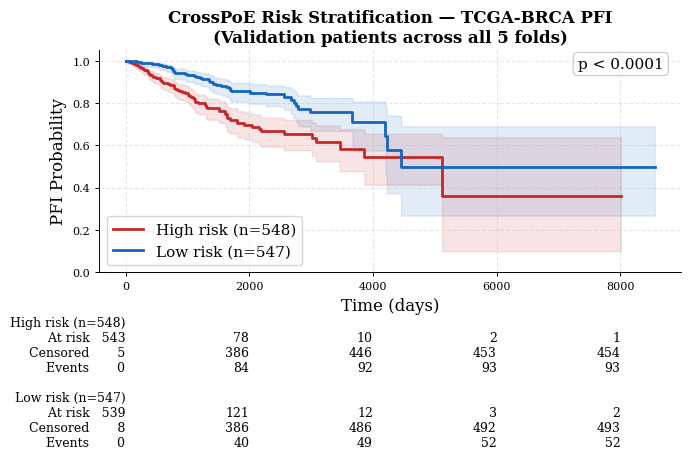

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/kaplan_meier.svg
Log-rank test: p < 0.0001
High-risk events: 93/548
Low-risk events:  52/547


In [179]:
km_results = plot_kaplan_meier(fold_results_survival, CONFIG)

In [183]:
# ── Pre-paper validation: shared setup ───────────────────────────────────────
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

from lifelines import CoxPHFitter
import pandas as pd

def run_univariate_cox(values, times, events, feature_name):
    df = pd.DataFrame({
        "value":  values,
        "time":   times,
        "event":  events,
    })
    df = df[df["time"] > 0].dropna()
    
    cph = CoxPHFitter()
    cph.fit(df, duration_col="time", event_col="event")
    
    summary = cph.summary
    hr      = float(np.exp(summary["coef"].values[0]))
    hr_lo   = float(np.exp(summary["coef lower 95%"].values[0]))
    hr_hi   = float(np.exp(summary["coef upper 95%"].values[0]))
    pval    = float(summary["p"].values[0])
    c_index = float(cph.concordance_index_)

    return {
        "feature": feature_name,
        "hr":      hr,
        "hr_lo":   hr_lo,
        "hr_hi":   hr_hi,
        "pval":    pval,
        "c_index": c_index,
    }

In [184]:
rna_names    = list(TCGABRCADataset._rna_feature_names)
mirna_names  = list(TCGABRCADataset._mirna_feature_names)
methyl_names = list(TCGABRCADataset._methyl_feature_names)
    
print("=" * 60)
print("UNIVARIATE COX — HUB ANCHOR FEATURES (new canonical)")
print("=" * 60)

results_surv = []
methyl_obs = TCGABRCADataset._methyl_mask
rna_obs    = TCGABRCADataset._rna_mask
mirna_obs  = TCGABRCADataset._mirna_mask

# ── CCDC9B — hubs 6, 17, 37 ──────────────────────────────────────────────────
ccdc9b_candidates = [
    (i, n) for i, n in enumerate(rna_names)
    if ENSEMBL_TO_SYMBOL.get(n.split(".")[0]) == "CCDC9B"
]
if ccdc9b_candidates:
    idx  = ccdc9b_candidates[0][0]
    expr = TCGABRCADataset._rna_data[:, idx].copy()
    expr[~rna_obs] = np.nanmean(expr[rna_obs])
    results_surv.append(
        run_univariate_cox(expr, pfi_time_np, pfi_event_np,
                           "CCDC9B (RNA) — hubs 6, 17, 37"))

# ── hsa-mir-769 — hubs 6, 12, 17, 37 ─────────────────────────────────────────
mir769_candidates = [(i, n) for i, n in enumerate(mirna_names) if "mir-769" in n.lower()]
if mir769_candidates:
    idx  = mir769_candidates[0][0]
    expr = TCGABRCADataset._mirna_data[:, idx].copy()
    expr[~mirna_obs] = np.nanmean(expr[mirna_obs])
    results_surv.append(
        run_univariate_cox(expr, pfi_time_np, pfi_event_np,
                           "hsa-mir-769 (miRNA) — hubs 6, 12, 17, 37"))

# ── HAMP methylation (cg18149657) — hubs 17, 37 ──────────────────────────────
hamp_candidates = [(i, n) for i, n in enumerate(methyl_names) if n == "cg18149657"]
if hamp_candidates:
    idx  = hamp_candidates[0][0]
    mval = TCGABRCADataset._methyl_data[:, idx].copy()
    mval[~methyl_obs] = np.nanmean(mval[methyl_obs])
    results_surv.append(
        run_univariate_cox(mval, pfi_time_np, pfi_event_np,
                           "cg18149657 → HAMP (methylation) — hubs 17, 37"))

# ── STIM1 methylation (cg13782615) — hub 12, 17 ──────────────────────────────
stim1_candidates = [(i, n) for i, n in enumerate(methyl_names) if n == "cg13782615"]
if stim1_candidates:
    idx  = stim1_candidates[0][0]
    mval = TCGABRCADataset._methyl_data[:, idx].copy()
    mval[~methyl_obs] = np.nanmean(mval[methyl_obs])
    results_surv.append(
        run_univariate_cox(mval, pfi_time_np, pfi_event_np,
                           "cg13782615 → STIM1 (methylation) — hubs 12, 17"))

# ── KIF16B RNA — hub 17 ───────────────────────────────────────────────────────
kif16b_candidates = [
    (i, n) for i, n in enumerate(rna_names)
    if ENSEMBL_TO_SYMBOL.get(n.split(".")[0]) == "KIF16B"
]
if kif16b_candidates:
    idx  = kif16b_candidates[0][0]
    expr = TCGABRCADataset._rna_data[:, idx].copy()
    expr[~rna_obs] = np.nanmean(expr[rna_obs])
    results_surv.append(
        run_univariate_cox(expr, pfi_time_np, pfi_event_np,
                           "KIF16B (RNA) — hub 17"))

# ── TIAM2 methylation (cg24207161) — hub 17 ──────────────────────────────────
tiam2_candidates = [(i, n) for i, n in enumerate(methyl_names) if n == "cg24207161"]
if tiam2_candidates:
    idx  = tiam2_candidates[0][0]
    mval = TCGABRCADataset._methyl_data[:, idx].copy()
    mval[~methyl_obs] = np.nanmean(mval[methyl_obs])
    results_surv.append(
        run_univariate_cox(mval, pfi_time_np, pfi_event_np,
                           "cg24207161 → TIAM2 (methylation) — hub 17"))

# ── EIF4EBP1 RNA — hub 37 ────────────────────────────────────────────────────
eif4ebp1_candidates = [
    (i, n) for i, n in enumerate(rna_names)
    if ENSEMBL_TO_SYMBOL.get(n.split(".")[0]) == "EIF4EBP1"
]
if eif4ebp1_candidates:
    idx  = eif4ebp1_candidates[0][0]
    expr = TCGABRCADataset._rna_data[:, idx].copy()
    expr[~rna_obs] = np.nanmean(expr[rna_obs])
    results_surv.append(
        run_univariate_cox(expr, pfi_time_np, pfi_event_np,
                           "EIF4EBP1 (RNA) — hub 37"))

# ── TSHZ2 methylation (cg02732941) — hubs 6, 37 ─────────────────────────────
tshz2_candidates = [(i, n) for i, n in enumerate(methyl_names) if n == "cg02732941"]
if tshz2_candidates:
    idx  = tshz2_candidates[0][0]
    mval = TCGABRCADataset._methyl_data[:, idx].copy()
    mval[~methyl_obs] = np.nanmean(mval[methyl_obs])
    results_surv.append(
        run_univariate_cox(mval, pfi_time_np, pfi_event_np,
                           "cg02732941 → TSHZ2 (methylation) — hubs 6, 37"))

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Feature':<52} {'C-index':>8} {'HR':>8} {'95% CI':>18} {'p-value':>10} {'Sig':>5}")
print("─" * 105)
for r in results_surv:
    sig = ("***" if r["pval"] < 0.001 else
           "**"  if r["pval"] < 0.01  else
           "*"   if r["pval"] < 0.05  else "ns")
    ci  = f"[{r.get('hr_lo', float('nan')):.3f}, {r.get('hr_hi', float('nan')):.3f}]"
    print(f"  {r['feature']:<50} {r['c_index']:>8.4f} {r['hr']:>8.4f} "
          f"{ci:>18} {r['pval']:>10.4f} {sig:>5}")

print("\nInterpretation notes:")
print("  Methylation M-values: higher = more methylation")
print("  Gene body methylation: higher M-value typically = higher expression")
print("  Promoter/TSS methylation: higher M-value typically = lower expression")
print("  STIM1, HAMP, TSHZ2 are promoter-associated — higher M-value = silencing")
print("  TIAM2 annotation needed to confirm gene body vs promoter")

UNIVARIATE COX — HUB ANCHOR FEATURES (new canonical)

Feature                                               C-index       HR             95% CI    p-value   Sig
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  CCDC9B (RNA) — hubs 6, 17, 37                        0.6187   1.3439     [1.160, 1.557]     0.0001   ***
  hsa-mir-769 (miRNA) — hubs 6, 12, 17, 37             0.4923   1.0259     [0.827, 1.273]     0.8169    ns
  cg18149657 → HAMP (methylation) — hubs 17, 37        0.5622   0.8661     [0.765, 0.980]     0.0225     *
  cg13782615 → STIM1 (methylation) — hubs 12, 17       0.5508   0.8285     [0.723, 0.949]     0.0068    **
  KIF16B (RNA) — hub 17                                0.4758   1.0261     [0.885, 1.189]     0.7318    ns
  cg24207161 → TIAM2 (methylation) — hub 17            0.5314   1.0520     [0.913, 1.212]     0.4822    ns
  EIF4EBP1 (RNA) — hub 37                              0.5959   1.1787     [1.025, 1.355]  

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/survival_forest.pdf
Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/survival_forest.svg


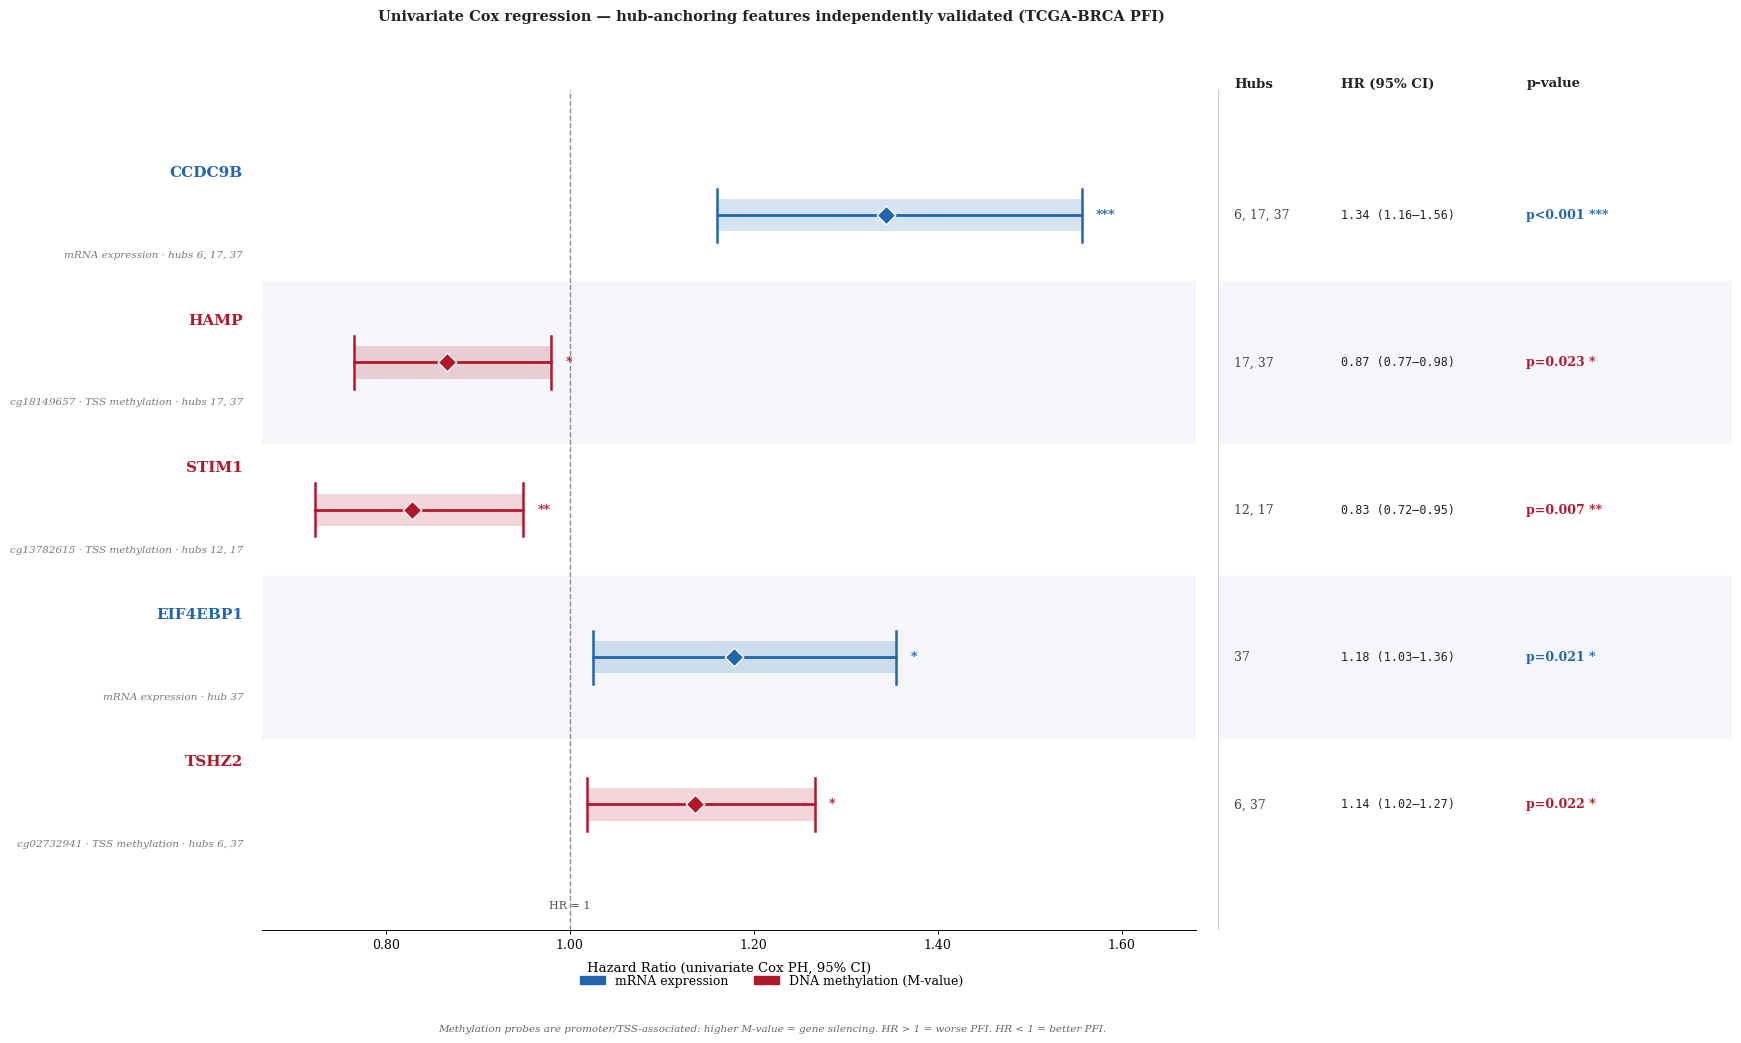

In [186]:
def plot_forest_survival(results,
                         save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/survival_forest.pdf"):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    import numpy as np
    from matplotlib import rcParams

    rcParams.update({
        "font.family":    "serif",
        "font.serif":     ["Times New Roman", "DejaVu Serif"],
        "axes.linewidth": 0.7,
        "pdf.fonttype":   42,
        "ps.fonttype":    42,
        "font.size":      12,   # ← add this, raises the baseline for everything
    })

    # ── Feature metadata — updated to new canonical hubs ─────────────────────
    feature_meta = {
        "CCDC9B (RNA) — hubs 6, 17, 37": {
            "label":    "CCDC9B",
            "sublabel": "mRNA expression · hubs 6, 17, 37",
            "modality": "mRNA",
            "hubs":     "6, 17, 37",
            "color":    "#2166AC",
        },
        "cg18149657 → HAMP (methylation) — hubs 17, 37": {
            "label":    "HAMP",
            "sublabel": "cg18149657 · TSS methylation · hubs 17, 37",
            "modality": "Methylation",
            "hubs":     "17, 37",
            "color":    "#B2182B",
        },
        "cg13782615 → STIM1 (methylation) — hubs 12, 17": {
            "label":    "STIM1",
            "sublabel": "cg13782615 · TSS methylation · hubs 12, 17",
            "modality": "Methylation",
            "hubs":     "12, 17",
            "color":    "#B2182B",
        },
        "EIF4EBP1 (RNA) — hub 37": {
            "label":    "EIF4EBP1",
            "sublabel": "mRNA expression · hub 37",
            "modality": "mRNA",
            "hubs":     "37",
            "color":    "#2166AC",
        },
        "cg02732941 → TSHZ2 (methylation) — hubs 6, 37": {
            "label":    "TSHZ2",
            "sublabel": "cg02732941 · TSS methylation · hubs 6, 37",
            "modality": "Methylation",
            "hubs":     "6, 37",
            "color":    "#B2182B",
        },
    }

    # Filter to only features in metadata, preserve order
    plot_results = [r for r in results if r["feature"] in feature_meta]
    n = len(plot_results)

    if n == 0:
        print("No matching features found in results — check feature name strings match exactly.")
        return

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(15, 1.8 * n + 2.5))   # was (13, 1.5 * n + 2.2)
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(
        1, 2,
        width_ratios=[2.0, 1.1],
        left=0.01, right=0.99,
        top=0.86, bottom=0.13,
        wspace=0.03,
    )
    ax_forest = fig.add_subplot(gs[0])
    ax_table  = fig.add_subplot(gs[1])
    ax_forest.set_facecolor("white")
    ax_table.set_facecolor("white")

    y_positions = list(range(n - 1, -1, -1))

    # ── Alternating row shading ───────────────────────────────────────────────
    for ax in [ax_forest, ax_table]:
        for j, y in enumerate(y_positions):
            if j % 2 == 1:
                ax.axhspan(y - 0.55, y + 0.55,
                           color="#F4F6F9", zorder=0, alpha=1.0)

    # ── Collect HR values to set sensible x limits ────────────────────────────
    all_lo = [r.get("hr_lo", r["hr"] * 0.8) for r in plot_results]
    all_hi = [r.get("hr_hi", r["hr"] * 1.2) for r in plot_results]
    x_min  = min(all_lo) * 0.92
    x_max  = max(all_hi) * 1.08

    # ── Forest panel ──────────────────────────────────────────────────────────
    for r, y in zip(plot_results, y_positions):
        meta  = feature_meta[r["feature"]]
        hr    = r["hr"]
        lo    = r.get("hr_lo", hr * 0.8)
        hi    = r.get("hr_hi", hr * 1.2)
        color = meta["color"]
        sig   = ("***" if r["pval"] < 0.001 else
                 "**"  if r["pval"] < 0.01  else
                 "*"   if r["pval"] < 0.05  else "ns")

        # Shaded CI band
        ax_forest.barh(y, hi - lo, left=lo, height=0.22,
                       color=color, alpha=0.18, zorder=2)
        # CI whisker
        ax_forest.plot([lo, hi], [y, y],
                       color=color, linewidth=2.0,
                       solid_capstyle="round", zorder=3)
        # End caps
        for cap_x in [lo, hi]:
            ax_forest.plot([cap_x, cap_x], [y - 0.18, y + 0.18],
                           color=color, linewidth=1.8, zorder=3)
        # Point estimate diamond
        ax_forest.scatter([hr], [y],
                          color=color, s=90, zorder=4,
                          marker="D",
                          edgecolors="white", linewidths=1.0)

        # Gene name — bold, coloured
        ax_forest.text(-0.02, y + 0.24, meta["label"],
                       transform=ax_forest.get_yaxis_transform(),
                       ha="right", va="bottom",
                       fontsize=11, fontweight="bold", color=color)
        # Sublabel — smaller, grey, italic
        ax_forest.text(-0.02, y - 0.24, meta["sublabel"],
                       transform=ax_forest.get_yaxis_transform(),
                       ha="right", va="top",
                       fontsize=7.5, color="#777777", style="italic")
        # Significance star next to CI
        ax_forest.text(hi + (x_max - x_min) * 0.015, y, sig,
                       ha="left", va="center",
                       fontsize=9, color=color, fontweight="bold")

    # Reference line at HR=1
    ax_forest.axvline(x=1.0, color="#333333", linewidth=1.0,
                      linestyle="--", alpha=0.55, zorder=1)
    ax_forest.text(1.0, -0.65, "HR = 1",
                   ha="center", va="top", fontsize=8, color="#555555")

    ax_forest.set_xlabel("Hazard Ratio (univariate Cox PH, 95% CI)",
                         fontsize=9.5, labelpad=7)
    ax_forest.set_xlim(x_min, x_max)
    ax_forest.set_ylim(-0.85, n - 0.15)
    ax_forest.set_yticks([])
    ax_forest.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FormatStrFormatter("%.2f"))
    ax_forest.tick_params(axis="x", labelsize=9)
    for spine in ["left", "right", "top"]:
        ax_forest.spines[spine].set_visible(False)
    ax_forest.spines["bottom"].set_linewidth(0.7)

    # ── Table panel ───────────────────────────────────────────────────────────
    col_headers = ["Hubs", "HR (95% CI)", "p-value"]
    col_x       = [0.04, 0.30, 0.75]

    # Column headers
    for cx, ch in zip(col_x, col_headers):
        ax_table.text(cx, n - 0.15, ch,
                      ha="left", va="bottom",
                      fontsize=9.5, fontweight="bold", color="#222222")

    for r, y in zip(plot_results, y_positions):
        meta  = feature_meta[r["feature"]]
        hr    = r["hr"]
        lo    = r.get("hr_lo", hr * 0.8)
        hi    = r.get("hr_hi", hr * 1.2)
        pval  = r["pval"]
        sig   = ("***" if pval < 0.001 else
                 "**"  if pval < 0.01  else
                 "*"   if pval < 0.05  else "ns")
        color = meta["color"]

        # Hubs
        ax_table.text(col_x[0], y, meta["hubs"],
                      ha="left", va="center",
                      fontsize=9, color="#444444")

        # HR (95% CI) in monospace
        ax_table.text(col_x[1], y,
                      f"{hr:.2f} ({lo:.2f}–{hi:.2f})",
                      ha="left", va="center",
                      fontsize=8.5, color="#222222",
                      family="monospace")

        # p-value + significance
        pval_str = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
        ax_table.text(col_x[2], y,
                      f"{pval_str} {sig}",
                      ha="left", va="center",
                      fontsize=9, color=color, fontweight="bold")

    ax_table.set_xlim(0, 1.25)
    ax_table.set_ylim(-0.85, n - 0.15)
    ax_table.set_yticks([])
    ax_table.set_xticks([])
    for spine in ax_table.spines.values():
        spine.set_visible(False)

    # Divider between panels
    ax_table.axvline(x=0.0, color="#CCCCCC", linewidth=0.8)

    # ── Directionality note ───────────────────────────────────────────────────
    fig.text(
        0.35, 0.04,
        "Methylation probes are promoter/TSS-associated: higher M-value = gene silencing. "
        "HR > 1 = worse PFI. HR < 1 = better PFI.",
        ha="center", va="bottom", fontsize=7.5,
        color="#666666", style="italic",
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(color="#2166AC", label="mRNA expression"),
        mpatches.Patch(color="#B2182B", label="DNA methylation (M-value)"),
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center", ncol=2,
        fontsize=9, frameon=False,
        bbox_to_anchor=(0.35, 0.07),
    )

    # ── Title ─────────────────────────────────────────────────────────────────
    fig.suptitle(
        "Univariate Cox regression — hub-anchoring features independently validated (TCGA-BRCA PFI)",
        fontsize=10.5, fontweight="bold",
        x=0.35, y=0.93, ha="center", color="#222222",
    )

    # ── Save ──────────────────────────────────────────────────────────────────
    plt.savefig(save_path, dpi=300, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    svg_path = save_path.replace(".pdf", ".svg")
    plt.savefig(svg_path, format="svg", bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved: {save_path}")
    print(f"Saved: {svg_path}")
    plt.show()


# ── Call ──────────────────────────────────────────────────────────────────────
plot_forest_survival(results_surv)

# Run MORE BASELINES

## VAE-POE

In [133]:
# =============================================================================
# PoE-VAE Baseline — adapted from Wu & Goodman (2018)
# Pure Product-of-Experts VAE with Cox survival head.
# No translation heads, no gate networks, no consistency losses.
# Only: recon + KL + survival.
# Architecturally independent of BioPoE.
# =============================================================================

class VanillaPoE(nn.Module):
    """
    Clean PoE-VAE baseline. Shares encoder/decoder architectures with
    CrossPoE for controlled comparison but contains none of the translation
    infrastructure. translator=None is never needed — it simply does not exist.
    """
    def __init__(self, latent_dim=N_LATENT):
        super().__init__()
        self.latent_dim = latent_dim

        # Same encoder/decoder architectures as CrossPoE for fair comparison
        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(latent_dim=latent_dim)

        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim)

    def forward(self, batch):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]

        # ── Encode observed modalities ────────────────────────────────────────
        mu_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_methyl = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_methyl = torch.zeros(batch_size, self.latent_dim, device=device)

        if rna_mask.any() and batch["rna"] is not None:
            mu_rna[rna_mask],    lv_rna[rna_mask]    = self.rna_enc(batch["rna"][rna_mask])
        if mirna_mask.any() and batch["mirna"] is not None:
            mu_mirna[mirna_mask], lv_mirna[mirna_mask] = self.mirna_enc(batch["mirna"][mirna_mask])
        if methyl_mask.any() and batch["methyl"] is not None:
            mu_methyl[methyl_mask], lv_methyl[methyl_mask] = self.methyl_enc(batch["methyl"][methyl_mask])

        # ── PoE fusion — precision-weighted product of observed experts ───────
        # Prior N(0,I) contributes precision=1 as the base
        precision_sum = torch.ones(batch_size, self.latent_dim, device=device)
        weighted_mu   = torch.zeros(batch_size, self.latent_dim, device=device)

        for mu, lv, obs in [
            (mu_rna,    lv_rna,    rna_mask),
            (mu_mirna,  lv_mirna,  mirna_mask),
            (mu_methyl, lv_methyl, methyl_mask),
        ]:
            if not obs.any():
                continue
            prec = torch.exp(-lv)
            precision_sum[obs] += prec[obs]
            weighted_mu[obs]   += (prec * mu)[obs]

        var_poe    = 1.0 / (precision_sum + 1e-8)
        logvar_poe = torch.log(var_poe + 1e-8)
        mu_poe     = var_poe * weighted_mu

        # ── Reparameterise ────────────────────────────────────────────────────
        z = reparameterise(mu_poe, logvar_poe)

        # ── Decode observed modalities ────────────────────────────────────────
        recons          = {}
        modality_masks  = [rna_mask, mirna_mask, methyl_mask]
        decoders        = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        names           = ["rna", "mirna", "methyl"]
        feat_dims       = [N_RNA, N_MIRNA, N_METHYL]

        for obs, dec, name, feat_dim in zip(modality_masks, decoders, names, feat_dims):
            if not obs.any():
                continue
            recon_full       = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs]  = dec(z[obs])
            recons[name]     = recon_full

        return {
            "mu_poe":    mu_poe,
            "logvar_poe": logvar_poe,
            "z":         z,
            "z_surv":    z,
            "recons":    recons,
            "masks":     modality_masks,
        }


def run_vanilla_poe(cfg):
    """
    PoE-VAE baseline — adapted from Wu & Goodman (2018).
    Pure PoE fusion with Cox survival head.
    Architecturally independent of BioPoE — uses VanillaPoE class.
    Loss: survival + recon + KL only. No translation, consistency, or cycle terms.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf           = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                                    random_state=cfg["seed"])
    fold_results  = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx + 1} / {cfg['n_folds']}  [VanillaPoE]")
        print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(
            train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True,
        )
        val_loader = DataLoader(
            val_dataset, batch_size=cfg["batch_size"] * 2,
            shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True,
        )

        set_seed(cfg["seed"] + fold_idx)
        model         = VanillaPoE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        optimizer = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"],
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()
            loss_accum = {"total": 0.0, "survival": 0.0, "recon": 0.0, "kl": 0.0}
            n_batches  = 0
            beta       = get_beta(epoch, cfg["kl_warmup_epochs"])

            for batch in train_loader:
                batch   = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch)

                # ── Survival loss ─────────────────────────────────────────────
                risk_scores   = survival_head(outputs["z_surv"])
                loss_survival = cox_partial_likelihood_loss(
                    risk_scores, batch["pfi_time"], batch["pfi_event"]
                )

                # ── Reconstruction loss ───────────────────────────────────────
                loss_recon    = torch.tensor(0.0, device=device, requires_grad=True)
                recon_targets = {
                    "rna":    batch["rna"],
                    "mirna":  batch["mirna"],
                    "methyl": batch["methyl"],
                }
                for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
                    if m_name not in outputs["recons"]:
                        continue
                    obs = batch["mask"][:, m_idx]
                    if not obs.any() or recon_targets[m_name] is None:
                        continue
                    loss_recon = loss_recon + F.mse_loss(
                        outputs["recons"][m_name][obs],
                        recon_targets[m_name][obs],
                    )

                # ── KL divergence ─────────────────────────────────────────────
                loss_kl = kl_divergence_gaussian(
                    outputs["mu_poe"], outputs["logvar_poe"]
                )

                # ── Total loss ────────────────────────────────────────────────
                loss = (
                      cfg["lambda_survival"] * loss_survival
                    + cfg["lambda_recon"]    * loss_recon
                    + beta                   * loss_kl
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0,
                )
                optimizer.step()

                loss_accum["total"]    += loss.item()
                loss_accum["survival"] += loss_survival.item()
                loss_accum["recon"]    += loss_recon.item()
                loss_accum["kl"]       += loss_kl.item()
                n_batches += 1

            scheduler.step()
            train_metrics = {k: v / n_batches for k, v in loss_accum.items()}

            # ── Validate ──────────────────────────────────────────────────────
            model.eval()
            survival_head.eval()
            all_risk, all_time, all_event = [], [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0
                    if valid.any():
                        all_risk.append(risk[valid].cpu())
                        all_time.append(batch["pfi_time"][valid].cpu())
                        all_event.append(batch["pfi_event"][valid].cpu())

            c_index = float("nan")
            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()
                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(
                f"  Epoch {epoch:3d}/{cfg['n_epochs']} | "
                f"beta={beta:.2f} | "
                f"Train loss: {train_metrics['total']:.4f} "
                f"(surv={train_metrics['survival']:.3f} "
                f"kl={train_metrics['kl']:.3f} "
                f"recon={train_metrics['recon']:.3f}) | "
                f"Val C-index: {c_index:.4f}"
            )

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best epoch {best_epoch}, C-index {best_score:.4f})")
                        break

        model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in best_state["survival"].items()})

        final_val_ci = float("nan")
        model.eval()
        survival_head.eval()
        all_risk, all_time, all_event = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                batch   = move_batch_to_device(batch, device)
                outputs = model(batch)
                risk    = survival_head(outputs["z_surv"])
                valid   = batch["pfi_event"] >= 0
                if valid.any():
                    all_risk.append(risk[valid].cpu())
                    all_time.append(batch["pfi_time"][valid].cpu())
                    all_event.append(batch["pfi_event"][valid].cpu())
        if all_risk:
            risk_np  = torch.cat(all_risk).squeeze().numpy()
            time_np  = torch.cat(all_time).numpy()
            event_np = torch.cat(all_event).numpy()
            if event_np.sum() > 0:
                final_val_ci = concordance_index(time_np, risk_np, event_np)

        print(f"\n  Fold {fold_idx+1} best epoch : {best_epoch}")
        print(f"  Final val C-index          : {final_val_ci:.4f}")

        fold_results.append({
            "fold":         fold_idx + 1,
            "best_epoch":   best_epoch,
            "best_c_index": best_c_index,
            "val_metrics":  {"c_index": final_val_ci},
            "model_state":  best_state,
            "scalers":      {
                "rna":    rna_scaler,
                "mirna":  mirna_scaler,
                "methyl": methyl_scaler,
            },
        })

    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"VANILLA PoE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} "
              f"(best epoch {fr['best_epoch']})")

    return fold_results

def run_mcar_vanilla_poe(fold_results, cfg):
    """
    MCAR evaluation for VanillaPoE. Uses VanillaPoE class — no translator.
    """
    _rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
    _modalities = ["rna", "mirna", "methyl"]

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf    = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                             random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    results = {mod: {r: [] for r in _rates} for mod in _modalities}

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        model         = VanillaPoE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})

        model.eval()
        survival_head.eval()

        for mod in _modalities:
            val_dataset = TCGABRCADataset(
                indices=val_idx,
                rna_scaler=fr["scalers"]["rna"],
                mirna_scaler=fr["scalers"]["mirna"],
                methyl_scaler=fr["scalers"]["methyl"],
                dropout_probs=None,
            )
            for rate in _rates:
                mcar_dataset = MCARDataset(
                    val_dataset,
                    forced_missing_modality=mod,
                    forced_missing_rate=rate,
                )
                loader = DataLoader(
                    mcar_dataset, batch_size=cfg["batch_size"] * 2,
                    shuffle=False, collate_fn=collate_fn, num_workers=0,
                )

                all_risk, all_time, all_event = [], [], []
                with torch.no_grad():
                    for batch in loader:
                        batch   = move_batch_to_device(batch, device)
                        outputs = model(batch)   # no translator arg
                        risk    = survival_head(outputs["z_surv"])
                        valid   = batch["pfi_event"] >= 0
                        if valid.any():
                            all_risk.append(risk[valid].cpu())
                            all_time.append(batch["pfi_time"][valid].cpu())
                            all_event.append(batch["pfi_event"][valid].cpu())

                c_index = float("nan")
                if all_risk:
                    risk_np  = torch.cat(all_risk).squeeze().numpy()
                    time_np  = torch.cat(all_time).numpy()
                    event_np = torch.cat(all_event).numpy()
                    if event_np.sum() > 0:
                        c_index = concordance_index(time_np, risk_np, event_np)

                results[mod][rate].append(c_index)

    print(f"\n{'='*60}")
    print(f"MCAR ROBUSTNESS — VanillaPoE")
    print(f"{'='*60}")
    print(f"{'Modality':<10}", end="")
    for r in _rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in _modalities:
        print(f"  {mod:<8}", end="")
        for r in _rates:
            print(f"  {np.nanmean(results[mod][r]):.3f} ", end="")
        print()

    return results

In [134]:
# ── Train PoE-VAE ──────────────────────────────────────────────────────────
print("=" * 60)
print("BASELINE: PoE-VAE (Wu & Goodman 2018)")
print("=" * 60)
fold_results_vanilla = run_vanilla_poe(CONFIG)
cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results_vanilla]
print(f"\nVanillaPoE C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")

# ── MCAR evaluation ───────────────────────────────────────────────────────────
print("\nRunning MCAR for VanillaPoE...")
mcar_vanilla = run_mcar_vanilla_poe(fold_results_vanilla, CONFIG)


BASELINE: PoE-VAE (Wu & Goodman 2018)

FOLD 1 / 5  [VanillaPoE]
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 0.7411 (surv=3.927 kl=0.318 recon=3.379) | Val C-index: 0.6642
  Epoch   2/100 | beta=0.07 | Train loss: 0.7118 (surv=3.725 kl=0.308 recon=3.188) | Val C-index: 0.6250
  Epoch   3/100 | beta=0.10 | Train loss: 0.6842 (surv=3.456 kl=0.299 recon=3.087) | Val C-index: 0.6970
  Epoch   4/100 | beta=0.13 | Train loss: 0.6520 (surv=3.131 kl=0.301 recon=2.988) | Val C-index: 0.6988
  Epoch   5/100 | beta=0.17 | Train loss: 0.6033 (surv=2.638 kl=0.312 recon=2.874) | Val C-index: 0.6743
  Epoch   6/100 | beta=0.20 | Train loss: 0.5707 (surv=2.235 kl=0.328 recon=2.817) | Val C-index: 0.6633
  Epoch   7/100 | beta=0.23 | Train loss: 0.5407 (surv=1.899 kl=0.308 recon=2.788) | Val C-index: 0.6645
  Epoch   8/100 | beta=0.27 | Train loss: 0.5383 (surv=1.885 kl=0.273 recon=2.771) | Val C-index: 0.6091
  Epoch   9/100 | beta=0.30 | Train loss: 0.5399 (surv=1.944 kl=0.232 

In [135]:
# ── Save ──────────────────────────────────────────────────────────────────────
save_dir = "/g/data/yr31/rn8079/PhD/term2_development/saved_results"

with open(os.path.join(save_dir, "fold_results_vanilla_canonical.pkl"), "wb") as f:
    pickle.dump(fold_results_vanilla, f)
print(f"Saved fold_results_vanilla")

save_dir = "/g/data/yr31/rn8079/PhD/term2_development/mcar_results"
with open(os.path.join(save_dir, "mcar_vanilla.pkl"), "wb") as f:
    pickle.dump(mcar_vanilla, f)
print(f"Saved mcar_vanilla")

Saved fold_results_vanilla
Saved mcar_vanilla


## MVAE Baseline

In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# MVAE Baseline — Mixture of Experts fusion
# Shi et al (2019)
# Same encoders, decoders, survival head as CrossPoE.
# Only difference: MixtureOfExperts fusion instead of ProductOfExperts.
# No translation heads, no consistency losses, no gate networks.
# ─────────────────────────────────────────────────────────────────────────────

class MixtureOfExperts(nn.Module):
    """
    Mixture of Experts posterior.
    Joint posterior = uniform mixture of individual modality posteriors.
    For K observed modalities, samples z ~ (1/K) * sum_k q(z | x_k).
    
    At inference with missing modalities: mixture only over observed experts.
    This is MVAE's native missingness handling — no imputation needed.
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

    def forward(self, mu_list, logvar_list):
        """
        Args:
            mu_list:     list of (batch, latent_dim) for OBSERVED modalities
            logvar_list: list of (batch, latent_dim) for OBSERVED modalities
        Returns:
            mu_moe:     (batch, latent_dim) mixture mean
            logvar_moe: (batch, latent_dim) mixture logvar (diagonal approx)
        """
        # Stack: (K, batch, latent_dim)
        mus     = torch.stack(mu_list,     dim=0)
        logvars = torch.stack(logvar_list, dim=0)
        
        # Mixture mean = mean of component means
        mu_moe = mus.mean(dim=0)
        
        # Mixture variance approximation:
        # Var[mixture] = E[Var] + Var[E] (law of total variance)
        # E[Var] = mean of component variances
        # Var[E] = variance of component means
        vars_    = logvars.exp()
        e_var    = vars_.mean(dim=0)
        var_e    = mus.var(dim=0, unbiased=False)
        var_moe  = e_var + var_e
        # Clamp to avoid log(0)
        logvar_moe = torch.log(var_moe + 1e-8)
        
        return mu_moe, logvar_moe


class MVAE(nn.Module):
    """
    Multimodal VAE with Mixture-of-Experts fusion.
    Architecturally identical to CrossPoE except:
    - MixtureOfExperts replaces ProductOfExperts
    - No translation heads
    - No gate networks
    - No consistency / cycle / surv_trans losses
    """
    def __init__(self, latent_dim=N_LATENT, n_methyl=None):
        super().__init__()
        self.latent_dim = latent_dim
        n_methyl = n_methyl or TCGABRCADataset._methyl_data.shape[1]

        # Same encoders as CrossPoE
        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(in_dim=n_methyl, latent_dim=latent_dim)

        # Same decoders as CrossPoE
        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim, out_dim=n_methyl)

        self.moe = MixtureOfExperts(latent_dim=latent_dim)

    def forward(self, batch):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]

        mu_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_methyl = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_methyl = torch.zeros(batch_size, self.latent_dim, device=device)

        if rna_mask.any() and batch["rna"] is not None:
            mu_r, lv_r = self.rna_enc(batch["rna"][rna_mask])
            mu_rna[rna_mask]    = mu_r
            lv_rna[rna_mask]    = lv_r
        if mirna_mask.any() and batch["mirna"] is not None:
            mu_m, lv_m = self.mirna_enc(batch["mirna"][mirna_mask])
            mu_mirna[mirna_mask]  = mu_m
            lv_mirna[mirna_mask]  = lv_m
        if methyl_mask.any() and batch["methyl"] is not None:
            mu_me, lv_me = self.methyl_enc(batch["methyl"][methyl_mask])
            mu_methyl[methyl_mask] = mu_me
            lv_methyl[methyl_mask] = lv_me

        # Build per-sample mixture only over observed modalities
        # Process per-sample to handle variable observed sets
        modality_masks = [rna_mask, mirna_mask, methyl_mask]
        all_mus     = [mu_rna, mu_mirna, mu_methyl]
        all_logvars = [lv_rna, lv_mirna, lv_methyl]

        mu_moe     = torch.zeros(batch_size, self.latent_dim, device=device)
        logvar_moe = torch.zeros(batch_size, self.latent_dim, device=device)

        # Group samples by their observed modality pattern for efficiency
        # For each unique pattern, apply MoE to that subset
        patterns = mask.cpu().numpy()
        unique_patterns = np.unique(patterns, axis=0)

        for pat in unique_patterns:
            pat_tensor = torch.tensor(pat, dtype=torch.bool, device=device)
            sample_mask = (mask == pat_tensor).all(dim=1)
            if not sample_mask.any():
                continue

            obs_indices = [i for i in range(3) if pat[i]]
            if not obs_indices:
                continue

            mu_obs  = [all_mus[i][sample_mask]     for i in obs_indices]
            lv_obs  = [all_logvars[i][sample_mask]  for i in obs_indices]

            if len(obs_indices) == 1:
                mu_moe[sample_mask]     = mu_obs[0]
                logvar_moe[sample_mask] = lv_obs[0]
            else:
                mu_p, lv_p = self.moe(mu_obs, lv_obs)
                mu_moe[sample_mask]     = mu_p
                logvar_moe[sample_mask] = lv_p

        z = reparameterise(mu_moe, logvar_moe)

        # Reconstructions
        recons = {}
        decoders = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        names    = ["rna", "mirna", "methyl"]
        for m_idx, (dec, name) in enumerate(zip(decoders, names)):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            feat_dim   = dec.net[-1].out_features
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z[obs])
            recons[name]    = recon_full

        return {
            "mu_moe":     mu_moe,
            "logvar_moe": logvar_moe,
            "z_surv":     z,
            "recons":     recons,
            "mus":        all_mus,
            "logvars":    all_logvars,
            "mask":       mask,
        }

def compute_loss_mvae(outputs, batch, beta, lambda_recon, lambda_survival, survival_head):
    """
    MVAE loss: reconstruction + KL + survival only.
    No translation, no consistency, no cycle, no gate.
    """
    device = batch["mask"].device
    mask   = batch["mask"]

    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,
        "methyl": N_RNA / N_METHYL,
    }

    # Reconstruction
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"], "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # KL
    mu     = outputs["mu_moe"]
    logvar = outputs["logvar_moe"]
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Survival
    loss_surv = torch.tensor(0.0, device=device, requires_grad=True)
    valid_surv = batch["pfi_event"] >= 0
    if valid_surv.sum() >= 2 and batch["pfi_event"][valid_surv].sum() >= 1:
        risk = survival_head(outputs["z_surv"])
        loss_surv = cox_partial_likelihood_loss(
            risk[valid_surv], batch["pfi_time"][valid_surv], batch["pfi_event"][valid_surv]
        )

    total = (lambda_recon * loss_recon
             + beta * loss_kl
             + lambda_survival * loss_surv)

    return total, {
        "total": total.item(), "recon": loss_recon.item(),
        "kl": loss_kl.item(), "survival": loss_surv.item(),
    }


def run_mvae(cfg):
    """
    Run 5-fold CV for MVAE baseline.
    Same splits, same scalers, same Cox head as CrossPoE.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"MVAE FOLD {fold_idx+1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
                                  shuffle=True, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                  shuffle=False, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = MVAE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        optimizer     = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()
            beta = min(1.0, epoch / cfg["kl_warmup_epochs"])

            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch)
                loss, _ = compute_loss_mvae(
                    outputs, batch, beta,
                    lambda_recon=cfg["lambda_recon"],
                    lambda_survival=cfg["lambda_survival"],
                    survival_head=survival_head,
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0
                )
                optimizer.step()
            scheduler.step()

            # Evaluate
            model.eval()
            survival_head.eval()
            all_risk, all_time, all_event = [], [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0
                    if valid.any():
                        all_risk.append(risk[valid].cpu())
                        all_time.append(batch["pfi_time"][valid].cpu())
                        all_event.append(batch["pfi_event"][valid].cpu())

            c_index = float("nan")
            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()
                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(f"  Epoch {epoch:3d} | beta={beta:.2f} | Val C-index: {c_index:.4f}")

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} (best {best_epoch}, C-index {best_score:.4f})")
                        break

        fold_results.append({
            "fold": fold_idx + 1, "best_epoch": best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "model_state": best_state,
            "scalers": {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
        })
        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}, C-index: {best_c_index:.4f}")

    cidxs = [fr["best_c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"MVAE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} (best epoch {fr['best_epoch']})")

    return fold_results

In [57]:
fold_results_mvae = run_mvae(CONFIG)


MVAE FOLD 1 / 5
  Epoch   1 | beta=0.03 | Val C-index: 0.6762
  Epoch   2 | beta=0.07 | Val C-index: 0.6216
  Epoch   3 | beta=0.10 | Val C-index: 0.6985
  Epoch   4 | beta=0.13 | Val C-index: 0.7181
  Epoch   5 | beta=0.17 | Val C-index: 0.6893
  Epoch   6 | beta=0.20 | Val C-index: 0.6789
  Epoch   7 | beta=0.23 | Val C-index: 0.6706
  Epoch   8 | beta=0.27 | Val C-index: 0.6278
  Epoch   9 | beta=0.30 | Val C-index: 0.5990
  Epoch  10 | beta=0.33 | Val C-index: 0.6734
  Epoch  11 | beta=0.37 | Val C-index: 0.6550
  Epoch  12 | beta=0.40 | Val C-index: 0.6284
  Epoch  13 | beta=0.43 | Val C-index: 0.6636
  Epoch  14 | beta=0.47 | Val C-index: 0.6835
  Epoch  15 | beta=0.50 | Val C-index: 0.7267
  Epoch  16 | beta=0.53 | Val C-index: 0.6768
  Epoch  17 | beta=0.57 | Val C-index: 0.6829
  Epoch  18 | beta=0.60 | Val C-index: 0.6752
  Epoch  19 | beta=0.63 | Val C-index: 0.7267
  Epoch  20 | beta=0.67 | Val C-index: 0.6722
  Epoch  21 | beta=0.70 | Val C-index: 0.6501
  Epoch  22 | bet

In [64]:
def run_mcar_single(fold_results, cfg, model_class, model_name="Model"):
    """
    Run MCAR evaluation for a single model.
    Works with any model whose forward() returns z_surv and
    whose fold_results match the standard format.
    """
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    results = {mod: {r: [] for r in rates} for mod in modalities}

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        # Load model from saved state
        model         = model_class(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})
        model.eval()
        survival_head.eval()

        for mod in modalities:
            val_dataset = TCGABRCADataset(          # ← move here, create once per mod
                indices=val_idx,
                rna_scaler=fr["scalers"]["rna"],
                mirna_scaler=fr["scalers"]["mirna"],
                methyl_scaler=fr["scalers"]["methyl"],
                dropout_probs=None,
            )
            for rate in rates:
                mcar_dataset = MCARDataset(val_dataset,
                                           forced_missing_modality=mod,
                                           forced_missing_rate=rate)
                loader = DataLoader(mcar_dataset, batch_size=cfg["batch_size"]*2,
                                    shuffle=False, collate_fn=collate_fn, num_workers=0)

                all_risk, all_time, all_event = [], [], []
                with torch.no_grad():
                    for batch in loader:
                        batch   = move_batch_to_device(batch, device)
                        outputs = model(batch)
                        risk    = survival_head(outputs["z_surv"])
                        valid   = batch["pfi_event"] >= 0
                        if valid.any():
                            all_risk.append(risk[valid].cpu())
                            all_time.append(batch["pfi_time"][valid].cpu())
                            all_event.append(batch["pfi_event"][valid].cpu())

                c_index = float("nan")
                if all_risk:
                    risk_np  = torch.cat(all_risk).squeeze().numpy()
                    time_np  = torch.cat(all_time).numpy()
                    event_np = torch.cat(all_event).numpy()
                    if event_np.sum() > 0:
                        c_index = concordance_index(time_np, risk_np, event_np)

                results[mod][rate].append(c_index)

    # Print summary
    print(f"\n{'='*60}")
    print(f"MCAR ROBUSTNESS — {model_name}")
    print(f"{'='*60}")
    print(f"{'Modality':<10}", end="")
    for r in rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in modalities:
        print(f"  {mod:<8}", end="")
        for r in rates:
            mean_c = np.nanmean(results[mod][r])
            print(f"  {mean_c:.3f} ", end="")
        print()

    return results

In [65]:
mcar_mvae = run_mcar_single(fold_results_mvae, CONFIG, MVAE, model_name="MVAE")


MCAR ROBUSTNESS — MVAE
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.658   0.621   0.619   0.608   0.598 
  mirna     0.658   0.669   0.669   0.677   0.677 
  methyl    0.658   0.636   0.624   0.622   0.623 


## CLUE Baseline

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# CLUE Baseline — Cross-Linked Unified Embedding
# Tu et al., NeurIPS 2022
# Same encoders as CrossPoE. Adds cross-encoders between modality pairs.
# No PoE fusion — concatenates self + cross representations per modality,
# then averages across observed modalities for joint embedding.
# No survival-aware training of cross-encoders.
# ─────────────────────────────────────────────────────────────────────────────

class CrossEncoder(nn.Module):
    """
    Maps source modality latent representation to target modality latent space.
    Smaller than CrossPoE translation heads — CLUE uses simpler cross-encoders.
    Input: mu_src (latent_dim) -> output: mu_tgt_pred (latent_dim)
    """
    def __init__(self, latent_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z_src):
        return self.net(z_src)


class CLUE(nn.Module):
    """
    Cross-Linked Unified Embedding for bulk multi-omics.

    Architecture per sample:
    1. Each observed modality is encoded to z_i via its own encoder (self-encoding)
    2. Each observed modality is cross-encoded from every other observed modality
    3. For each modality, self + all cross representations are averaged
    4. Final joint embedding = mean across all modality-level representations

    Handles missing modalities by only using observed modality encoders
    and cross-encoders from observed sources.
    """
    def __init__(self, latent_dim=N_LATENT, hidden_dim=64, n_methyl=None):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_mods     = 3
        n_methyl = n_methyl or TCGABRCADataset._methyl_data.shape[1]

        # Same encoders as CrossPoE
        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(in_dim=n_methyl, latent_dim=latent_dim)

        # Same decoders as CrossPoE
        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim, out_dim=n_methyl)

        # Cross-encoders: one per ordered pair (src -> tgt), 6 total
        self.cross_encoders = nn.ModuleDict()
        for src in range(self.n_mods):
            for tgt in range(self.n_mods):
                if src == tgt:
                    continue
                self.cross_encoders[f"{src}_to_{tgt}"] = CrossEncoder(
                    latent_dim, hidden_dim
                )

    def forward(self, batch):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]
        mod_masks   = [rna_mask, mirna_mask, methyl_mask]

        encoders = [self.rna_enc, self.mirna_enc, self.methyl_enc]
        decoders = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        inputs   = [batch["rna"], batch["mirna"], batch["methyl"]]

        # Step 1: self-encode each observed modality
        self_z = [torch.zeros(batch_size, self.latent_dim, device=device)
                  for _ in range(self.n_mods)]

        for i in range(self.n_mods):
            obs = mod_masks[i]
            if obs.any() and inputs[i] is not None:
                mu_i, _ = encoders[i](inputs[i][obs])
                self_z[i][obs] = mu_i

        # Step 2: cross-encode from each observed source to each target
        # For each sample, aggregate: self_z[tgt] + all cross_z[src->tgt]
        # then average to get modality-level representation
        mod_reprs = [torch.zeros(batch_size, self.latent_dim, device=device)
                     for _ in range(self.n_mods)]
        mod_counts = [torch.zeros(batch_size, 1, device=device)
                      for _ in range(self.n_mods)]

        for tgt in range(self.n_mods):
            obs_tgt = mod_masks[tgt]
            if not obs_tgt.any():
                continue

            # Self contribution
            mod_reprs[tgt][obs_tgt] += self_z[tgt][obs_tgt]
            mod_counts[tgt][obs_tgt] += 1.0

            # Cross contributions from all observed sources
            for src in range(self.n_mods):
                if src == tgt:
                    continue
                # Samples where src is observed (regardless of tgt)
                obs_src = mod_masks[src]
                both    = obs_src  # cross-encode from src to tgt space

                if not both.any():
                    continue

                key    = f"{src}_to_{tgt}"
                cross  = self.cross_encoders[key](self_z[src][both].detach())
                mod_reprs[tgt][both]  += cross
                mod_counts[tgt][both] += 1.0

        # Normalise each modality representation
        for tgt in range(self.n_mods):
            obs = mod_masks[tgt]
            if obs.any():
                mod_reprs[tgt][obs] = (mod_reprs[tgt][obs]
                                       / (mod_counts[tgt][obs] + 1e-8))

        # Step 3: joint embedding = mean of observed modality representations
        z_joint    = torch.zeros(batch_size, self.latent_dim, device=device)
        obs_counts = torch.zeros(batch_size, 1, device=device)

        for i in range(self.n_mods):
            obs = mod_masks[i]
            if obs.any():
                z_joint[obs]    += mod_reprs[i][obs]
                obs_counts[obs] += 1.0

        z_joint = z_joint / (obs_counts + 1e-8)

        # Step 4: reconstruct from joint embedding
        recons    = {}
        mod_names = ["rna", "mirna", "methyl"]
        for i, (dec, name) in enumerate(zip(decoders, mod_names)):
            obs = mod_masks[i]
            if not obs.any():
                continue
            feat_dim   = dec.net[-1].out_features
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z_joint[obs])
            recons[name]    = recon_full

        return {
            "z_surv":   z_joint,
            "recons":   recons,
            "self_z":   self_z,
            "mod_reprs": mod_reprs,
            "mask":     mask,
        }

def compute_loss_clue(outputs, batch, lambda_recon, lambda_survival,
                      lambda_cross, survival_head, model):
    """
    CLUE loss: reconstruction + survival + cross-encoder consistency.

    Cross-encoder consistency: for fully observed pairs, the cross-encoded
    representation should match the self-encoded representation of the target.
    This is the core CLUE training signal — cross-encoders learn to predict
    what the target encoder would produce.
    """
    device = batch["mask"].device
    mask   = batch["mask"]

    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,
        "methyl": N_RNA / N_METHYL,
    }

    # Reconstruction loss
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"],
                     "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # Cross-encoder consistency loss
    # For fully observed pairs: cross_encode(src->tgt) should match self_z[tgt]
    loss_cross = torch.tensor(0.0, device=device, requires_grad=True)
    n_cross = 0
    self_z = outputs["self_z"]

    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
            both = mask[:, src] & mask[:, tgt]
            if not both.any():
                continue
            key   = f"{src}_to_{tgt}"
            cross = model.cross_encoders[key](self_z[src][both])
            # Target: self-encoded representation of target modality
            target = self_z[tgt][both].detach()
            loss_cross = loss_cross + F.mse_loss(cross, target)
            n_cross += 1

    if n_cross > 0:
        loss_cross = loss_cross / n_cross

    # Survival loss
    loss_surv = torch.tensor(0.0, device=device, requires_grad=True)
    valid_surv = batch["pfi_event"] >= 0
    if valid_surv.sum() >= 2 and batch["pfi_event"][valid_surv].sum() >= 1:
        risk = survival_head(outputs["z_surv"])
        loss_surv = cox_partial_likelihood_loss(
            risk[valid_surv], batch["pfi_time"][valid_surv],
            batch["pfi_event"][valid_surv]
        )

    total = (lambda_recon    * loss_recon
             + lambda_cross  * loss_cross
             + lambda_survival * loss_surv)

    return total, {
        "total": total.item(), "recon": loss_recon.item(),
        "cross": loss_cross.item(), "survival": loss_surv.item(),
    }


def run_clue(cfg):
    """5-fold CV for CLUE. Same splits and scalers as CrossPoE."""
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"CLUE FOLD {fold_idx+1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
                                  shuffle=True, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                  shuffle=False, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = CLUE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        optimizer     = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()

            train_loss = 0.0
            n_batches  = 0
            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch)
                loss, loss_dict = compute_loss_clue(
                    outputs, batch,
                    lambda_recon=cfg["lambda_recon"],
                    lambda_survival=cfg["lambda_survival"],
                    lambda_cross=cfg.get("lambda_cross", 0.1),
                    survival_head=survival_head,
                    model=model,
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0
                )
                optimizer.step()
                train_loss += loss.item()
                n_batches  += 1
            scheduler.step()

            # Evaluate
            model.eval()
            survival_head.eval()
            all_risk, all_time, all_event = [], [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0
                    if valid.any():
                        all_risk.append(risk[valid].cpu())
                        all_time.append(batch["pfi_time"][valid].cpu())
                        all_event.append(batch["pfi_event"][valid].cpu())

            c_index = float("nan")
            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()
                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(f"  Epoch {epoch:3d} | "
                  f"Train loss: {train_loss/n_batches:.4f} | "
                  f"Val C-index: {c_index:.4f}")

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best {best_epoch}, C-index {best_score:.4f})")
                        break

        fold_results.append({
            "fold": fold_idx + 1, "best_epoch": best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "model_state": best_state,
            "scalers": {"rna": rna_scaler, "mirna": mirna_scaler,
                        "methyl": methyl_scaler},
        })
        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}, "
              f"C-index: {best_c_index:.4f}")

    cidxs = [fr["best_c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"CLUE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} "
              f"(best epoch {fr['best_epoch']})")

    return fold_results

In [61]:
CONFIG["lambda_cross"] = 0.1  # cross-encoder consistency weight
fold_results_clue = run_clue(CONFIG)


CLUE FOLD 1 / 5
  Epoch   1 | Train loss: 1.5100 | Val C-index: 0.6501
  Epoch   2 | Train loss: 1.4119 | Val C-index: 0.6780
  Epoch   3 | Train loss: 1.3433 | Val C-index: 0.6608
  Epoch   4 | Train loss: 1.2785 | Val C-index: 0.6835
  Epoch   5 | Train loss: 1.2175 | Val C-index: 0.6808
  Epoch   6 | Train loss: 1.1681 | Val C-index: 0.6988
  Epoch   7 | Train loss: 1.1139 | Val C-index: 0.6529
  Epoch   8 | Train loss: 1.0826 | Val C-index: 0.7145
  Epoch   9 | Train loss: 1.0443 | Val C-index: 0.7350
  Epoch  10 | Train loss: 1.0442 | Val C-index: 0.6869
  Epoch  11 | Train loss: 1.0174 | Val C-index: 0.6480
  Epoch  12 | Train loss: 0.9825 | Val C-index: 0.7286
  Epoch  13 | Train loss: 0.9707 | Val C-index: 0.7062
  Epoch  14 | Train loss: 0.9616 | Val C-index: 0.6777
  Epoch  15 | Train loss: 0.9447 | Val C-index: 0.6896
  Epoch  16 | Train loss: 0.9232 | Val C-index: 0.7417
  Epoch  17 | Train loss: 0.9155 | Val C-index: 0.7325
  Epoch  18 | Train loss: 0.9140 | Val C-index: 

In [67]:
CONFIG["lambda_cross"] = 0.1  # cross-encoder consistency weight
mcar_clue = run_mcar_single(fold_results_clue, CONFIG, CLUE, model_name="CLUE")


MCAR ROBUSTNESS — CLUE
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.681   0.654   0.651   0.648   0.642 
  mirna     0.681   0.694   0.696   0.697   0.695 
  methyl    0.681   0.660   0.654   0.643   0.644 


## HealNet

In [95]:
# =============================================================================
# HEALNet-OmicsLite Baseline
# PyTorch-only HEALNet-style molecular adaptation for CrossPoE benchmarking
#
# Purpose:
#   - Avoid installing the official HEALNet repo due to environment conflicts.
#   - Keep the CrossPoE protocol unchanged:
#       TCGA-BRCA, mRNA/miRNA/methylation, PFI endpoint, Cox loss,
#       same 5-fold CV, same scalers, same MCAR missingness protocol.
#
# This is NOT the original WSI + omics HEALNet experiment.
# It is a molecular-only HEALNet-style fusion baseline.
# =============================================================================

import copy
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import StratifiedKFold


# =============================================================================
# 1. HEALNet-style building blocks
# =============================================================================

class HEALNetLiteCrossAttentionBlock(nn.Module):
    """
    Latent-query cross-attention block.

    The learned latent tokens query one available omics modality.
    This captures the core HEALNet-style idea:
        latent bottleneck tokens attend into each observed modality.

    For high-dimensional modalities (e.g. methylation with 37,482 features),
    an optional intermediate compression layer reduces the input before
    projecting to latent_dim. This prevents a single oversized linear layer
    from dominating training and matches the encoder depth used in other baselines.
    """

    def __init__(
        self,
        latent_dim,
        input_dim,
        n_heads=4,
        dropout=0.1,
        ff_mult=4,
        compress_dim=None,
    ):
        super().__init__()

        if compress_dim is not None:
            self.compress = nn.Sequential(
                nn.Linear(input_dim, compress_dim),
                nn.LayerNorm(compress_dim),
                nn.GELU(),
            )
            proj_in = compress_dim
        else:
            self.compress = None
            proj_in = input_dim

        self.input_proj = nn.Linear(proj_in, latent_dim)

        self.norm_latent  = nn.LayerNorm(latent_dim)
        self.norm_context = nn.LayerNorm(latent_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=latent_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.ff = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, latent_dim * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(latent_dim * ff_mult, latent_dim),
            nn.Dropout(dropout),
        )

    def forward(self, latents, x):
        """
        Args:
            latents: [B, L, D]
            x:       [B, F]

        Returns:
            updated latents: [B, L, D]
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, F]

        if self.compress is not None:
            x = self.compress(x)  # [B, 1, compress_dim]

        context = self.input_proj(x)  # [B, 1, D]

        q  = self.norm_latent(latents)
        kv = self.norm_context(context)

        attn_out, _ = self.cross_attn(
            query=q,
            key=kv,
            value=kv,
            need_weights=False,
        )

        latents = latents + attn_out
        latents = latents + self.ff(latents)

        return latents


class HEALNetLiteLatentSelfAttentionBlock(nn.Module):
    """
    Self-attention over the learned latent bottleneck tokens.
    """

    def __init__(
        self,
        latent_dim,
        n_heads=4,
        dropout=0.1,
        ff_mult=4,
    ):
        super().__init__()

        self.norm = nn.LayerNorm(latent_dim)

        self.self_attn = nn.MultiheadAttention(
            embed_dim=latent_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.ff = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, latent_dim * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(latent_dim * ff_mult, latent_dim),
            nn.Dropout(dropout),
        )

    def forward(self, latents):
        q = self.norm(latents)

        attn_out, _ = self.self_attn(
            query=q,
            key=q,
            value=q,
            need_weights=False,
        )

        latents = latents + attn_out
        latents = latents + self.ff(latents)

        return latents


class HEALNetOmicsLite(nn.Module):
    """
    Molecular-only HEALNet-style adaptation.

    Inputs:
        batch["rna"]    : [B, N_RNA]
        batch["mirna"]  : [B, N_MIRNA]
        batch["methyl"] : [B, N_METHYL]
        batch["mask"]   : [B, 3], boolean modality availability

    Output:
        {"z_surv": z}

    Missing modalities are handled by skipping their cross-attention update,
    which is HEALNet's native missingness mechanism. Samples are grouped by
    their unique observed-modality pattern to avoid processing zero-filled
    tensors from collate_fn as real observations.
    """

    def __init__(
        self,
        latent_dim=N_LATENT,
        n_latents=16,
        depth=2,
        n_heads=4,
        dropout=0.1,
        ff_mult=4,
        n_rna=None,
        n_mirna=None,
        n_methyl=None,
    ):
        super().__init__()

        self.latent_dim    = latent_dim
        self.n_latents     = n_latents
        self.modality_order = ["rna", "mirna", "methyl"]

        self.n_rna    = n_rna    or TCGABRCADataset._rna_data.shape[1]
        self.n_mirna  = n_mirna  or TCGABRCADataset._mirna_data.shape[1]
        self.n_methyl = n_methyl or TCGABRCADataset._methyl_data.shape[1]

        self.latents = nn.Parameter(
            torch.randn(n_latents, latent_dim) * 0.02
        )

        self.layers = nn.ModuleList()

        for _ in range(depth):
            cross_blocks = nn.ModuleDict({
                "rna": HEALNetLiteCrossAttentionBlock(
                    latent_dim=latent_dim,
                    input_dim=self.n_rna,
                    n_heads=n_heads,
                    dropout=dropout,
                    ff_mult=ff_mult,
                    compress_dim=None,
                ),
                "mirna": HEALNetLiteCrossAttentionBlock(
                    latent_dim=latent_dim,
                    input_dim=self.n_mirna,
                    n_heads=n_heads,
                    dropout=dropout,
                    ff_mult=ff_mult,
                    compress_dim=None,
                ),
                "methyl": HEALNetLiteCrossAttentionBlock(
                    latent_dim=latent_dim,
                    input_dim=self.n_methyl,
                    n_heads=n_heads,
                    dropout=dropout,
                    ff_mult=ff_mult,
                    compress_dim=256,
                ),
            })

            latent_block = HEALNetLiteLatentSelfAttentionBlock(
                latent_dim=latent_dim,
                n_heads=n_heads,
                dropout=dropout,
                ff_mult=ff_mult,
            )

            self.layers.append(nn.ModuleDict({
                "cross":  cross_blocks,
                "latent": latent_block,
            }))

        self.out_norm = nn.LayerNorm(latent_dim)

        self.no_modality_embedding = nn.Parameter(
            torch.zeros(latent_dim)
        )

    def _forward_one_pattern(self, batch, sample_idx, pattern):
        """
        Forward pass for samples sharing the same observed-modality pattern.

        Grouping by pattern ensures zero-filled tensors from collate_fn
        are never passed to cross-attention as real observations.
        """
        b = int(sample_idx.sum().item())

        latents = self.latents.unsqueeze(0).expand(b, -1, -1).clone()

        for layer in self.layers:
            for m_idx, mod in enumerate(self.modality_order):
                if bool(pattern[m_idx].item()):
                    if batch[mod] is None:
                        raise RuntimeError(
                            f"Mask says {mod} is observed but batch['{mod}'] is None."
                        )
                    x = batch[mod][sample_idx]
                    latents = layer["cross"][mod](latents, x)

            latents = layer["latent"](latents)

        z = latents.mean(dim=1)
        z = self.out_norm(z)

        return z

    def forward(self, batch):
        mask   = batch["mask"]
        device = mask.device
        b      = mask.shape[0]

        z_all = torch.zeros(
            b, self.latent_dim,
            device=device,
            dtype=self.latents.dtype,
        )

        unique_patterns = torch.unique(mask, dim=0)

        for pattern in unique_patterns:
            sample_idx = (mask == pattern.unsqueeze(0)).all(dim=1)

            if not sample_idx.any():
                continue

            if not pattern.any():
                n_empty = int(sample_idx.sum().item())
                z_all[sample_idx] = self.no_modality_embedding.unsqueeze(0).expand(n_empty, -1)
                continue

            z_all[sample_idx] = self._forward_one_pattern(
                batch=batch,
                sample_idx=sample_idx,
                pattern=pattern,
            )

        return {"z_surv": z_all}


# =============================================================================
# 2. Cox-only loss
# =============================================================================

def compute_loss_healnet_omics_lite(outputs, batch, survival_head):
    """
    HEALNet-OmicsLite uses only Cox partial likelihood.
    No reconstruction, KL, translation, cycle, or consistency losses.
    """
    risk = survival_head(outputs["z_surv"])

    loss_surv = cox_partial_likelihood_loss(
        risk,
        batch["pfi_time"],
        batch["pfi_event"],
    )

    return loss_surv, {
        "total":    float(loss_surv.detach().cpu()),
        "survival": float(loss_surv.detach().cpu()),
    }


# =============================================================================
# 3. Training function
# =============================================================================

def run_healnet_omics_lite(cfg):
    """
    Train HEALNet-OmicsLite under the same CrossPoE CV protocol.

    Same as CrossPoE:
        TCGA-BRCA samples, mRNA/miRNA/methylation, PFI endpoint,
        5-fold stratified CV, fold-specific scalers,
        Cox partial likelihood, C-index early stopping.

    Different from CrossPoE:
        deterministic HEALNet-style attention fusion,
        no VAE posterior, no PoE, no cross-modal translation,
        no reconstruction or KL losses.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf = StratifiedKFold(
        n_splits=cfg["n_folds"],
        shuffle=True,
        random_state=cfg["seed"],
    )

    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.arange(len(strat_labels)), strat_labels)
    ):
        print(f"\n{'=' * 60}")
        print(f"HEALNet-OmicsLite FOLD {fold_idx + 1} / {cfg['n_folds']}")
        print(f"{'=' * 60}")

        rna_scaler = compute_scaler(
            TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]]
        )
        mirna_scaler = compute_scaler(
            TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]]
        )
        methyl_scaler = compute_scaler(
            TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]]
        )

        train_dataset = TCGABRCADataset(
            indices=train_idx,
            rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler,
            methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )

        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler,
            methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg["batch_size"],
            shuffle=True,
            collate_fn=collate_fn,
            num_workers=0,
            pin_memory=True,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=cfg["batch_size"] * 2,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=0,
            pin_memory=True,
        )

        set_seed(cfg["seed"] + fold_idx)

        model = HEALNetOmicsLite(
            latent_dim=N_LATENT,
            n_latents=cfg.get("healnet_n_latents", 16),
            depth=cfg.get("healnet_depth", 2),
            n_heads=cfg.get("healnet_n_heads", 4),
            dropout=cfg.get("healnet_dropout", 0.1),
            ff_mult=cfg.get("healnet_ff_mult", 4),
        ).to(device)

        survival_head = SurvivalHead(N_LATENT).to(device)

        optimizer = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg.get("healnet_learning_rate", cfg["learning_rate"]),
            weight_decay=cfg.get("healnet_weight_decay", cfg["weight_decay"]),
        )

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=cfg["n_epochs"],
            eta_min=1e-5,
        )

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        best_state   = None
        patience_ctr = 0

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()

            train_loss_sum = 0.0
            n_batches      = 0

            for batch in train_loader:
                batch = move_batch_to_device(batch, device)

                optimizer.zero_grad(set_to_none=True)

                outputs = model(batch)

                loss, loss_dict = compute_loss_healnet_omics_lite(
                    outputs=outputs,
                    batch=batch,
                    survival_head=survival_head,
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0,
                )

                optimizer.step()

                train_loss_sum += loss_dict["total"]
                n_batches      += 1

            scheduler.step()

            model.eval()
            survival_head.eval()

            all_risk, all_time, all_event = [], [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0

                    if valid.any():
                        all_risk.append(risk[valid].detach().cpu())
                        all_time.append(batch["pfi_time"][valid].detach().cpu())
                        all_event.append(batch["pfi_event"][valid].detach().cpu())

            c_index = float("nan")

            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()

                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(
                f"  Epoch {epoch:3d}/{cfg['n_epochs']} | "
                f"Train loss: {train_loss_sum / max(n_batches, 1):.4f} | "
                f"Val C-index: {c_index:.4f}"
            )

            score = c_index if not np.isnan(c_index) else -np.inf

            if epoch >= cfg.get("min_epochs", 1):
                if best_state is None or score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model": {
                            k: v.detach().cpu().clone()
                            for k, v in model.state_dict().items()
                        },
                        "survival": {
                            k: v.detach().cpu().clone()
                            for k, v in survival_head.state_dict().items()
                        },
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(
                            f"  Early stopping at epoch {epoch} "
                            f"(best epoch {best_epoch}, "
                            f"C-index {best_c_index:.4f})"
                        )
                        break

        fold_results.append({
            "fold":        fold_idx + 1,
            "best_epoch":  best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "model_state": best_state,
            "scalers": {
                "rna":    rna_scaler,
                "mirna":  mirna_scaler,
                "methyl": methyl_scaler,
            },
            "model_name": "HEALNet-OmicsLite",
        })

        print(f"\n  Fold {fold_idx + 1} best epoch:   {best_epoch}")
        print(f"  Fold {fold_idx + 1} best C-index: {best_c_index:.4f}")

    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]

    print(f"\n{'=' * 60}")
    print("HEALNet-OmicsLite CROSS-VALIDATION SUMMARY")
    print(f"{'=' * 60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")

    for fr in fold_results:
        print(
            f"  Fold {fr['fold']}: {fr['val_metrics']['c_index']:.4f} "
            f"(best epoch {fr['best_epoch']})"
        )

    return fold_results


# =============================================================================
# 4. MCAR evaluation
# =============================================================================

def run_mcar_healnet_omics_lite(fold_results, cfg):
    """
    MCAR evaluation for HEALNet-OmicsLite.

    Uses the same MCARDataset and rates as CrossPoE.
    """
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf = StratifiedKFold(
        n_splits=cfg["n_folds"],
        shuffle=True,
        random_state=cfg["seed"],
    )

    splits  = list(skf.split(np.arange(len(strat_labels)), strat_labels))
    results = {mod: {r: [] for r in rates} for mod in modalities}

    for fold_idx, fr in enumerate(fold_results):
        print(f"\nEvaluating HEALNet-OmicsLite MCAR | Fold {fold_idx + 1}")

        _, val_idx = splits[fold_idx]

        model = HEALNetOmicsLite(
            latent_dim=N_LATENT,
            n_latents=cfg.get("healnet_n_latents", 16),
            depth=cfg.get("healnet_depth", 2),
            n_heads=cfg.get("healnet_n_heads", 4),
            dropout=cfg.get("healnet_dropout", 0.1),
            ff_mult=cfg.get("healnet_ff_mult", 4),
        ).to(device)

        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict({
            k: v.to(device)
            for k, v in fr["model_state"]["model"].items()
        })

        survival_head.load_state_dict({
            k: v.to(device)
            for k, v in fr["model_state"]["survival"].items()
        })

        model.eval()
        survival_head.eval()

        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=fr["scalers"]["rna"],
            mirna_scaler=fr["scalers"]["mirna"],
            methyl_scaler=fr["scalers"]["methyl"],
            dropout_probs=None,
        )

        for mod in modalities:
            for rate in rates:
                mcar_dataset = MCARDataset(
                    val_dataset,
                    forced_missing_modality=mod,
                    forced_missing_rate=rate,
                )

                loader = DataLoader(
                    mcar_dataset,
                    batch_size=cfg["batch_size"] * 2,
                    shuffle=False,
                    collate_fn=collate_fn,
                    num_workers=0,
                    pin_memory=True,
                )

                all_risk, all_time, all_event = [], [], []

                with torch.no_grad():
                    for batch in loader:
                        batch   = move_batch_to_device(batch, device)
                        outputs = model(batch)
                        risk    = survival_head(outputs["z_surv"])
                        valid   = batch["pfi_event"] >= 0

                        if valid.any():
                            all_risk.append(risk[valid].detach().cpu())
                            all_time.append(batch["pfi_time"][valid].detach().cpu())
                            all_event.append(batch["pfi_event"][valid].detach().cpu())

                c_index = float("nan")

                if all_risk:
                    risk_np  = torch.cat(all_risk).squeeze().numpy()
                    time_np  = torch.cat(all_time).numpy()
                    event_np = torch.cat(all_event).numpy()

                    if event_np.sum() > 0:
                        c_index = concordance_index(time_np, risk_np, event_np)

                results[mod][rate].append(c_index)

                print(
                    f"  Fold {fold_idx + 1} | "
                    f"missing={mod:<6} | rate={rate:.1f} | "
                    f"C-index={c_index:.4f}"
                )

    print(f"\n{'=' * 60}")
    print("MCAR ROBUSTNESS — HEALNet-OmicsLite")
    print(f"{'=' * 60}")
    print(f"{'Modality':<10}", end="")
    for r in rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in modalities:
        print(f"  {mod:<8}", end="")
        for r in rates:
            print(f"  {np.nanmean(results[mod][r]):.3f} ", end="")
        print()

    return results

In [96]:
# =============================================================================
# Run HEALNet-OmicsLite training
# =============================================================================

cfg_healnet_lite = copy.deepcopy(CONFIG)
cfg_healnet_lite.update({
    "healnet_n_latents":     16,
    "healnet_depth":          2,
    "healnet_n_heads":        4,
    "healnet_dropout":        0.1,
    "healnet_ff_mult":        4,
    "healnet_learning_rate":  CONFIG["learning_rate"],
    "healnet_weight_decay":   CONFIG["weight_decay"],
    "min_epochs":             30,
})

print("=" * 60)
print("BASELINE: HEALNet-OmicsLite")
print("=" * 60)

fold_results_healnet_lite = run_healnet_omics_lite(cfg_healnet_lite)

cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results_healnet_lite]

print("\nFinal HEALNet-OmicsLite CV result")
print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")

# =============================================================================
# Run HEALNet-OmicsLite MCAR robustness evaluation
# =============================================================================

print("=" * 60)
print("MCAR EVALUATION: HEALNet-OmicsLite")
print("=" * 60)

mcar_healnet_lite = run_mcar_healnet_omics_lite(
    fold_results_healnet_lite,
    cfg_healnet_lite,
)

BASELINE: HEALNet-OmicsLite

HEALNet-OmicsLite FOLD 1 / 5
  Epoch   1/100 | Train loss: 4.1444 | Val C-index: 0.5319
  Epoch   2/100 | Train loss: 3.5706 | Val C-index: 0.6710
  Epoch   3/100 | Train loss: 3.2080 | Val C-index: 0.7056
  Epoch   4/100 | Train loss: 2.6890 | Val C-index: 0.7114
  Epoch   5/100 | Train loss: 2.2025 | Val C-index: 0.6584
  Epoch   6/100 | Train loss: 1.9384 | Val C-index: 0.6440
  Epoch   7/100 | Train loss: 1.7532 | Val C-index: 0.5910
  Epoch   8/100 | Train loss: 1.5735 | Val C-index: 0.5959
  Epoch   9/100 | Train loss: 1.6053 | Val C-index: 0.5334
  Epoch  10/100 | Train loss: 1.4948 | Val C-index: 0.6394
  Epoch  11/100 | Train loss: 1.2450 | Val C-index: 0.6232
  Epoch  12/100 | Train loss: 1.3472 | Val C-index: 0.6192
  Epoch  13/100 | Train loss: 1.2839 | Val C-index: 0.6694
  Epoch  14/100 | Train loss: 1.2140 | Val C-index: 0.5806
  Epoch  15/100 | Train loss: 1.1187 | Val C-index: 0.5910
  Epoch  16/100 | Train loss: 1.1754 | Val C-index: 0.567

## save MCAR results

In [99]:
pickle.dump(fold_results_healnet_lite,  open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_healnet_lite_canonical.pkl', 'wb'))
pickle.dump(mcar_healnet_lite,  open('/g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_healnet_lite.pkl', 'wb'))

In [106]:
pickle.dump(fold_results_mvae, open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mvae_canonical.pkl', 'wb'))
pickle.dump(fold_results_clue,   open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_clue_canonical.pkl', 'wb'))
pickle.dump(fold_results_mofa,  open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mofa_canonical.pkl', 'wb'))

NameError: name 'fold_results_mvae' is not defined

In [170]:
import pickle
import os
save_dir = "/g/data/yr31/rn8079/PhD/term2_development/mcar_results"
os.makedirs(save_dir, exist_ok=True)

mcar_to_save = {
    "mcar_crossPoE": mcar_crossPoE,
    "mcar_crossae":  mcar_clue,
    "mcar_moevae":   mcar_mvae,
    "mcar_mofa":     mcar_mofa,
    "mcar_vanilla":  mcar_vanilla,
    "mcar_notrans": mcar_no_trans,
}

for name, result in mcar_to_save.items():
    path = os.path.join(save_dir, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(result, f)
    print(f"Saved: {path}")

print("\nAll MCAR results saved.")

Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_crossPoE.pkl
Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_crossae.pkl
Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_moevae.pkl
Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_mofa.pkl
Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_vanilla.pkl
Saved: /g/data/yr31/rn8079/PhD/term2_development/mcar_results/mcar_notrans.pkl

All MCAR results saved.


In [100]:
import pickle
import os

save_dir = "/g/data/yr31/rn8079/PhD/term2_development/mcar_results"

mcar_crossPoE = pickle.load(open(os.path.join(save_dir, "mcar_crossPoE.pkl"), "rb"))
mcar_clue     = pickle.load(open(os.path.join(save_dir, "mcar_crossae.pkl"),  "rb"))
mcar_mvae     = pickle.load(open(os.path.join(save_dir, "mcar_moevae.pkl"),   "rb"))
mcar_mofa     = pickle.load(open(os.path.join(save_dir, "mcar_mofa.pkl"),     "rb"))
mcar_vanilla  = pickle.load(open(os.path.join(save_dir, "mcar_vanilla.pkl"),  "rb"))
mcar_no_trans  = pickle.load(open(os.path.join(save_dir, "mcar_notrans.pkl"),  "rb"))
print("All MCAR results loaded.")

All MCAR results loaded.


## MCAR plot

In [107]:
def plot_mcar_comparison(mcar_crossPoe, mcar_crossae, mcar_moevae,
                         mcar_vanilla, mcar_healnet_lite,
                         save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/mcar_comparison.png"):
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
    modalities = ["rna", "mirna", "methyl"]
    mod_labels = {
        "rna":    "mRNA Missing",
        "mirna":  "miRNA Missing",
        "methyl": "Methylation Missing"
    }
    models = [
        (mcar_crossPoe, "CrossPoE",       "#1565C0", "-",   2.5, "o", 0.15),
        (mcar_crossae,  "CrossAE",        "#2E7D32", "--",  2.0, "s", 0.12),
        (mcar_moevae,   "MoE-VAE",        "#E65100", "-.",  2.0, "^", 0.10),
        (mcar_vanilla,  "PoE-VAE",        "#757575", "--",  1.5, "x", 0.10),
        (mcar_healnet_lite,  "HEALNet-Omics",  "#b7950b", ":",   1.5, "D", 0.10),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for ax_idx, mod in enumerate(modalities):
        ax = axes[ax_idx]

        for results, name, color, ls, lw, marker, alpha in models:
            means = np.array([np.nanmean(results[mod][r]) for r in rates])
            stds  = np.array([np.nanstd(results[mod][r],  ddof=1)
                              if len([x for x in results[mod][r]
                                      if not np.isnan(x)]) > 1
                              else 0.0
                              for r in rates])

            # Shaded band: mean ± 1 SD across folds
            ax.fill_between(rates,
                            means - stds,
                            means + stds,
                            color=color, alpha=alpha, linewidth=0)

            ax.plot(rates, means,
                    label=name, color=color, linestyle=ls,
                    linewidth=lw, marker=marker, markersize=6,
                    markerfacecolor=color, markeredgecolor="white",
                    markeredgewidth=0.8, zorder=3)

        ax.set_title(mod_labels[mod], fontsize=12, fontweight="bold")
        ax.set_xlabel("Forced Missingness Rate", fontsize=11)
        if ax_idx == 0:
            ax.set_ylabel("Mean C-index (5-fold CV)", fontsize=11)

        ax.set_xticks(rates)
        ax.set_xticklabels([f"{r:.1f}" for r in rates])
        ax.set_xlim(-0.05, 0.95)
        ax.grid(True, alpha=0.3, linestyle="--", zorder=0)
        ax.tick_params(labelsize=10)

        # Annotate CrossPoE at rate=0.9
        crosspoe_vals = [np.nanmean(mcar_crossPoe[mod][r]) for r in rates]
        ax.annotate(f"{crosspoe_vals[-1]:.3f}",
                    xy=(0.9, crosspoe_vals[-1]),
                    xytext=(0.78, crosspoe_vals[-1] + 0.008),
                    fontsize=8, color="#1565C0", fontweight="bold")

    # SD note in figure
    fig.text(0.5, 1.01,
             "Shaded regions show ±1 SD across 5 cross-validation folds",
             ha="center", fontsize=9, color="#555555", style="italic")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.08),
               fontsize=10, framealpha=0.9,
               edgecolor="#CCCCCC")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

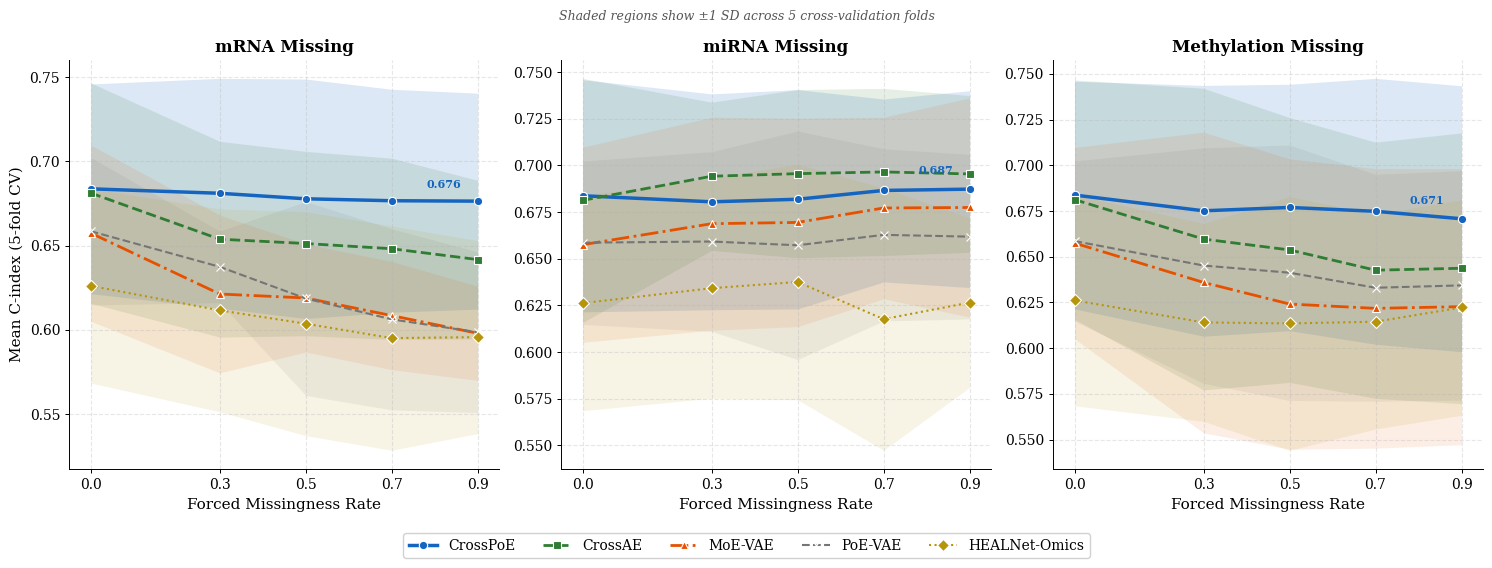

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/mcar_comparison.png


In [108]:
plot_mcar_comparison(
    mcar_crossPoe=mcar_crossPoE,  
    mcar_crossae=mcar_clue,
    mcar_moevae=mcar_mvae,
    mcar_vanilla=mcar_vanilla,
    mcar_healnet_lite=mcar_healnet_lite,
)